<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/MGGF_rectangular2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to /contend/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CUDA Envoronment and GPU Configuration

In [ ]:
# ============================================================
# MGGF rectangular GPU development
# Step 1: CUDA environment and GPU configuration
# ============================================================

import torch
import numpy as np
import scipy
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
torch.manual_seed(1234)
np.random.seed(1234)

# ------------------------------------------------------------
# CUDA availability
# ------------------------------------------------------------
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. "
        "Please confirm that the Colab runtime is set to GPU."
    )

device = torch.device("cuda")

print("CUDA version    :", torch.version.cuda)
print("GPU count       :", torch.cuda.device_count())
print("GPU name        :", torch.cuda.get_device_name(0))

props = torch.cuda.get_device_properties(0)

print(
    "GPU memory      : "
    f"{props.total_memory / 1024**3:.2f} GB"
)

print(
    "Compute capability:",
    f"{props.major}.{props.minor}"
)

# ------------------------------------------------------------
# Precision choices
#
# float64:
#   reference / mathematical validation
#
# float32:
#   primary GPU-performance precision
# ------------------------------------------------------------
dtype_ref = torch.float64
dtype_gpu = torch.float32

print("\nReference dtype :", dtype_ref)
print("GPU dtype       :", dtype_gpu)


# ------------------------------------------------------------
# Simple CUDA test
# ------------------------------------------------------------
x = torch.randn(
    1000,
    1000,
    device=device,
    dtype=dtype_gpu
)

torch.cuda.synchronize()

t0 = time.perf_counter()

y = x @ x

torch.cuda.synchronize()

t1 = time.perf_counter()

print(
    "\nCUDA matrix-multiply test:",
    f"{t1 - t0:.6f} s"
)

print(
    "Result device:",
    y.device
)

# Clean temporary tensors
del x, y

torch.cuda.empty_cache()

print("\nCUDA environment check: PASS")

PyTorch version : 2.11.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU count       : 1
GPU name        : NVIDIA A100-SXM4-40GB
GPU memory      : 39.49 GB
Compute capability: 8.0

Reference dtype : torch.float64
GPU dtype       : torch.float32

CUDA matrix-multiply test: 0.184260 s
Result device: cuda:0

CUDA environment check: PASS


# 2. GPU Rectangular Hierarchy and Matrix-Free Four-Neighbor Operator

In [ ]:
# ============================================================
# Step 2: GPU rectangular hierarchy and matrix-free
#         four-neighbor operator
# ============================================================

import math

# ------------------------------------------------------------
# Prototype hierarchy
# ------------------------------------------------------------
NX0 = 129
NY0 = 65

def build_levels(nx0, ny0, nlevels=3):
    levels = []

    nx = nx0
    ny = ny0

    for ell in range(nlevels):
        levels.append({
            "level": ell,
            "nx": nx,
            "ny": ny,
            "ncell": nx * ny,
        })

        nx = (nx + 1) // 2
        ny = (ny + 1) // 2

    return levels


levels_gpu = build_levels(
    NX0,
    NY0,
    nlevels=3
)

print("\nGPU hierarchy")
print("-" * 52)

for L in levels_gpu:
    print(
        f"L{L['level']}: "
        f"{L['nx']} x {L['ny']}   "
        f"N={L['ncell']}"
    )

print("-" * 52)


# ============================================================
# Build bilinear-transfer coarse weights on GPU
# ============================================================

def build_coarse_weights_from_fine(A_f):
    """
    Construct coarse weights implied by bilinear prolongation P:

        A_c = P^T A_f

    This reproduces the CPU formulation without explicitly
    constructing sparse P.
    """

    ny_f, nx_f = A_f.shape

    ny_c = (ny_f + 1) // 2
    nx_c = (nx_f + 1) // 2

    A_c = torch.zeros(
        ny_c,
        nx_c,
        dtype=A_f.dtype,
        device=A_f.device
    )

    # --------------------------------------------------------
    # Fine nodes with even-even indices:
    # full weight to one coarse node
    # --------------------------------------------------------
    A_c += A_f[0::2, 0::2]

    # --------------------------------------------------------
    # Odd-x, even-y:
    # split equally left/right
    # --------------------------------------------------------
    if nx_f > 1:
        temp = A_f[0::2, 1::2]

        A_c[:, :-1] += 0.5 * temp
        A_c[:, 1:]  += 0.5 * temp

    # --------------------------------------------------------
    # Even-x, odd-y:
    # split equally down/up
    # --------------------------------------------------------
    if ny_f > 1:
        temp = A_f[1::2, 0::2]

        A_c[:-1, :] += 0.5 * temp
        A_c[1:, :]  += 0.5 * temp

    # --------------------------------------------------------
    # Odd-odd:
    # bilinear 1/4 contribution to four coarse nodes
    # --------------------------------------------------------
    if nx_f > 1 and ny_f > 1:
        temp = A_f[1::2, 1::2]

        A_c[:-1, :-1] += 0.25 * temp
        A_c[:-1, 1:]  += 0.25 * temp
        A_c[1:, :-1]  += 0.25 * temp
        A_c[1:, 1:]   += 0.25 * temp

    return A_c


# ------------------------------------------------------------
# Build area/weight fields for first three levels
# ------------------------------------------------------------
A_levels_gpu = []

A0_gpu = torch.ones(
    NY0,
    NX0,
    dtype=dtype_ref,
    device=device
)

A_levels_gpu.append(A0_gpu)

for ell in range(2):
    A_next = build_coarse_weights_from_fine(
        A_levels_gpu[-1]
    )

    A_levels_gpu.append(A_next)


print("\nGPU level weights")
print("-" * 72)

for ell, A in enumerate(A_levels_gpu):

    print(
        f"L{ell}: "
        f"shape={tuple(A.shape)}   "
        f"min={A.min().item():.6f}   "
        f"max={A.max().item():.6f}   "
        f"sum={A.sum().item():.6f}"
    )

print("-" * 72)


# ============================================================
# Matrix-free four-neighbor graph operator
# ============================================================

def apply_L_gpu(x, A, cx=1.0, cy=1.0):
    """
    Apply

        (Lx)_ij = (1/A_ij) sum_neighbors c_ij (x_ij-x_neighbor)

    directly on GPU using tensor slicing.

    Supports tensors with arbitrary leading dimensions, e.g.

        [ny, nx]
        [batch, ny, nx]
        [batch, channels, ny, nx]

    The last two dimensions are always interpreted as [ny, nx].
    """

    out = torch.zeros_like(x)

    # --------------------------------------------------------
    # Horizontal edges
    # --------------------------------------------------------
    dx = x[..., :, :-1] - x[..., :, 1:]

    out[..., :, :-1] += cx * dx
    out[..., :, 1:]  -= cx * dx

    # --------------------------------------------------------
    # Vertical edges
    # --------------------------------------------------------
    dy = x[..., :-1, :] - x[..., 1:, :]

    out[..., :-1, :] += cy * dy
    out[..., 1:, :]  -= cy * dy

    # Area division broadcasts across leading dimensions
    out = out / A

    return out


def weighted_inner_gpu(x, y, A):
    """
    Area-weighted inner product over the last two dimensions.
    """

    return torch.sum(
        A * x * y
    )


# ============================================================
# Structural tests for L on all three levels
# ============================================================

torch.manual_seed(20260829)

print("\nGPU graph-operator diagnostics")
print("-" * 82)

all_constant = True
all_adjoint = True
all_conservation = True
all_positive = True

for ell, A in enumerate(A_levels_gpu):

    ny, nx = A.shape

    x = torch.randn(
        ny,
        nx,
        dtype=dtype_ref,
        device=device
    )

    y = torch.randn(
        ny,
        nx,
        dtype=dtype_ref,
        device=device
    )

    ones = torch.ones_like(A)

    Lx = apply_L_gpu(
        x,
        A
    )

    Ly = apply_L_gpu(
        y,
        A
    )

    L1 = apply_L_gpu(
        ones,
        A
    )

    # Constant nullspace
    err_const = torch.max(
        torch.abs(L1)
    ).item()

    # Weighted self-adjointness
    lhs = weighted_inner_gpu(
        x,
        Ly,
        A
    )

    rhs = weighted_inner_gpu(
        Lx,
        y,
        A
    )

    adj_err = (
        torch.abs(lhs - rhs).item()
        /
        max(
            abs(lhs.item()),
            abs(rhs.item()),
            1.0
        )
    )

    # Conservation
    mass_Lx = torch.sum(
        A * Lx
    )

    cons_err = (
        torch.abs(mass_Lx).item()
        /
        max(
            torch.sum(
                torch.abs(A * Lx)
            ).item(),
            1.0
        )
    )

    # Positive semidefinite quadratic form
    qform = weighted_inner_gpu(
        x,
        Lx,
        A
    ).item()

    print(
        f"L{ell}: "
        f"max|L1|={err_const:.3e}   "
        f"adj={adj_err:.3e}   "
        f"cons={cons_err:.3e}   "
        f"<x,Lx>_A={qform:.6e}"
    )

    all_constant &= err_const < 1.0e-13
    all_adjoint &= adj_err < 1.0e-13
    all_conservation &= cons_err < 1.0e-13
    all_positive &= qform >= -1.0e-12

print("-" * 82)

print(
    "Constant nullspace       :",
    "PASS" if all_constant else "FAIL"
)

print(
    "Weighted self-adjointness:",
    "PASS" if all_adjoint else "FAIL"
)

print(
    "Area conservation        :",
    "PASS" if all_conservation else "FAIL"
)

print(
    "Positive semidefinite    :",
    "PASS" if all_positive else "FAIL"
)


# ============================================================
# Simple GPU timing of matrix-free L
# ============================================================

x_timing = torch.randn(
    NY0,
    NX0,
    dtype=dtype_gpu,
    device=device
)

A_timing = A_levels_gpu[0].to(
    dtype=dtype_gpu
)

# Warm-up
for _ in range(20):
    _ = apply_L_gpu(
        x_timing,
        A_timing
    )

torch.cuda.synchronize()

nrepeat = 1000

t0 = time.perf_counter()

for _ in range(nrepeat):
    y_timing = apply_L_gpu(
        x_timing,
        A_timing
    )

torch.cuda.synchronize()

t1 = time.perf_counter()

avg_time = (
    t1 - t0
) / nrepeat

print(
    "\nMatrix-free Level-0 L timing "
    f"(single field, float32): "
    f"{avg_time * 1.0e6:.3f} microseconds"
)


GPU hierarchy
----------------------------------------------------
L0: 129 x 65   N=8385
L1: 65 x 33   N=2145
L2: 33 x 17   N=561
----------------------------------------------------

GPU level weights
------------------------------------------------------------------------
L0: shape=(65, 129)   min=1.000000   max=1.000000   sum=8385.000000
L1: shape=(33, 65)   min=2.250000   max=4.000000   sum=8385.000000
L2: shape=(17, 33)   min=6.250000   max=16.000000   sum=8385.000000
------------------------------------------------------------------------

GPU graph-operator diagnostics
----------------------------------------------------------------------------------
L0: max|L1|=0.000e+00   adj=0.000e+00   cons=9.476e-19   <x,Lx>_A=3.387617e+04
L1: max|L1|=0.000e+00   adj=0.000e+00   cons=9.632e-19   <x,Lx>_A=8.034931e+03
L2: max|L1|=0.000e+00   adj=2.132e-16   cons=7.301e-18   <x,Lx>_A=2.255293e+03
----------------------------------------------------------------------------------
Constant null

# 3. Matrix-Free GPU Beta Filter with Preconditioned Conjugate Gradient

In [ ]:
# ============================================================
# Step 3: Matrix-free GPU Graph Beta Filter
#
# Solve
#
#     (I + beta L) y = x
#
# in the equivalent Euclidean-SPD form
#
#     (W + beta K) y = W x,
#
# where
#
#     W = diag(A)
#     K = W L
#
# using matrix-free preconditioned conjugate gradient (PCG).
# ============================================================

import scipy.sparse as sp
import scipy.sparse.linalg as spla


# ------------------------------------------------------------
# Degree field for the four-neighbor graph
# ------------------------------------------------------------
def build_degree_field(ny, nx, dtype, device):
    """
    Number of existing four-neighbor edges at each grid point.

    Interior : 4
    Edge     : 3
    Corner   : 2
    """

    deg = torch.full(
        (ny, nx),
        4.0,
        dtype=dtype,
        device=device
    )

    deg[0, :]  -= 1.0
    deg[-1, :] -= 1.0
    deg[:, 0]  -= 1.0
    deg[:, -1] -= 1.0

    return deg


# ------------------------------------------------------------
# Euclidean-SPD operator
#
# H y = W y + beta W L y
# ------------------------------------------------------------
def apply_H_gpu(y, A, beta):
    """
    Apply

        H y = A*y + beta*A*L(y)

    where H = W + beta K is symmetric positive definite.
    """

    return (
        A * y
        + beta * A * apply_L_gpu(y, A)
    )


# ------------------------------------------------------------
# Matrix-free Jacobi-preconditioned CG
# ------------------------------------------------------------
def beta_filter_pcg_gpu(
    x,
    A,
    beta,
    tol=1.0e-12,
    maxiter=200,
    verbose=False
):
    """
    Solve

        (I + beta L)y = x

    using PCG on

        (W + beta K)y = W x.

    This first version is intended for numerical validation.
    It checks convergence each iteration, which introduces
    host/GPU synchronization. A performance version will
    remove those synchronizations later.
    """

    ny, nx = A.shape

    # Right-hand side
    b = A * x

    # Jacobi diagonal:
    #
    # diag(W + beta K) = A + beta*degree
    #
    degree = build_degree_field(
        ny,
        nx,
        dtype=x.dtype,
        device=x.device
    )

    Mdiag = A + beta * degree

    # Initial guess:
    # x itself is usually much closer than zero because
    # B approaches identity at large scales.
    y = x.clone()

    r = b - apply_H_gpu(
        y,
        A,
        beta
    )

    z = r / Mdiag
    p = z.clone()

    rz_old = torch.sum(r * z)

    bnorm = torch.linalg.vector_norm(
        b
    )

    # Avoid division by zero for a zero input field
    bnorm_value = max(
        bnorm.item(),
        1.0e-30
    )

    converged = False
    rel_res = None

    for k in range(maxiter):

        Hp = apply_H_gpu(
            p,
            A,
            beta
        )

        denom = torch.sum(
            p * Hp
        )

        alpha = rz_old / denom

        y = y + alpha * p
        r = r - alpha * Hp

        # Relative Euclidean residual
        rel_res_tensor = (
            torch.linalg.vector_norm(r)
            / bnorm
        )

        rel_res = rel_res_tensor.item()

        if rel_res < tol:
            converged = True
            nit = k + 1
            break

        z = r / Mdiag

        rz_new = torch.sum(
            r * z
        )

        gamma = rz_new / rz_old

        p = z + gamma * p

        rz_old = rz_new

    else:
        nit = maxiter

    if verbose:
        print(
            f"beta={beta:.3f}: "
            f"iterations={nit}, "
            f"relative residual={rel_res:.3e}, "
            f"converged={converged}"
        )

    return y, {
        "iterations": nit,
        "relative_residual": rel_res,
        "converged": converged,
    }


# ============================================================
# GPU beta-filter diagnostics at all three levels
# ============================================================

BETA = [
    0.50,
    2.00,
    6.00
]

torch.manual_seed(20260829)

print("\nGPU matrix-free beta-filter diagnostics")
print("-" * 94)

beta_results = []

for ell in range(3):

    A = A_levels_gpu[ell]

    ny, nx = A.shape

    x = torch.randn(
        ny,
        nx,
        dtype=dtype_ref,
        device=device
    )

    ones = torch.ones_like(A)

    # --------------------------------------------------------
    # Random field
    # --------------------------------------------------------
    Bx, info_x = beta_filter_pcg_gpu(
        x,
        A,
        BETA[ell],
        tol=1.0e-12,
        maxiter=200
    )

    # --------------------------------------------------------
    # Constant field
    # --------------------------------------------------------
    B1, info_1 = beta_filter_pcg_gpu(
        ones,
        A,
        BETA[ell],
        tol=1.0e-12,
        maxiter=200
    )

    # Constant preservation
    const_err = torch.max(
        torch.abs(B1 - 1.0)
    ).item()

    # Conservation
    mass_x = torch.sum(
        A * x
    )

    mass_Bx = torch.sum(
        A * Bx
    )

    mass_err = (
        torch.abs(mass_Bx - mass_x).item()
        /
        max(
            torch.sum(
                torch.abs(A * x)
            ).item(),
            1.0
        )
    )

    # True equation residual:
    #
    # (I + beta L)Bx - x
    #
    equation_residual = (
        Bx
        + BETA[ell] * apply_L_gpu(Bx, A)
        - x
    )

    equation_rel = (
        torch.linalg.vector_norm(
            equation_residual
        )
        /
        torch.linalg.vector_norm(x)
    ).item()

    beta_results.append({
        "Bx": Bx,
        "info": info_x,
        "const_err": const_err,
        "mass_err": mass_err,
        "equation_rel": equation_rel,
    })

    print(
        f"L{ell}: "
        f"beta={BETA[ell]:4.1f}   "
        f"iters={info_x['iterations']:3d}   "
        f"PCG res={info_x['relative_residual']:.3e}   "
        f"eq res={equation_rel:.3e}   "
        f"|B1-1|={const_err:.3e}   "
        f"mass={mass_err:.3e}"
    )

print("-" * 94)


# ============================================================
# Weighted self-adjointness test for B
# ============================================================

print("\nGPU beta-filter weighted self-adjointness")
print("-" * 82)

all_adjoint = True

torch.manual_seed(314159)

for ell in range(3):

    A = A_levels_gpu[ell]

    ny, nx = A.shape

    x = torch.randn(
        ny,
        nx,
        dtype=dtype_ref,
        device=device
    )

    y = torch.randn(
        ny,
        nx,
        dtype=dtype_ref,
        device=device
    )

    Bx, _ = beta_filter_pcg_gpu(
        x,
        A,
        BETA[ell],
        tol=1.0e-12
    )

    By, _ = beta_filter_pcg_gpu(
        y,
        A,
        BETA[ell],
        tol=1.0e-12
    )

    lhs = weighted_inner_gpu(
        x,
        By,
        A
    )

    rhs = weighted_inner_gpu(
        Bx,
        y,
        A
    )

    adj_err = (
        torch.abs(lhs - rhs).item()
        /
        max(
            abs(lhs.item()),
            abs(rhs.item()),
            1.0
        )
    )

    print(
        f"L{ell}: "
        f"weighted adjoint relative error = "
        f"{adj_err:.3e}"
    )

    all_adjoint &= (
        adj_err < 1.0e-10
    )

print("-" * 82)

print(
    "Weighted self-adjointness:",
    "PASS" if all_adjoint else "FAIL"
)


# ============================================================
# CPU sparse reference for LEVEL 0
#
# This gives us our first direct CPU-vs-GPU equality test.
# ============================================================

def build_L_cpu_reference(ny, nx):
    """
    Level-0 unit-area four-neighbor Laplacian.
    """

    n = ny * nx

    rows = []
    cols = []
    vals = []

    def idx(j, i):
        return j * nx + i

    for j in range(ny):
        for i in range(nx):

            p = idx(j, i)

            degree = 0

            for dj, di in [
                (-1, 0),
                ( 1, 0),
                ( 0,-1),
                ( 0, 1),
            ]:

                jj = j + dj
                ii = i + di

                if (
                    0 <= jj < ny
                    and
                    0 <= ii < nx
                ):
                    q = idx(jj, ii)

                    rows.append(p)
                    cols.append(q)
                    vals.append(-1.0)

                    degree += 1

            rows.append(p)
            cols.append(p)
            vals.append(float(degree))

    return sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()


# Same random field on CPU and GPU
torch.manual_seed(777)

x_gpu = torch.randn(
    NY0,
    NX0,
    dtype=dtype_ref,
    device=device
)

A_gpu = A_levels_gpu[0]

y_gpu, info_gpu = beta_filter_pcg_gpu(
    x_gpu,
    A_gpu,
    beta=0.5,
    tol=1.0e-13,
    maxiter=300
)

x_cpu = (
    x_gpu
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
)

L0_cpu = build_L_cpu_reference(
    NY0,
    NX0
)

M0_cpu = (
    sp.eye(
        NY0 * NX0,
        format="csr"
    )
    + 0.5 * L0_cpu
)

y_cpu = spla.spsolve(
    M0_cpu,
    x_cpu
)

y_gpu_np = (
    y_gpu
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
)

rel_cpu_gpu = (
    np.linalg.norm(
        y_gpu_np - y_cpu
    )
    /
    np.linalg.norm(
        y_cpu
    )
)

max_cpu_gpu = np.max(
    np.abs(
        y_gpu_np - y_cpu
    )
)

print("\nCPU vs GPU Level-0 beta-filter comparison")
print("-" * 70)

print(
    f"PCG iterations          : "
    f"{info_gpu['iterations']}"
)

print(
    f"PCG relative residual   : "
    f"{info_gpu['relative_residual']:.3e}"
)

print(
    f"CPU/GPU relative error  : "
    f"{rel_cpu_gpu:.3e}"
)

print(
    f"CPU/GPU maximum error   : "
    f"{max_cpu_gpu:.3e}"
)

print("-" * 70)

print(
    "CPU/GPU equivalence:",
    "PASS"
    if rel_cpu_gpu < 1.0e-11
    else "FAIL"
)


GPU matrix-free beta-filter diagnostics
----------------------------------------------------------------------------------------------
L0: beta= 0.5   iters= 28   PCG res=8.544e-13   eq res=8.544e-13   |B1-1|=nan   mass=7.811e-14
L1: beta= 2.0   iters= 28   PCG res=8.395e-13   eq res=8.392e-13   |B1-1|=nan   mass=4.575e-14
L2: beta= 6.0   iters= 25   PCG res=9.494e-13   eq res=1.012e-12   |B1-1|=nan   mass=1.071e-13
----------------------------------------------------------------------------------------------

GPU beta-filter weighted self-adjointness
----------------------------------------------------------------------------------
L0: weighted adjoint relative error = 1.191e-12
L1: weighted adjoint relative error = 4.615e-13
L2: weighted adjoint relative error = 1.155e-12
----------------------------------------------------------------------------------
Weighted self-adjointness: PASS

CPU vs GPU Level-0 beta-filter comparison
--------------------------------------------------------

# 4. PCG Zero-Residual Fix and Final GPU Beta-Filter Validation

In [ ]:
# ============================================================
# Step 4: Correct PCG handling of an exact initial solution
# ============================================================

def beta_filter_pcg_gpu(
    x,
    A,
    beta,
    tol=1.0e-12,
    maxiter=200,
    verbose=False
):
    """
    Solve

        (I + beta L)y = x

    using PCG on the Euclidean-SPD system

        (W + beta K)y = W x.

    Correctly handles the case in which the initial guess
    y=x is already the exact solution (e.g. constant fields).
    """

    ny, nx = A.shape

    # Right-hand side
    b = A * x

    # Jacobi diagonal
    degree = build_degree_field(
        ny,
        nx,
        dtype=x.dtype,
        device=x.device
    )

    Mdiag = A + beta * degree

    # Initial guess
    y = x.clone()

    r = b - apply_H_gpu(
        y,
        A,
        beta
    )

    bnorm = torch.linalg.vector_norm(b)

    # --------------------------------------------------------
    # Zero RHS
    # --------------------------------------------------------
    if bnorm.item() == 0.0:
        return torch.zeros_like(x), {
            "iterations": 0,
            "relative_residual": 0.0,
            "converged": True,
        }

    # --------------------------------------------------------
    # Check initial residual BEFORE entering CG
    # --------------------------------------------------------
    rnorm = torch.linalg.vector_norm(r)

    rel_res = (
        rnorm / bnorm
    ).item()

    if rel_res < tol:

        if verbose:
            print(
                f"beta={beta:.3f}: "
                f"initial guess exact, "
                f"relative residual={rel_res:.3e}"
            )

        return y, {
            "iterations": 0,
            "relative_residual": rel_res,
            "converged": True,
        }

    # --------------------------------------------------------
    # PCG initialization
    # --------------------------------------------------------
    z = r / Mdiag
    p = z.clone()

    rz_old = torch.sum(
        r * z
    )

    converged = False

    # --------------------------------------------------------
    # PCG iterations
    # --------------------------------------------------------
    for k in range(maxiter):

        Hp = apply_H_gpu(
            p,
            A,
            beta
        )

        denom = torch.sum(
            p * Hp
        )

        alpha = (
            rz_old / denom
        )

        y = (
            y
            + alpha * p
        )

        r = (
            r
            - alpha * Hp
        )

        rel_res = (
            torch.linalg.vector_norm(r)
            / bnorm
        ).item()

        if rel_res < tol:
            converged = True
            nit = k + 1
            break

        z = (
            r / Mdiag
        )

        rz_new = torch.sum(
            r * z
        )

        gamma = (
            rz_new / rz_old
        )

        p = (
            z
            + gamma * p
        )

        rz_old = rz_new

    else:
        nit = maxiter

    if verbose:
        print(
            f"beta={beta:.3f}: "
            f"iterations={nit}, "
            f"relative residual={rel_res:.3e}, "
            f"converged={converged}"
        )

    return y, {
        "iterations": nit,
        "relative_residual": rel_res,
        "converged": converged,
    }


# ============================================================
# Recheck constant preservation at all three levels
# ============================================================

print("\nCorrected constant-field beta-filter test")
print("-" * 78)

all_constant = True

for ell in range(3):

    A = A_levels_gpu[ell]

    ones = torch.ones_like(A)

    B1, info = beta_filter_pcg_gpu(
        ones,
        A,
        BETA[ell],
        tol=1.0e-12,
        maxiter=200
    )

    err = torch.max(
        torch.abs(B1 - 1.0)
    ).item()

    print(
        f"L{ell}: "
        f"beta={BETA[ell]:4.1f}   "
        f"iterations={info['iterations']:2d}   "
        f"residual={info['relative_residual']:.3e}   "
        f"max|B1-1|={err:.3e}"
    )

    all_constant &= (
        err < 1.0e-13
    )

print("-" * 78)

print(
    "Constant preservation:",
    "PASS" if all_constant else "FAIL"
)


# ============================================================
# Repeat random-field equation/conservation check
# ============================================================

torch.manual_seed(20260830)

print("\nFinal GPU beta-filter validation")
print("-" * 94)

for ell in range(3):

    A = A_levels_gpu[ell]

    ny, nx = A.shape

    x = torch.randn(
        ny,
        nx,
        dtype=dtype_ref,
        device=device
    )

    Bx, info = beta_filter_pcg_gpu(
        x,
        A,
        BETA[ell],
        tol=1.0e-12,
        maxiter=200
    )

    # Equation residual
    eq = (
        Bx
        + BETA[ell] * apply_L_gpu(
            Bx,
            A
        )
        - x
    )

    eq_rel = (
        torch.linalg.vector_norm(eq)
        /
        torch.linalg.vector_norm(x)
    ).item()

    # Conservation
    mass_before = torch.sum(
        A * x
    )

    mass_after = torch.sum(
        A * Bx
    )

    mass_rel = (
        torch.abs(
            mass_after - mass_before
        ).item()
        /
        max(
            torch.sum(
                torch.abs(A * x)
            ).item(),
            1.0
        )
    )

    print(
        f"L{ell}: "
        f"iters={info['iterations']:3d}   "
        f"PCG={info['relative_residual']:.3e}   "
        f"equation={eq_rel:.3e}   "
        f"mass={mass_rel:.3e}"
    )

print("-" * 94)


Corrected constant-field beta-filter test
------------------------------------------------------------------------------
L0: beta= 0.5   iterations= 0   residual=0.000e+00   max|B1-1|=0.000e+00
L1: beta= 2.0   iterations= 0   residual=0.000e+00   max|B1-1|=0.000e+00
L2: beta= 6.0   iterations= 0   residual=0.000e+00   max|B1-1|=0.000e+00
------------------------------------------------------------------------------
Constant preservation: PASS

Final GPU beta-filter validation
----------------------------------------------------------------------------------------------
L0: iters= 28   PCG=8.938e-13   equation=8.938e-13   mass=5.374e-15
L1: iters= 28   PCG=8.072e-13   equation=8.113e-13   mass=3.045e-14
L2: iters= 25   PCG=8.466e-13   equation=9.039e-13   mass=6.251e-14
----------------------------------------------------------------------------------------------


# 5. GPU Bilinear Prolongation and Weighted-Adjoint Restriction

In [ ]:
# ============================================================
# Step 5: GPU bilinear prolongation P and weighted-adjoint
#         restriction R
#
# P : coarse -> fine
# R : fine   -> coarse
#
# with
#
#     R = A_c^{-1} P^T A_f
#
# implemented without sparse matrices.
# ============================================================


# ------------------------------------------------------------
# Bilinear prolongation
# ------------------------------------------------------------
def prolong_bilinear_gpu(xc):
    """
    Bilinear prolongation from coarse grid to fine grid.

    If coarse shape is
        [ny_c, nx_c]

    fine shape is
        [2*ny_c - 1, 2*nx_c - 1]

    Supports arbitrary leading dimensions.
    """

    ny_c = xc.shape[-2]
    nx_c = xc.shape[-1]

    ny_f = 2 * ny_c - 1
    nx_f = 2 * nx_c - 1

    xf = torch.empty(
        (*xc.shape[:-2], ny_f, nx_f),
        dtype=xc.dtype,
        device=xc.device
    )

    # coarse nodes
    xf[..., 0::2, 0::2] = xc

    # horizontal midpoints
    xf[..., 0::2, 1::2] = 0.5 * (
        xc[..., :, :-1]
        +
        xc[..., :, 1:]
    )

    # vertical midpoints
    xf[..., 1::2, 0::2] = 0.5 * (
        xc[..., :-1, :]
        +
        xc[..., 1:, :]
    )

    # cell centers
    xf[..., 1::2, 1::2] = 0.25 * (
        xc[..., :-1, :-1]
        +
        xc[..., :-1, 1:]
        +
        xc[..., 1:, :-1]
        +
        xc[..., 1:, 1:]
    )

    return xf


# ------------------------------------------------------------
# Apply P^T to a fine-grid field
# ------------------------------------------------------------
def prolong_transpose_gpu(zf):
    """
    Apply the transpose of bilinear prolongation:

        zc = P^T zf

    without forming P explicitly.
    """

    ny_f = zf.shape[-2]
    nx_f = zf.shape[-1]

    ny_c = (ny_f + 1) // 2
    nx_c = (nx_f + 1) // 2

    zc = torch.zeros(
        (*zf.shape[:-2], ny_c, nx_c),
        dtype=zf.dtype,
        device=zf.device
    )

    # --------------------------------------------------------
    # even-even fine nodes
    # full contribution
    # --------------------------------------------------------
    zc += zf[..., 0::2, 0::2]

    # --------------------------------------------------------
    # horizontal midpoint contributions
    # --------------------------------------------------------
    zh = zf[..., 0::2, 1::2]

    zc[..., :, :-1] += 0.5 * zh
    zc[..., :, 1:]  += 0.5 * zh

    # --------------------------------------------------------
    # vertical midpoint contributions
    # --------------------------------------------------------
    zv = zf[..., 1::2, 0::2]

    zc[..., :-1, :] += 0.5 * zv
    zc[..., 1:, :]  += 0.5 * zv

    # --------------------------------------------------------
    # cell-center contributions
    # --------------------------------------------------------
    zq = zf[..., 1::2, 1::2]

    zc[..., :-1, :-1] += 0.25 * zq
    zc[..., :-1, 1:]  += 0.25 * zq
    zc[..., 1:, :-1]  += 0.25 * zq
    zc[..., 1:, 1:]   += 0.25 * zq

    return zc


# ------------------------------------------------------------
# Weighted-adjoint restriction
# ------------------------------------------------------------
def restrict_adjoint_gpu(xf, A_f, A_c):
    """
    Weighted-adjoint restriction

        R = A_c^{-1} P^T A_f.

    Therefore

        R xf = A_c^{-1} P^T (A_f xf).
    """

    weighted_f = A_f * xf

    coarse_sum = prolong_transpose_gpu(
        weighted_f
    )

    return coarse_sum / A_c


# ============================================================
# Transfer diagnostics
# ============================================================

print("\nGPU bilinear-transfer diagnostics")
print("-" * 92)

all_P_const = True
all_R_const = True
all_adj = True
all_cons = True

torch.manual_seed(123456)

for ell in range(2):

    A_f = A_levels_gpu[ell]
    A_c = A_levels_gpu[ell + 1]

    ny_f, nx_f = A_f.shape
    ny_c, nx_c = A_c.shape

    # --------------------------------------------------------
    # Constant preservation
    # --------------------------------------------------------
    ones_c = torch.ones_like(A_c)
    ones_f = torch.ones_like(A_f)

    P1 = prolong_bilinear_gpu(
        ones_c
    )

    R1 = restrict_adjoint_gpu(
        ones_f,
        A_f,
        A_c
    )

    err_P1 = torch.max(
        torch.abs(P1 - 1.0)
    ).item()

    err_R1 = torch.max(
        torch.abs(R1 - 1.0)
    ).item()

    # --------------------------------------------------------
    # Weighted adjointness
    #
    # <xf, P xc>_Af = <R xf, xc>_Ac
    # --------------------------------------------------------
    xf = torch.randn(
        ny_f,
        nx_f,
        dtype=dtype_ref,
        device=device
    )

    xc = torch.randn(
        ny_c,
        nx_c,
        dtype=dtype_ref,
        device=device
    )

    Pxc = prolong_bilinear_gpu(
        xc
    )

    Rxf = restrict_adjoint_gpu(
        xf,
        A_f,
        A_c
    )

    lhs = torch.sum(
        A_f * xf * Pxc
    )

    rhs = torch.sum(
        A_c * Rxf * xc
    )

    adj_err = (
        torch.abs(lhs - rhs).item()
        /
        max(
            abs(lhs.item()),
            abs(rhs.item()),
            1.0
        )
    )

    # --------------------------------------------------------
    # Conservation under restriction
    # --------------------------------------------------------
    mass_f = torch.sum(
        A_f * xf
    )

    mass_c = torch.sum(
        A_c * Rxf
    )

    cons_err = (
        torch.abs(
            mass_c - mass_f
        ).item()
        /
        max(
            torch.sum(
                torch.abs(A_f * xf)
            ).item(),
            1.0
        )
    )

    print(
        f"L{ell} -> L{ell+1}: "
        f"P1={err_P1:.3e}   "
        f"R1={err_R1:.3e}   "
        f"adj={adj_err:.3e}   "
        f"cons={cons_err:.3e}"
    )

    all_P_const &= err_P1 < 1.0e-13
    all_R_const &= err_R1 < 1.0e-13
    all_adj &= adj_err < 1.0e-13
    all_cons &= cons_err < 1.0e-13

print("-" * 92)

print(
    "Prolongation preserves constants:",
    "PASS" if all_P_const else "FAIL"
)

print(
    "Restriction preserves constants :",
    "PASS" if all_R_const else "FAIL"
)

print(
    "Weighted transfer adjointness   :",
    "PASS" if all_adj else "FAIL"
)

print(
    "Restriction conservation        :",
    "PASS" if all_cons else "FAIL"
)


# ============================================================
# Two-level nested transfer test
#
# L0 -> L1 -> L2 and back
# ============================================================

torch.manual_seed(98765)

x0 = torch.randn(
    NY0,
    NX0,
    dtype=dtype_ref,
    device=device
)

x1 = restrict_adjoint_gpu(
    x0,
    A_levels_gpu[0],
    A_levels_gpu[1]
)

x2 = restrict_adjoint_gpu(
    x1,
    A_levels_gpu[1],
    A_levels_gpu[2]
)

print("\nNested restriction shapes")

print("L0:", tuple(x0.shape))
print("L1:", tuple(x1.shape))
print("L2:", tuple(x2.shape))

p21 = prolong_bilinear_gpu(
    x2
)

p20 = prolong_bilinear_gpu(
    p21
)

print("\nNested prolongation shapes")

print("L2 -> L1:", tuple(p21.shape))
print("L2 -> L0:", tuple(p20.shape))


# ------------------------------------------------------------
# Mass check through nested restrictions
# ------------------------------------------------------------

m0 = torch.sum(
    A_levels_gpu[0] * x0
).item()

m1 = torch.sum(
    A_levels_gpu[1] * x1
).item()

m2 = torch.sum(
    A_levels_gpu[2] * x2
).item()

print("\nNested restriction masses")

print(f"L0 mass = {m0:+.16e}")
print(f"L1 mass = {m1:+.16e}")
print(f"L2 mass = {m2:+.16e}")

print(
    "\nMaximum nested mass difference =",
    f"{max(abs(m1-m0), abs(m2-m0)):.3e}"
)


GPU bilinear-transfer diagnostics
--------------------------------------------------------------------------------------------
L0 -> L1: P1=0.000e+00   R1=0.000e+00   adj=1.823e-16   cons=0.000e+00
L1 -> L2: P1=0.000e+00   R1=0.000e+00   adj=1.872e-16   cons=2.646e-18
--------------------------------------------------------------------------------------------
Prolongation preserves constants: PASS
Restriction preserves constants : PASS
Weighted transfer adjointness   : PASS
Restriction conservation        : PASS

Nested restriction shapes
L0: (65, 129)
L1: (33, 65)
L2: (17, 33)

Nested prolongation shapes
L2 -> L1: (33, 65)
L2 -> L0: (65, 129)

Nested restriction masses
L0 mass = -7.1554535103607293e+01
L1 mass = -7.1554535103607265e+01
L2 mass = -7.1554535103607250e+01

Maximum nested mass difference = 4.263e-14


# 6. Complete Three-Generation CUDA MGGF and Center-Impulse Validation


Complete CUDA MGGF diagnostics
--------------------------------------------------------------------------------------------
Constant preservation: max|M1-1| = 0.000e+00
Area conservation     : relative error = 1.562e-14
Weighted self-adjoint : relative error = 7.209e-13
--------------------------------------------------------------------------------------------
Constant preservation: PASS
Area conservation     : PASS
Weighted self-adjoint : PASS

Center impulse diagnostics
--------------------------------------------------------------------------------------------------------------------
Generation 0 mass=1.000000000000e+00   xbar=-2.776e-17   ybar=+2.776e-17   r_eff=1.414214   min=0.000e+00   max=3.840234e-01
Generation 1 mass=1.000000000000e+00   xbar=-2.776e-17   ybar=+8.327e-17   r_eff=3.000000   min=0.000e+00   max=9.600584e-02
Generation 2 mass=9.999999999969e-01   xbar=+5.551e-17   ybar=+2.776e-17   r_eff=5.384986   min=3.181e-14   max=2.786411e-02
Combined     mass=9.999999999

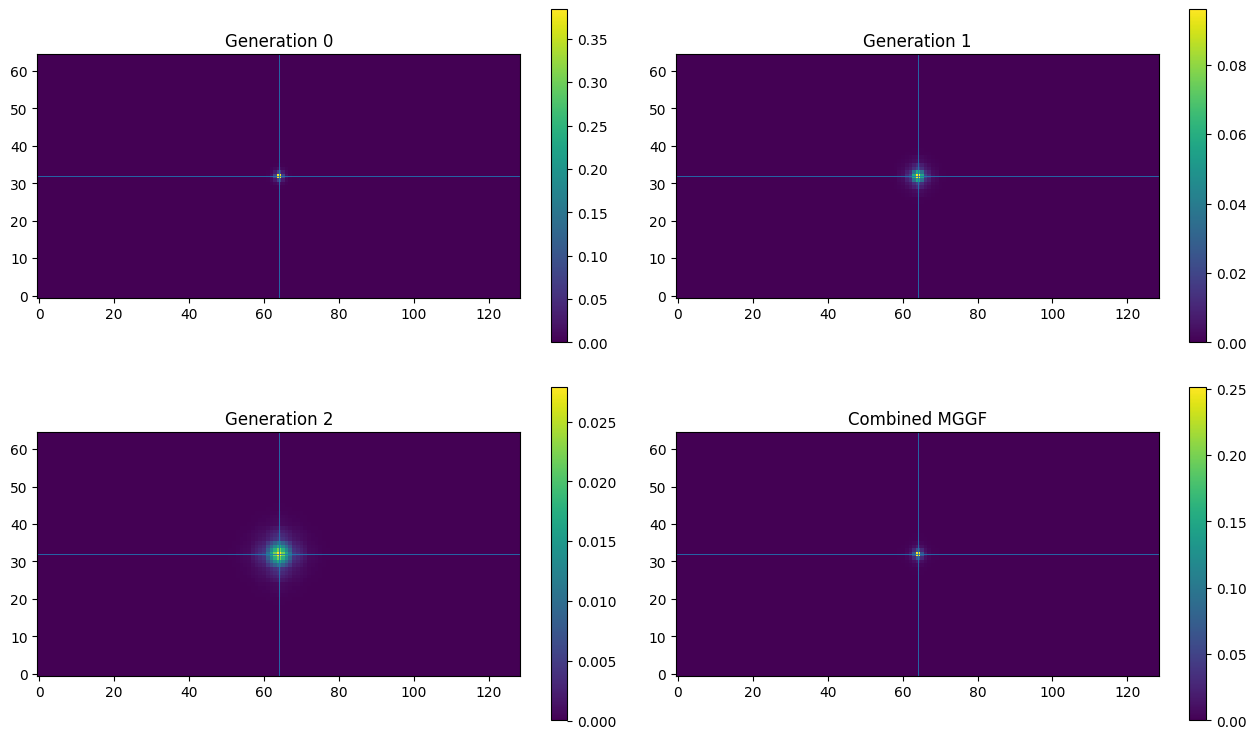


PCG iterations for center impulse
Generation 0 : 28
Generation 1 : 28
Generation 2 : 25

Complete CUDA MGGF test finished.


In [ ]:
# ============================================================
# Step 6: Complete three-generation rectangular CUDA MGGF
#
# M x =
#
#   [ w0 B0 x
#   + w1 P01 B1 R10 x
#   + w2 P02 B2 R20 x ]
#   / (w0+w1+w2)
#
# Entirely GPU-resident and matrix-free.
# ============================================================

WEIGHTS = [
    1.00,
    0.50,
    0.25
]

WEIGHT_SUM = sum(WEIGHTS)


# ------------------------------------------------------------
# Complete three-generation MGGF
# ------------------------------------------------------------
def apply_mggf_gpu(
    x0,
    A_levels,
    betas=BETA,
    weights=WEIGHTS,
    tol=1.0e-12,
    maxiter=200,
    return_generations=False
):
    """
    Apply the three-generation rectangular MGGF.

    Level 0:
        B0 x

    Level 1:
        P01 B1 R10 x

    Level 2:
        P01 P12 B2 R21 R10 x
    """

    A0, A1, A2 = A_levels

    # ========================================================
    # Generation 0
    # ========================================================
    g0, info0 = beta_filter_pcg_gpu(
        x0,
        A0,
        betas[0],
        tol=tol,
        maxiter=maxiter
    )

    # ========================================================
    # Generation 1
    # ========================================================
    x1 = restrict_adjoint_gpu(
        x0,
        A0,
        A1
    )

    b1, info1 = beta_filter_pcg_gpu(
        x1,
        A1,
        betas[1],
        tol=tol,
        maxiter=maxiter
    )

    g1 = prolong_bilinear_gpu(
        b1
    )

    # ========================================================
    # Generation 2
    # ========================================================
    x2 = restrict_adjoint_gpu(
        x1,
        A1,
        A2
    )

    b2, info2 = beta_filter_pcg_gpu(
        x2,
        A2,
        betas[2],
        tol=tol,
        maxiter=maxiter
    )

    g2_L1 = prolong_bilinear_gpu(
        b2
    )

    g2 = prolong_bilinear_gpu(
        g2_L1
    )

    # ========================================================
    # Weighted combination
    # ========================================================
    y = (
        weights[0] * g0
        +
        weights[1] * g1
        +
        weights[2] * g2
    ) / sum(weights)

    if return_generations:

        return y, {
            "g0": g0,
            "g1": g1,
            "g2": g2,
            "info0": info0,
            "info1": info1,
            "info2": info2,
        }

    return y


# ============================================================
# Basic MGGF structural diagnostics
# ============================================================

print("\nComplete CUDA MGGF diagnostics")
print("-" * 92)

A0 = A_levels_gpu[0]

ones0 = torch.ones_like(A0)

M1, info_const = apply_mggf_gpu(
    ones0,
    A_levels_gpu,
    return_generations=True
)

const_err = torch.max(
    torch.abs(M1 - 1.0)
).item()

print(
    f"Constant preservation: max|M1-1| = "
    f"{const_err:.3e}"
)


# ------------------------------------------------------------
# Random-field conservation
# ------------------------------------------------------------
torch.manual_seed(24680)

xrand = torch.randn(
    NY0,
    NX0,
    dtype=dtype_ref,
    device=device
)

yrand = apply_mggf_gpu(
    xrand,
    A_levels_gpu
)

mass_in = torch.sum(
    A0 * xrand
)

mass_out = torch.sum(
    A0 * yrand
)

mass_rel = (
    torch.abs(
        mass_out - mass_in
    ).item()
    /
    max(
        torch.sum(
            torch.abs(A0 * xrand)
        ).item(),
        1.0
    )
)

print(
    f"Area conservation     : relative error = "
    f"{mass_rel:.3e}"
)


# ------------------------------------------------------------
# Weighted self-adjointness
# ------------------------------------------------------------
torch.manual_seed(112233)

x = torch.randn(
    NY0,
    NX0,
    dtype=dtype_ref,
    device=device
)

y = torch.randn(
    NY0,
    NX0,
    dtype=dtype_ref,
    device=device
)

Mx = apply_mggf_gpu(
    x,
    A_levels_gpu
)

My = apply_mggf_gpu(
    y,
    A_levels_gpu
)

lhs = torch.sum(
    A0 * x * My
)

rhs = torch.sum(
    A0 * Mx * y
)

adj_rel = (
    torch.abs(lhs - rhs).item()
    /
    max(
        abs(lhs.item()),
        abs(rhs.item()),
        1.0
    )
)

print(
    f"Weighted self-adjoint : relative error = "
    f"{adj_rel:.3e}"
)

print("-" * 92)

print(
    "Constant preservation:",
    "PASS" if const_err < 1.0e-10 else "FAIL"
)

print(
    "Area conservation     :",
    "PASS" if mass_rel < 1.0e-10 else "FAIL"
)

print(
    "Weighted self-adjoint :",
    "PASS" if adj_rel < 1.0e-9 else "FAIL"
)


# ============================================================
# Center impulse
# ============================================================

impulse = torch.zeros(
    NY0,
    NX0,
    dtype=dtype_ref,
    device=device
)

jc = NY0 // 2
ic = NX0 // 2

# Unit MASS impulse
#
# A0=1 here, but write it generally.
impulse[jc, ic] = 1.0 / A0[jc, ic]


Mimp, G = apply_mggf_gpu(
    impulse,
    A_levels_gpu,
    return_generations=True
)


# ============================================================
# Moment diagnostics
# ============================================================

# Physical index coordinates centered on impulse
xx = torch.arange(
    NX0,
    dtype=dtype_ref,
    device=device
) - ic

yy = torch.arange(
    NY0,
    dtype=dtype_ref,
    device=device
) - jc

Y, X = torch.meshgrid(
    yy,
    xx,
    indexing="ij"
)


def impulse_diagnostics(field, A, name):
    """
    Compute mass, centroid, effective radius, min/max.
    """

    mass = torch.sum(
        A * field
    )

    xbar = (
        torch.sum(
            A * field * X
        )
        /
        mass
    )

    ybar = (
        torch.sum(
            A * field * Y
        )
        /
        mass
    )

    r2 = (
        (X - xbar)**2
        +
        (Y - ybar)**2
    )

    r_eff = torch.sqrt(
        torch.sum(
            A * field * r2
        )
        /
        mass
    )

    print(
        f"{name:12s} "
        f"mass={mass.item():.12e}   "
        f"xbar={xbar.item():+.3e}   "
        f"ybar={ybar.item():+.3e}   "
        f"r_eff={r_eff.item():.6f}   "
        f"min={field.min().item():.3e}   "
        f"max={field.max().item():.6e}"
    )

    return {
        "mass": mass.item(),
        "xbar": xbar.item(),
        "ybar": ybar.item(),
        "r_eff": r_eff.item(),
        "minimum": field.min().item(),
        "maximum": field.max().item(),
    }


print("\nCenter impulse diagnostics")
print("-" * 116)

diag0 = impulse_diagnostics(
    G["g0"],
    A0,
    "Generation 0"
)

diag1 = impulse_diagnostics(
    G["g1"],
    A0,
    "Generation 1"
)

diag2 = impulse_diagnostics(
    G["g2"],
    A0,
    "Generation 2"
)

diagM = impulse_diagnostics(
    Mimp,
    A0,
    "Combined"
)

print("-" * 116)


# ============================================================
# Expected CPU-baseline effective radii
# ============================================================

expected_r = {
    "Generation 0": 1.414214,
    "Generation 1": 3.000000,
    "Generation 2": 5.384986,
    "Combined":     2.803011,
}

print("\nComparison with validated CPU baseline")
print("-" * 78)

for name, diag in [
    ("Generation 0", diag0),
    ("Generation 1", diag1),
    ("Generation 2", diag2),
    ("Combined", diagM),
]:
    difference = (
        diag["r_eff"]
        -
        expected_r[name]
    )

    print(
        f"{name:12s}: "
        f"GPU r_eff={diag['r_eff']:.6f}   "
        f"CPU baseline={expected_r[name]:.6f}   "
        f"difference={difference:+.3e}"
    )

print("-" * 78)


# ============================================================
# Plot all generations
# ============================================================

fields = [
    ("Generation 0", G["g0"]),
    ("Generation 1", G["g1"]),
    ("Generation 2", G["g2"]),
    ("Combined MGGF", Mimp),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8)
)

for ax, (title, field) in zip(
    axes.flat,
    fields
):

    arr = (
        field
        .detach()
        .cpu()
        .numpy()
    )

    im = ax.imshow(
        arr,
        origin="lower",
        aspect="equal"
    )

    ax.set_title(title)

    ax.axvline(
        ic,
        linewidth=0.6
    )

    ax.axhline(
        jc,
        linewidth=0.6
    )

    plt.colorbar(
        im,
        ax=ax,
        shrink=0.85
    )

plt.tight_layout()
plt.show()


# ============================================================
# PCG iteration counts for the impulse case
# ============================================================

print("\nPCG iterations for center impulse")

print(
    f"Generation 0 : {G['info0']['iterations']}"
)

print(
    f"Generation 1 : {G['info1']['iterations']}"
)

print(
    f"Generation 2 : {G['info2']['iterations']}"
)

print("\nComplete CUDA MGGF test finished.")

# 7. Synchronization-Free GPU PCG and First MGGF Performance Benchmark

In [ ]:
# ============================================================
# Step 7: Synchronization-free PCG
#
# Same mathematical PCG solver as before, but:
#
#   * no .item() inside the iteration loop
#   * no CPU/GPU synchronization during iterations
#   * convergence mask remains entirely on GPU
#
# We then compare:
#
#   1. validated adaptive/synchronized float64 MGGF
#   2. no-sync float64 MGGF
#   3. no-sync float32 MGGF
# ============================================================


# ------------------------------------------------------------
# Synchronization-free PCG
# ------------------------------------------------------------
def beta_filter_pcg_gpu_nosync(
    x,
    A,
    beta,
    tol=1.0e-12,
    maxiter=40
):
    """
    Matrix-free PCG for

        (I + beta L)y = x

    through the Euclidean-SPD system

        (W + beta K)y = Wx.

    No host synchronization occurs inside the iteration loop.

    Once the GPU convergence condition is satisfied, subsequent
    loop iterations leave the solution unchanged.
    """

    ny, nx = A.shape

    # Right-hand side
    b = A * x

    # Jacobi preconditioner
    degree = build_degree_field(
        ny,
        nx,
        dtype=x.dtype,
        device=x.device
    )

    Mdiag = A + beta * degree

    # Initial guess
    y = x.clone()

    # Initial residual
    r = b - apply_H_gpu(
        y,
        A,
        beta
    )

    z = r / Mdiag
    p = z.clone()

    rz_old = torch.sum(r * z)

    bnorm2 = torch.sum(b * b)

    # GPU scalar convergence threshold
    target2 = (
        tol * tol
    ) * torch.clamp(
        bnorm2,
        min=torch.finfo(x.dtype).tiny
    )

    tiny = torch.tensor(
        torch.finfo(x.dtype).tiny,
        dtype=x.dtype,
        device=x.device
    )

    for _ in range(maxiter):

        # Current residual norm^2
        rnorm2 = torch.sum(r * r)

        # Scalar CUDA boolean -- NO host transfer
        active = rnorm2 > target2

        Hp = apply_H_gpu(
            p,
            A,
            beta
        )

        denom = torch.sum(
            p * Hp
        )

        denom_safe = torch.where(
            torch.abs(denom) > tiny,
            denom,
            torch.ones_like(denom)
        )

        # Freeze solution after convergence
        alpha = torch.where(
            active,
            rz_old / denom_safe,
            torch.zeros_like(rz_old)
        )

        y = y + alpha * p
        r = r - alpha * Hp

        z = r / Mdiag

        rz_new = torch.sum(
            r * z
        )

        rz_safe = torch.where(
            torch.abs(rz_old) > tiny,
            rz_old,
            torch.ones_like(rz_old)
        )

        gamma = torch.where(
            active,
            rz_new / rz_safe,
            torch.zeros_like(rz_new)
        )

        p = z + gamma * p

        rz_old = torch.where(
            active,
            rz_new,
            rz_old
        )

    return y


# ============================================================
# Fast three-generation CUDA MGGF
# ============================================================

def apply_mggf_gpu_nosync(
    x0,
    A_levels,
    betas=BETA,
    weights=WEIGHTS,
    tol=1.0e-12,
    maxiter=40
):

    A0, A1, A2 = A_levels

    # --------------------------------------------------------
    # Generation 0
    # --------------------------------------------------------
    g0 = beta_filter_pcg_gpu_nosync(
        x0,
        A0,
        betas[0],
        tol=tol,
        maxiter=maxiter
    )

    # --------------------------------------------------------
    # Restrict to Level 1
    # --------------------------------------------------------
    x1 = restrict_adjoint_gpu(
        x0,
        A0,
        A1
    )

    b1 = beta_filter_pcg_gpu_nosync(
        x1,
        A1,
        betas[1],
        tol=tol,
        maxiter=maxiter
    )

    g1 = prolong_bilinear_gpu(
        b1
    )

    # --------------------------------------------------------
    # Restrict to Level 2
    # --------------------------------------------------------
    x2 = restrict_adjoint_gpu(
        x1,
        A1,
        A2
    )

    b2 = beta_filter_pcg_gpu_nosync(
        x2,
        A2,
        betas[2],
        tol=tol,
        maxiter=maxiter
    )

    g2 = prolong_bilinear_gpu(
        prolong_bilinear_gpu(
            b2
        )
    )

    return (
        weights[0] * g0
        +
        weights[1] * g1
        +
        weights[2] * g2
    ) / sum(weights)


# ============================================================
# PART A
# float64 correctness comparison with validated CUDA MGGF
# ============================================================

torch.manual_seed(13579)

x64 = torch.randn(
    NY0,
    NX0,
    dtype=torch.float64,
    device=device
)

# Validated reference
y_ref64 = apply_mggf_gpu(
    x64,
    A_levels_gpu,
    tol=1.0e-12,
    maxiter=200
)

# New synchronization-free version
y_fast64 = apply_mggf_gpu_nosync(
    x64,
    A_levels_gpu,
    tol=1.0e-12,
    maxiter=40
)

torch.cuda.synchronize()

rel64 = (
    torch.linalg.vector_norm(
        y_fast64 - y_ref64
    )
    /
    torch.linalg.vector_norm(
        y_ref64
    )
).item()

max64 = torch.max(
    torch.abs(
        y_fast64 - y_ref64
    )
).item()

print("\nNo-sync float64 correctness")
print("-" * 72)

print(
    f"Relative difference : {rel64:.3e}"
)

print(
    f"Maximum difference  : {max64:.3e}"
)

print(
    "float64 equivalence :",
    "PASS" if rel64 < 1.0e-11 else "FAIL"
)


# ============================================================
# PART B
# Build float32 hierarchy
# ============================================================

A_levels_gpu32 = [
    A.to(dtype=torch.float32)
    for A in A_levels_gpu
]

x32 = x64.to(
    dtype=torch.float32
)


# ------------------------------------------------------------
# float32 MGGF
#
# A tolerance around 1e-6 is appropriate for single precision.
# ------------------------------------------------------------
y_fast32 = apply_mggf_gpu_nosync(
    x32,
    A_levels_gpu32,
    tol=1.0e-6,
    maxiter=32
)

torch.cuda.synchronize()


# ------------------------------------------------------------
# Compare float32 with float64 reference
# ------------------------------------------------------------
y_fast32_as64 = y_fast32.to(
    dtype=torch.float64
)

rel32 = (
    torch.linalg.vector_norm(
        y_fast32_as64 - y_ref64
    )
    /
    torch.linalg.vector_norm(
        y_ref64
    )
).item()

max32 = torch.max(
    torch.abs(
        y_fast32_as64 - y_ref64
    )
).item()

print("\nfloat32 versus float64 reference")
print("-" * 72)

print(
    f"Relative difference : {rel32:.3e}"
)

print(
    f"Maximum difference  : {max32:.3e}"
)


# ============================================================
# PART C
# Constant and conservation check in float32
# ============================================================

ones32 = torch.ones(
    NY0,
    NX0,
    dtype=torch.float32,
    device=device
)

M1_32 = apply_mggf_gpu_nosync(
    ones32,
    A_levels_gpu32,
    tol=1.0e-6,
    maxiter=32
)

const32 = torch.max(
    torch.abs(
        M1_32 - 1.0
    )
).item()


torch.manual_seed(97531)

xr32 = torch.randn(
    NY0,
    NX0,
    dtype=torch.float32,
    device=device
)

yr32 = apply_mggf_gpu_nosync(
    xr32,
    A_levels_gpu32,
    tol=1.0e-6,
    maxiter=32
)

mass_in32 = torch.sum(
    A_levels_gpu32[0] * xr32
)

mass_out32 = torch.sum(
    A_levels_gpu32[0] * yr32
)

mass_rel32 = (
    torch.abs(
        mass_out32 - mass_in32
    )
    /
    torch.sum(
        torch.abs(
            A_levels_gpu32[0] * xr32
        )
    )
).item()

print("\nfloat32 structural check")
print("-" * 72)

print(
    f"max |M1-1|          : {const32:.3e}"
)

print(
    f"mass relative error : {mass_rel32:.3e}"
)


# ============================================================
# PART D
# Timing utility
# ============================================================

def benchmark_cuda(
    function,
    n_warmup=10,
    n_repeat=100
):
    """
    Wall-clock benchmark with synchronization only outside
    the measured group of applications.
    """

    # Warm-up
    for _ in range(n_warmup):
        function()

    torch.cuda.synchronize()

    t0 = time.perf_counter()

    for _ in range(n_repeat):
        function()

    torch.cuda.synchronize()

    t1 = time.perf_counter()

    return (
        t1 - t0
    ) / n_repeat


# ============================================================
# PART E
# Benchmark
# ============================================================

print("\nWarming up CUDA benchmark ...")


# ------------------------------------------------------------
# 1. Original validation version, float64
#    This synchronizes every PCG iteration.
# ------------------------------------------------------------
def run_original64():

    return apply_mggf_gpu(
        x64,
        A_levels_gpu,
        tol=1.0e-12,
        maxiter=200
    )


# ------------------------------------------------------------
# 2. No-sync float64
# ------------------------------------------------------------
def run_fast64():

    return apply_mggf_gpu_nosync(
        x64,
        A_levels_gpu,
        tol=1.0e-12,
        maxiter=40
    )


# ------------------------------------------------------------
# 3. No-sync float32
# ------------------------------------------------------------
def run_fast32():

    return apply_mggf_gpu_nosync(
        x32,
        A_levels_gpu32,
        tol=1.0e-6,
        maxiter=32
    )


# Original synchronized solver is expensive to benchmark,
# so use fewer repetitions.
t_original64 = benchmark_cuda(
    run_original64,
    n_warmup=3,
    n_repeat=10
)

t_fast64 = benchmark_cuda(
    run_fast64,
    n_warmup=10,
    n_repeat=100
)

t_fast32 = benchmark_cuda(
    run_fast32,
    n_warmup=10,
    n_repeat=100
)


print("\nFirst CUDA MGGF performance benchmark")
print("=" * 78)

print(
    f"Grid                    : "
    f"{NX0} x {NY0} = {NX0*NY0:,} points"
)

print(
    f"Original sync float64   : "
    f"{1e3*t_original64:.4f} ms / field"
)

print(
    f"No-sync float64         : "
    f"{1e3*t_fast64:.4f} ms / field"
)

print(
    f"No-sync float32         : "
    f"{1e3*t_fast32:.4f} ms / field"
)

print("-" * 78)

print(
    f"Speedup from no-sync    : "
    f"{t_original64/t_fast64:.2f} x"
)

print(
    f"float32 / float64 speed : "
    f"{t_fast64/t_fast32:.2f} x"
)

print("=" * 78)


No-sync float64 correctness
------------------------------------------------------------------------
Relative difference : 0.000e+00
Maximum difference  : 0.000e+00
float64 equivalence : PASS

float32 versus float64 reference
------------------------------------------------------------------------
Relative difference : 7.078e-07
Maximum difference  : 1.018e-06

float32 structural check
------------------------------------------------------------------------
max |M1-1|          : 0.000e+00
mass relative error : 9.320e-09

Warming up CUDA benchmark ...

First CUDA MGGF performance benchmark
Grid                    : 129 x 65 = 8,385 points
Original sync float64   : 61.9494 ms / field
No-sync float64         : 81.4588 ms / field
No-sync float32         : 74.0802 ms / field
------------------------------------------------------------------------------
Speedup from no-sync    : 0.76 x
float32 / float64 speed : 1.10 x


# 8. Optimized Fixed-Iteration CUDA PCG and GPU Scaling Test


Fixed-iteration float32 validation
----------------------------------------------------------------------
relative difference = 6.907e-07
validation: PASS

Small-grid optimized timing
----------------------------------------------------------------------
Grid              : 129 x 65
Fixed float32 MGGF: 43.4609 ms
----------------------------------------------------------------------

CUDA MGGF SCALING TEST
            Grid    Fine points      Time [ms]       ns/point         Mpts/s
----------------------------------------------------------------------------------------------
  129 x 65             8,385        44.3492       5289.108          0.189
  257 x 129           33,153        43.1903       1302.758          0.768
  513 x 257          131,841        44.0332        333.987          2.994
 1025 x 513          525,825        44.1774         84.015         11.903
 2049 x 1025       2,100,225        45.2590         21.550         46.405


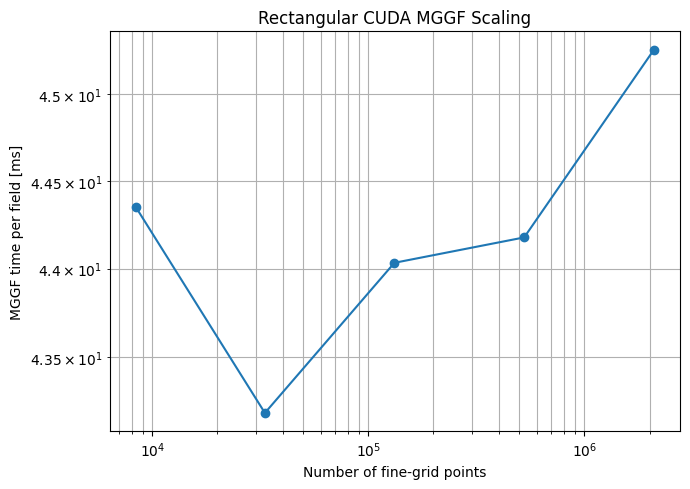

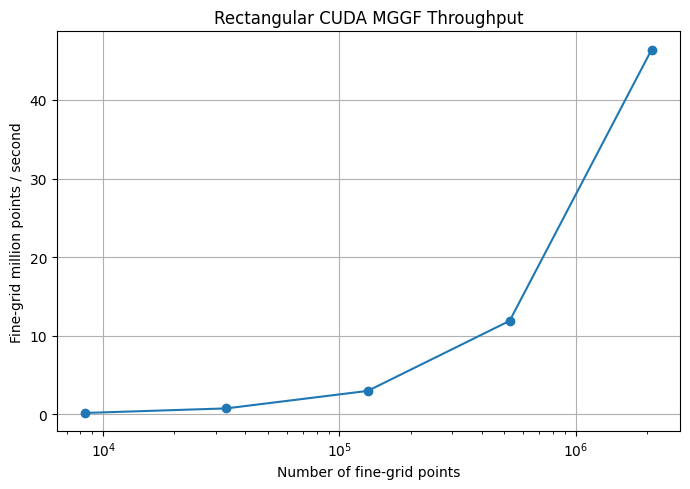

In [ ]:
# ============================================================
# Step 8: Performance-oriented fixed-iteration CUDA MGGF
#
# Changes relative to validation version:
#
#   1. No .item() inside solver
#   2. No convergence tests
#   3. No torch.where convergence masks
#   4. Degree/Jacobi diagonal precomputed
#   5. Fixed PCG iteration count
#
# This is now a performance implementation.
# ============================================================


# ============================================================
# Precompute level metadata
# ============================================================

def prepare_level_solver(A, beta):
    """
    Precompute quantities that do not change between applications.
    """

    ny, nx = A.shape

    degree = build_degree_field(
        ny,
        nx,
        dtype=A.dtype,
        device=A.device
    )

    Mdiag = A + beta * degree

    return {
        "A": A,
        "beta": beta,
        "Mdiag": Mdiag,
    }

# ============================================================
# 15A. NaN-safe fixed-iteration PCG
# ============================================================

def beta_filter_pcg_fixed_gpu(
    x,
    solver,
    niter
):
    """
    Fixed-iteration matrix-free PCG.

    Production-safe version:

      - no CPU synchronization
      - no convergence test
      - no .item()
      - no iteration masking
      - safe for exact-zero residuals
      - preserves fixed iteration count

    The zero-residual safeguards prevent 0/0 when the
    initial guess is already the exact solution, as occurs
    for a constant field because B 1 = 1.
    """

    A = solver["A"]
    beta = solver["beta"]
    Mdiag = solver["Mdiag"]

    # ========================================================
    # RHS of Euclidean-SPD system
    #
    #     (A + beta K) y = A x
    #
    # ========================================================

    b = A * x


    # ========================================================
    # Initial guess
    # ========================================================

    y = x.clone()


    # ========================================================
    # Initial residual
    # ========================================================

    r = b - apply_H_gpu(
        y,
        A,
        beta
    )

    z = r / Mdiag
    p = z.clone()

    rz = torch.sum(
        r * z
    )


    # ========================================================
    # Fixed PCG iterations
    # ========================================================

    for _ in range(niter):

        Hp = apply_H_gpu(
            p,
            A,
            beta
        )


        # ----------------------------------------------------
        # alpha denominator
        #
        # For an already-converged solution:
        #
        #     p = 0
        #     Hp = 0
        #     p^T Hp = 0
        #
        # Replace only an exact-zero denominator by 1.
        # Then alpha = 0 / 1 = 0 and y remains unchanged.
        #
        # No CPU synchronization is introduced.
        # ----------------------------------------------------

        pHp = torch.sum(
            p * Hp
        )

        safe_pHp = torch.where(
            pHp != 0,
            pHp,
            torch.ones_like(pHp)
        )

        alpha = (
            rz
            /
            safe_pHp
        )


        # ----------------------------------------------------
        # Update solution and residual
        # ----------------------------------------------------

        y = (
            y
            +
            alpha * p
        )

        r = (
            r
            -
            alpha * Hp
        )


        # ----------------------------------------------------
        # Preconditioning
        # ----------------------------------------------------

        z = (
            r
            /
            Mdiag
        )


        # ----------------------------------------------------
        # New residual scalar
        # ----------------------------------------------------

        rz_new = torch.sum(
            r * z
        )


        # ----------------------------------------------------
        # beta_CG denominator
        #
        # If rz is exactly zero, use denominator 1.
        # Then an already-converged state gives
        #
        #     beta_CG = 0
        #
        # and p remains zero.
        # ----------------------------------------------------

        safe_rz = torch.where(
            rz != 0,
            rz,
            torch.ones_like(rz)
        )

        beta_cg = (
            rz_new
            /
            safe_rz
        )


        # ----------------------------------------------------
        # Search direction
        # ----------------------------------------------------

        p = (
            z
            +
            beta_cg * p
        )

        rz = rz_new


    return y

# ============================================================
# Prepare one three-level MGGF hierarchy
# ============================================================

def prepare_mggf_solver(
    A_levels,
    betas
):
    return [
        prepare_level_solver(
            A_levels[k],
            betas[k]
        )
        for k in range(3)
    ]


# ============================================================
# Fixed-iteration MGGF
# ============================================================

def apply_mggf_fixed_gpu(
    x0,
    solvers,
    weights=WEIGHTS,
    niters=(28, 28, 25)
):
    """
    Complete 3-generation CUDA MGGF using fixed PCG iterations.
    """

    A0 = solvers[0]["A"]
    A1 = solvers[1]["A"]
    A2 = solvers[2]["A"]

    # Generation 0
    g0 = beta_filter_pcg_fixed_gpu(
        x0,
        solvers[0],
        niters[0]
    )

    # Restrict to L1
    x1 = restrict_adjoint_gpu(
        x0,
        A0,
        A1
    )

    b1 = beta_filter_pcg_fixed_gpu(
        x1,
        solvers[1],
        niters[1]
    )

    g1 = prolong_bilinear_gpu(
        b1
    )

    # Restrict to L2
    x2 = restrict_adjoint_gpu(
        x1,
        A1,
        A2
    )

    b2 = beta_filter_pcg_fixed_gpu(
        x2,
        solvers[2],
        niters[2]
    )

    g2 = prolong_bilinear_gpu(
        prolong_bilinear_gpu(
            b2
        )
    )

    return (
        weights[0] * g0
        +
        weights[1] * g1
        +
        weights[2] * g2
    ) / sum(weights)


# ============================================================
# First: validate fixed-iteration float32 version
# ============================================================

solver32 = prepare_mggf_solver(
    A_levels_gpu32,
    BETA
)

torch.manual_seed(424242)

x_test32 = torch.randn(
    NY0,
    NX0,
    dtype=torch.float32,
    device=device
)

y_fixed32 = apply_mggf_fixed_gpu(
    x_test32,
    solver32,
    niters=(28, 28, 25)
)

# Reference using validated no-sync version
y_ref32 = apply_mggf_gpu_nosync(
    x_test32,
    A_levels_gpu32,
    tol=1.0e-6,
    maxiter=32
)

torch.cuda.synchronize()

rel_fixed = (
    torch.linalg.vector_norm(
        y_fixed32 - y_ref32
    )
    /
    torch.linalg.vector_norm(
        y_ref32
    )
).item()

print("\nFixed-iteration float32 validation")
print("-" * 70)
print(f"relative difference = {rel_fixed:.3e}")
print(
    "validation:",
    "PASS" if rel_fixed < 5.0e-6 else "CHECK"
)


# ============================================================
# Timing on original small grid
# ============================================================

def run_fixed32():
    return apply_mggf_fixed_gpu(
        x_test32,
        solver32,
        niters=(28, 28, 25)
    )


t_fixed32 = benchmark_cuda(
    run_fixed32,
    n_warmup=10,
    n_repeat=100
)

print("\nSmall-grid optimized timing")
print("-" * 70)
print(
    f"Grid              : {NX0} x {NY0}"
)
print(
    f"Fixed float32 MGGF: {1e3*t_fixed32:.4f} ms"
)
print("-" * 70)


# ============================================================
# Utility: build 3-level hierarchy for arbitrary odd grid
# ============================================================

def build_gpu_hierarchy(
    nx0,
    ny0,
    dtype=torch.float32
):
    """
    Build three rectangular nested levels and their area weights.
    """

    A0 = torch.ones(
        ny0,
        nx0,
        dtype=dtype,
        device=device
    )

    A1 = build_coarse_weights_from_fine(
        A0
    )

    A2 = build_coarse_weights_from_fine(
        A1
    )

    return [
        A0,
        A1,
        A2
    ]


# ============================================================
# Scaling grids
# ============================================================

GRID_SIZES = [
    (129, 65),
    (257, 129),
    (513, 257),
    (1025, 513),
    (2049, 1025),
]


# ============================================================
# GPU scaling benchmark
# ============================================================

scaling_results = []

print("\nCUDA MGGF SCALING TEST")
print("=" * 94)

print(
    f"{'Grid':>16s} "
    f"{'Fine points':>14s} "
    f"{'Time [ms]':>14s} "
    f"{'ns/point':>14s} "
    f"{'Mpts/s':>14s}"
)

print("-" * 94)


for nx, ny in GRID_SIZES:

    # --------------------------------------------------------
    # Hierarchy
    # --------------------------------------------------------
    Alev = build_gpu_hierarchy(
        nx,
        ny,
        dtype=torch.float32
    )

    solvers = prepare_mggf_solver(
        Alev,
        BETA
    )

    # --------------------------------------------------------
    # Random field
    # --------------------------------------------------------
    torch.manual_seed(
        1000 + nx
    )

    x = torch.randn(
        ny,
        nx,
        dtype=torch.float32,
        device=device
    )

    # --------------------------------------------------------
    # Appropriate repetition count
    # --------------------------------------------------------
    npoints = nx * ny

    if npoints < 50_000:
        nrepeat = 100

    elif npoints < 300_000:
        nrepeat = 50

    elif npoints < 1_000_000:
        nrepeat = 20

    else:
        nrepeat = 10

    # --------------------------------------------------------
    # Closure for benchmark
    # --------------------------------------------------------
    def run():
        return apply_mggf_fixed_gpu(
            x,
            solvers,
            niters=(28, 28, 25)
        )

    # --------------------------------------------------------
    # Warm-up + timing
    # --------------------------------------------------------
    t = benchmark_cuda(
        run,
        n_warmup=5,
        n_repeat=nrepeat
    )

    ns_per_point = (
        t / npoints * 1.0e9
    )

    mpts_per_sec = (
        npoints / t / 1.0e6
    )

    scaling_results.append({
        "nx": nx,
        "ny": ny,
        "N": npoints,
        "time": t,
        "ns_per_point": ns_per_point,
        "mpts_per_sec": mpts_per_sec,
    })

    print(
        f"{nx:5d} x {ny:<5d} "
        f"{npoints:14,d} "
        f"{1e3*t:14.4f} "
        f"{ns_per_point:14.3f} "
        f"{mpts_per_sec:14.3f}"
    )

    # --------------------------------------------------------
    # Free temporary hierarchy before next size
    # --------------------------------------------------------
    del x
    del Alev
    del solvers

    torch.cuda.empty_cache()


print("=" * 94)


# ============================================================
# Scaling plot
# ============================================================

Ns = np.array([
    r["N"]
    for r in scaling_results
])

times_ms = 1.0e3 * np.array([
    r["time"]
    for r in scaling_results
])


plt.figure(
    figsize=(7, 5)
)

plt.loglog(
    Ns,
    times_ms,
    marker="o"
)

plt.xlabel(
    "Number of fine-grid points"
)

plt.ylabel(
    "MGGF time per field [ms]"
)

plt.title(
    "Rectangular CUDA MGGF Scaling"
)

plt.grid(
    True,
    which="both"
)

plt.tight_layout()
plt.show()


# ============================================================
# Throughput plot
# ============================================================

throughput = np.array([
    r["mpts_per_sec"]
    for r in scaling_results
])


plt.figure(
    figsize=(7, 5)
)

plt.semilogx(
    Ns,
    throughput,
    marker="o"
)

plt.xlabel(
    "Number of fine-grid points"
)

plt.ylabel(
    "Fine-grid million points / second"
)

plt.title(
    "Rectangular CUDA MGGF Throughput"
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()

# 9. Large-Grid A100 Scaling and GPU Memory Test


LARGE-GRID A100 MGGF SCALING
              Grid     Fine points     Time [ms]      ns/point        Mpts/s     Peak GB     Free GB
--------------------------------------------------------------------------------------------------------------------

Preparing 2049 x 1025 (2,100,225 fine points) ...
   2049 x 1025          2,100,225        38.947        18.544        53.925       0.132      38.802

Preparing 4097 x 2049 (8,394,753 fine points) ...
   4097 x 2049          8,394,753        64.437         7.676       130.279       0.499      38.417

Preparing 8193 x 4097 (33,566,721 fine points) ...
   8193 x 4097         33,566,721       252.704         7.528       132.830       1.964      36.871



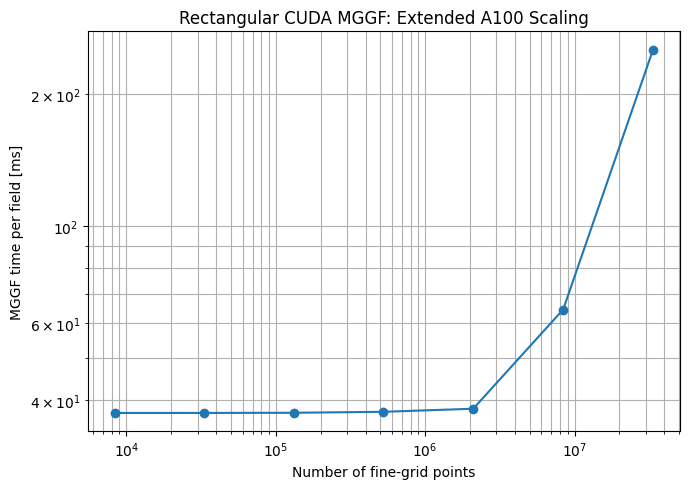

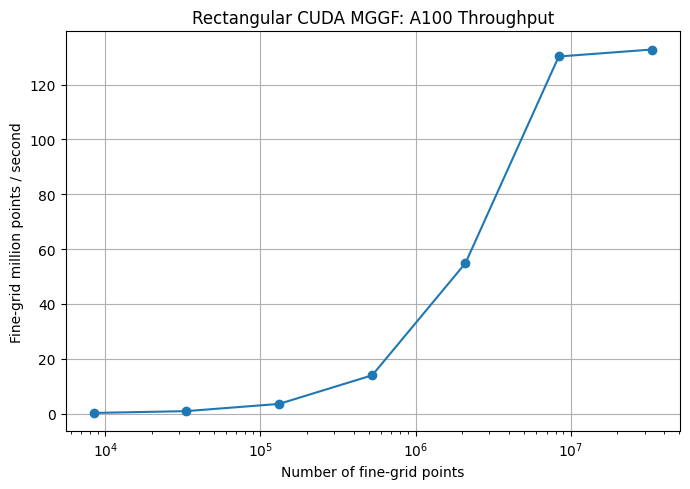

In [ ]:
# ============================================================
# Step 9: Large-grid A100 scaling and GPU-memory test
#
# Purpose:
#   * extend scaling beyond 2 million points
#   * determine where A100 throughput begins to saturate
#   * measure actual peak CUDA memory
#   * safely skip a case if available memory becomes marginal
#
# Uses the same validated fixed-iteration float32 MGGF.
# ============================================================

import gc


# ------------------------------------------------------------
# CUDA-event benchmark
# ------------------------------------------------------------
@torch.no_grad()
def benchmark_cuda_events(
    function,
    n_warmup=3,
    n_repeat=5
):
    """
    Measure average GPU execution time using CUDA events.
    """

    # Warm-up
    for _ in range(n_warmup):
        _ = function()

    torch.cuda.synchronize()

    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )

    start.record()

    for _ in range(n_repeat):
        _ = function()

    end.record()

    torch.cuda.synchronize()

    elapsed_ms = start.elapsed_time(end)

    return elapsed_ms / n_repeat


# ------------------------------------------------------------
# GPU memory information
# ------------------------------------------------------------
def gpu_memory_info():
    free_bytes, total_bytes = torch.cuda.mem_get_info()

    return (
        free_bytes / 1024**3,
        total_bytes / 1024**3
    )


# ============================================================
# Larger grids
#
# Existing largest:
#
#     2049 x 1025  ~ 2.10 million
#
# New:
#
#     4097 x 2049  ~ 8.39 million
#     8193 x 4097  ~ 33.56 million
#
# Optional:
#
#     16385 x 8193 ~ 134 million
#
# The last case is attempted only if memory usage from the
# preceding case suggests it is safe.
# ============================================================

LARGE_GRIDS = [
    (2049, 1025),
    (4097, 2049),
    (8193, 4097),
]


large_results = []


print("\nLARGE-GRID A100 MGGF SCALING")
print("=" * 116)

print(
    f"{'Grid':>18s}"
    f"{'Fine points':>16s}"
    f"{'Time [ms]':>14s}"
    f"{'ns/point':>14s}"
    f"{'Mpts/s':>14s}"
    f"{'Peak GB':>12s}"
    f"{'Free GB':>12s}"
)

print("-" * 116)


for nx, ny in LARGE_GRIDS:

    # --------------------------------------------------------
    # Clean previous allocations
    # --------------------------------------------------------
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    free_gb_before, total_gb = gpu_memory_info()

    npoints = nx * ny

    print(
        f"\nPreparing {nx} x {ny} "
        f"({npoints:,} fine points) ..."
    )

    # --------------------------------------------------------
    # Build hierarchy
    # --------------------------------------------------------
    Alev = build_gpu_hierarchy(
        nx,
        ny,
        dtype=torch.float32
    )

    solvers = prepare_mggf_solver(
        Alev,
        BETA
    )

    # --------------------------------------------------------
    # Test field
    # --------------------------------------------------------
    torch.manual_seed(
        5000 + nx
    )

    x = torch.randn(
        ny,
        nx,
        dtype=torch.float32,
        device=device
    )

    # --------------------------------------------------------
    # Repetitions
    # --------------------------------------------------------
    if npoints < 5_000_000:
        nrepeat = 10

    elif npoints < 20_000_000:
        nrepeat = 5

    else:
        nrepeat = 3

    # --------------------------------------------------------
    # MGGF closure
    # --------------------------------------------------------
    @torch.no_grad()
    def run_large():

        return apply_mggf_fixed_gpu(
            x,
            solvers,
            niters=(28, 28, 25)
        )

    # --------------------------------------------------------
    # First execution -- also catches memory failure
    # --------------------------------------------------------
    try:

        torch.cuda.reset_peak_memory_stats()

        y_test = run_large()

        torch.cuda.synchronize()

    except torch.cuda.OutOfMemoryError:

        print(
            f"SKIPPED: CUDA out of memory for "
            f"{nx} x {ny}"
        )

        del x
        del Alev
        del solvers

        gc.collect()
        torch.cuda.empty_cache()

        continue


    # --------------------------------------------------------
    # Correctness sanity check
    #
    # We do not compare with CPU here.
    # Check that result contains finite values.
    # --------------------------------------------------------
    finite_ok = torch.isfinite(
        y_test
    ).all().item()

    del y_test

    if not finite_ok:

        print(
            "WARNING: non-finite values detected."
        )


    # --------------------------------------------------------
    # Reset memory statistic so benchmark peak is measured
    # cleanly
    # --------------------------------------------------------
    torch.cuda.reset_peak_memory_stats()

    # --------------------------------------------------------
    # Benchmark
    # --------------------------------------------------------
    time_ms = benchmark_cuda_events(
        run_large,
        n_warmup=2,
        n_repeat=nrepeat
    )

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Peak memory
    # --------------------------------------------------------
    peak_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    free_gb_after, _ = gpu_memory_info()

    # --------------------------------------------------------
    # Performance metrics
    # --------------------------------------------------------
    time_s = time_ms * 1.0e-3

    ns_per_point = (
        time_s
        / npoints
        * 1.0e9
    )

    mpts_per_sec = (
        npoints
        / time_s
        / 1.0e6
    )

    large_results.append({
        "nx": nx,
        "ny": ny,
        "N": npoints,
        "time_ms": time_ms,
        "ns_per_point": ns_per_point,
        "mpts_per_sec": mpts_per_sec,
        "peak_gb": peak_gb,
    })

    print(
        f"{nx:7d} x {ny:<7d}"
        f"{npoints:16,d}"
        f"{time_ms:14.3f}"
        f"{ns_per_point:14.3f}"
        f"{mpts_per_sec:14.3f}"
        f"{peak_gb:12.3f}"
        f"{free_gb_after:12.3f}"
    )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------
    del x
    del Alev
    del solvers

    gc.collect()
    torch.cuda.empty_cache()


print("\n" + "=" * 116)


# ============================================================
# Combine old and new scaling results
# ============================================================

combined_N = np.array(
    [r["N"] for r in scaling_results]
    +
    [
        r["N"]
        for r in large_results
        if r["N"] > scaling_results[-1]["N"]
    ]
)

combined_time_ms = np.array(
    [
        1.0e3 * r["time"]
        for r in scaling_results
    ]
    +
    [
        r["time_ms"]
        for r in large_results
        if r["N"] > scaling_results[-1]["N"]
    ]
)

combined_throughput = (
    combined_N
    /
    (combined_time_ms * 1.0e-3)
    /
    1.0e6
)


# ============================================================
# Plot: runtime
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.loglog(
    combined_N,
    combined_time_ms,
    marker="o"
)

plt.xlabel(
    "Number of fine-grid points"
)

plt.ylabel(
    "MGGF time per field [ms]"
)

plt.title(
    "Rectangular CUDA MGGF: Extended A100 Scaling"
)

plt.grid(
    True,
    which="both"
)

plt.tight_layout()
plt.show()


# ============================================================
# Plot: throughput
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.semilogx(
    combined_N,
    combined_throughput,
    marker="o"
)

plt.xlabel(
    "Number of fine-grid points"
)

plt.ylabel(
    "Fine-grid million points / second"
)

plt.title(
    "Rectangular CUDA MGGF: A100 Throughput"
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()

# 10. torch.compile Test of the Fixed-Iteration Beta Solver

In [ ]:
# ============================================================
# Step 10: torch.compile optimization experiment
#
# Compare:
#
#   eager PyTorch fixed-iteration beta filter
#
#       versus
#
#   torch.compile fixed-iteration beta filter
#
# at several grid sizes.
#
# Mathematics is unchanged.
# ============================================================

import torch
import time
import gc


# ------------------------------------------------------------
# Wrapper with fixed iteration count
#
# We compile one solver corresponding to a fixed beta/level.
# ------------------------------------------------------------
def make_beta_function(
    solver,
    niter
):

    def beta_function(x):

        return beta_filter_pcg_fixed_gpu(
            x,
            solver,
            niter
        )

    return beta_function


# ============================================================
# Test grids
# ============================================================

COMPILE_TEST_GRIDS = [
    (129, 65),
    (513, 257),
    (2049, 1025),
    (4097, 2049),
]


print("\ntorch.compile BETA-FILTER TEST")
print("=" * 104)

print(
    f"{'Grid':>18s}"
    f"{'Points':>14s}"
    f"{'Eager [ms]':>14s}"
    f"{'Compile [ms]':>16s}"
    f"{'Speedup':>12s}"
    f"{'Rel error':>16s}"
)

print("-" * 104)


compile_results = []


for nx, ny in COMPILE_TEST_GRIDS:

    gc.collect()
    torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Use Level-0 beta = 0.5
    # --------------------------------------------------------
    A = torch.ones(
        ny,
        nx,
        dtype=torch.float32,
        device=device
    )

    solver = prepare_level_solver(
        A,
        beta=0.5
    )

    torch.manual_seed(
        nx + 9000
    )

    x = torch.randn(
        ny,
        nx,
        dtype=torch.float32,
        device=device
    )

    # --------------------------------------------------------
    # Eager function
    # --------------------------------------------------------
    eager_fn = make_beta_function(
        solver,
        niter=28
    )

    # --------------------------------------------------------
    # Compile
    #
    # fullgraph=False is safer for this first experiment.
    # --------------------------------------------------------
    compiled_fn = torch.compile(
        eager_fn,
        mode="reduce-overhead",
        fullgraph=False
    )

    # --------------------------------------------------------
    # Eager reference
    # --------------------------------------------------------
    with torch.no_grad():

        y_eager = eager_fn(x)

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # First compiled call triggers compilation.
    #
    # DO NOT time this call.
    # --------------------------------------------------------
    print(
        f"\nCompiling for {nx} x {ny} ..."
    )

    with torch.no_grad():

        y_comp = compiled_fn(x)

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Correctness
    # --------------------------------------------------------
    rel_error = (
        torch.linalg.vector_norm(
            y_comp - y_eager
        )
        /
        torch.linalg.vector_norm(
            y_eager
        )
    ).item()

    # --------------------------------------------------------
    # Benchmark helper
    # --------------------------------------------------------
    def benchmark_fn(
        fn,
        nrepeat
    ):

        # Warm-up
        with torch.no_grad():

            for _ in range(5):
                _ = fn(x)

        torch.cuda.synchronize()

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        with torch.no_grad():

            for _ in range(nrepeat):
                _ = fn(x)

        end.record()

        torch.cuda.synchronize()

        return (
            start.elapsed_time(end)
            /
            nrepeat
        )


    # --------------------------------------------------------
    # Repetition count
    # --------------------------------------------------------
    npoints = nx * ny

    if npoints < 200_000:
        nrepeat = 100

    elif npoints < 3_000_000:
        nrepeat = 30

    else:
        nrepeat = 10


    # --------------------------------------------------------
    # Timing
    # --------------------------------------------------------
    eager_ms = benchmark_fn(
        eager_fn,
        nrepeat
    )

    compiled_ms = benchmark_fn(
        compiled_fn,
        nrepeat
    )

    speedup = (
        eager_ms
        /
        compiled_ms
    )

    compile_results.append({
        "nx": nx,
        "ny": ny,
        "N": npoints,
        "eager_ms": eager_ms,
        "compiled_ms": compiled_ms,
        "speedup": speedup,
        "rel_error": rel_error,
    })


    print(
        f"{nx:7d} x {ny:<7d}"
        f"{npoints:14,d}"
        f"{eager_ms:14.4f}"
        f"{compiled_ms:16.4f}"
        f"{speedup:12.2f}"
        f"{rel_error:16.3e}"
    )


    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------
    del x
    del A
    del solver
    del eager_fn
    del compiled_fn
    del y_eager
    del y_comp

    gc.collect()
    torch.cuda.empty_cache()


print("\n" + "=" * 104)


torch.compile BETA-FILTER TEST
              Grid        Points    Eager [ms]    Compile [ms]     Speedup       Rel error
--------------------------------------------------------------------------------------------------------

Compiling for 129 x 65 ...
    129 x 65              8,385       11.5507          0.6522       17.71       1.411e-07

Compiling for 513 x 257 ...
    513 x 257           131,841       12.1113          1.1920       10.16       1.469e-07

Compiling for 2049 x 1025 ...
   2049 x 1025        2,100,225       12.1781          9.1379        1.33       1.491e-07

Compiling for 4097 x 2049 ...
   4097 x 2049        8,394,753       50.2207         36.4287        1.38       1.486e-07



# 11. Compile the Complete Three-Generation CUDA MGGF


COMPILED COMPLETE CUDA MGGF
              Grid        Points    Eager [ms]   Compiled [ms]     Speedup        Mpts/s     Rel error
----------------------------------------------------------------------------------------------------------------

Compiling complete MGGF for 129 x 65 ...
    129 x 65              8,385       35.3264          1.2233       28.88         6.854     1.316e-07

Compiling complete MGGF for 257 x 129 ...


W0829 12:36:22.959000 4940 torch/utils/_sympy/interp.py:179] [1/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 12:36:22.962000 4940 torch/utils/_sympy/interp.py:179] [1/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 12:36:23.436000 4940 torch/utils/_sympy/interp.py:179] [1/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 12:36:23.438000 4940 torch/utils/_sympy/interp.py:179] [1/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 12:36:35.628000 4940 torch/utils/_sympy/interp.py:179] [1/1] failed while executing pow_by_natural([VR[2, 4611686018427387902], VR[-1, -1]])
W0829 12:36:35.631000 4940 torch/utils/_sympy/interp.py:179] [1/1] failed while executing pow_by_natural([VR[2, 4611686018427387902], VR[-1, -1]])
W0829 12:36:36.176000 4940 torch/utils/_sympy/interp.py:179] [1/1] failed while executing pow_by_natural([VR[2, 461168

    257 x 129            33,153       35.3748          2.3977       14.75        13.827     1.362e-07

Compiling complete MGGF for 513 x 257 ...
    513 x 257           131,841       35.9721          4.2751        8.41        30.840     1.363e-07

Compiling complete MGGF for 1025 x 513 ...
   1025 x 513           525,825       36.6690         13.1267        2.79        40.058     1.365e-07

Compiling complete MGGF for 2049 x 1025 ...
   2049 x 1025        2,100,225       36.8365         46.5332        0.79        45.134     1.354e-07

Compiling complete MGGF for 4097 x 2049 ...
   4097 x 2049        8,394,753       64.4616        192.2781        0.34        43.659     1.378e-07



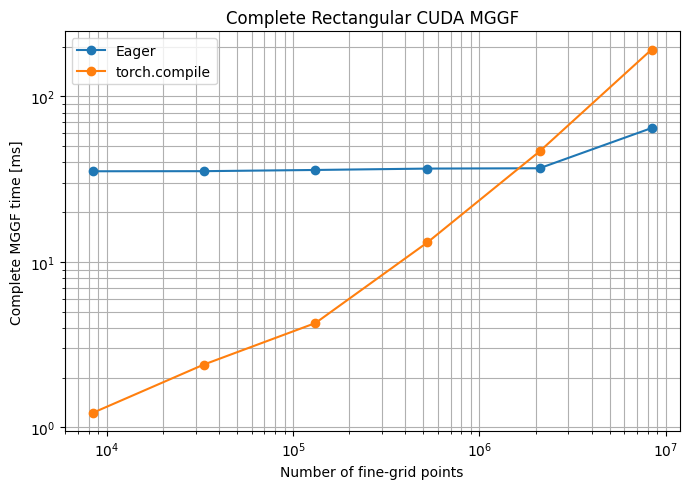

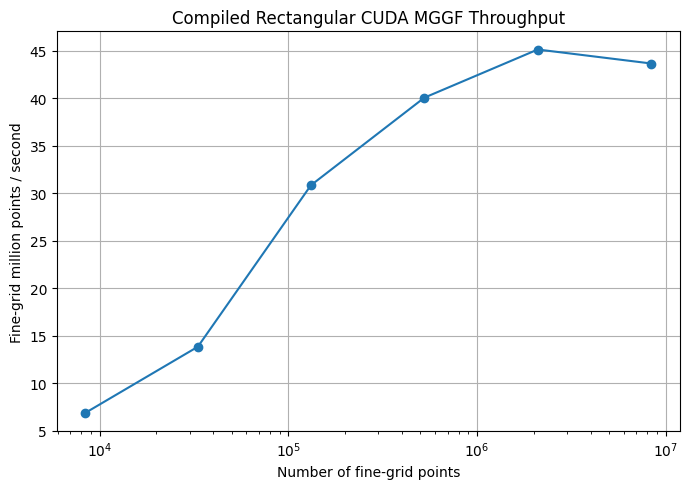

In [ ]:
# ============================================================
# Step 11: torch.compile the COMPLETE rectangular MGGF
#
# Compare:
#
#     eager complete MGGF
#         versus
#     compiled complete MGGF
#
# using the same fixed-iteration float32 formulation.
# ============================================================

import gc


# ------------------------------------------------------------
# Test grids
# ------------------------------------------------------------
MGGF_COMPILE_GRIDS = [
    (129, 65),
    (257, 129),
    (513, 257),
    (1025, 513),
    (2049, 1025),
    (4097, 2049),
]


print("\nCOMPILED COMPLETE CUDA MGGF")
print("=" * 112)

print(
    f"{'Grid':>18s}"
    f"{'Points':>14s}"
    f"{'Eager [ms]':>14s}"
    f"{'Compiled [ms]':>16s}"
    f"{'Speedup':>12s}"
    f"{'Mpts/s':>14s}"
    f"{'Rel error':>14s}"
)

print("-" * 112)


mggf_compile_results = []


for nx, ny in MGGF_COMPILE_GRIDS:

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    npoints = nx * ny

    # ========================================================
    # Build hierarchy and solver metadata
    # ========================================================
    Alev = build_gpu_hierarchy(
        nx,
        ny,
        dtype=torch.float32
    )

    solvers = prepare_mggf_solver(
        Alev,
        BETA
    )

    torch.manual_seed(
        20000 + nx
    )

    x = torch.randn(
        ny,
        nx,
        dtype=torch.float32,
        device=device
    )


    # ========================================================
    # Define complete MGGF function
    # ========================================================
    def mggf_function(xin):

        return apply_mggf_fixed_gpu(
            xin,
            solvers,
            niters=(28, 28, 25)
        )


    # ========================================================
    # Compile
    # ========================================================
    compiled_mggf = torch.compile(
        mggf_function,
        mode="reduce-overhead",
        fullgraph=False
    )


    # ========================================================
    # Eager reference
    # ========================================================
    with torch.no_grad():
        y_eager = mggf_function(x)

    torch.cuda.synchronize()


    # ========================================================
    # First compiled execution triggers compilation
    # ========================================================
    print(
        f"\nCompiling complete MGGF for "
        f"{nx} x {ny} ..."
    )

    with torch.no_grad():
        y_compiled = compiled_mggf(x)

    torch.cuda.synchronize()


    # ========================================================
    # Correctness
    # ========================================================
    rel_error = (
        torch.linalg.vector_norm(
            y_compiled - y_eager
        )
        /
        torch.linalg.vector_norm(
            y_eager
        )
    ).item()

    max_error = torch.max(
        torch.abs(
            y_compiled - y_eager
        )
    ).item()


    # ========================================================
    # Benchmark helper
    # ========================================================
    def benchmark_function(
        fn,
        nrepeat
    ):

        with torch.no_grad():
            for _ in range(5):
                _ = fn(x)

        torch.cuda.synchronize()

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        with torch.no_grad():
            for _ in range(nrepeat):
                _ = fn(x)

        end.record()

        torch.cuda.synchronize()

        return (
            start.elapsed_time(end)
            / nrepeat
        )


    # ========================================================
    # Repetition count
    # ========================================================
    if npoints < 100_000:
        nrepeat = 100

    elif npoints < 500_000:
        nrepeat = 50

    elif npoints < 3_000_000:
        nrepeat = 20

    else:
        nrepeat = 10


    # ========================================================
    # Benchmark eager and compiled
    # ========================================================
    eager_ms = benchmark_function(
        mggf_function,
        nrepeat
    )

    compiled_ms = benchmark_function(
        compiled_mggf,
        nrepeat
    )

    speedup = (
        eager_ms
        /
        compiled_ms
    )

    throughput = (
        npoints
        /
        (compiled_ms * 1.0e-3)
        /
        1.0e6
    )


    # ========================================================
    # Store results
    # ========================================================
    mggf_compile_results.append({
        "nx": nx,
        "ny": ny,
        "N": npoints,
        "eager_ms": eager_ms,
        "compiled_ms": compiled_ms,
        "speedup": speedup,
        "throughput": throughput,
        "rel_error": rel_error,
        "max_error": max_error,
    })


    print(
        f"{nx:7d} x {ny:<7d}"
        f"{npoints:14,d}"
        f"{eager_ms:14.4f}"
        f"{compiled_ms:16.4f}"
        f"{speedup:12.2f}"
        f"{throughput:14.3f}"
        f"{rel_error:14.3e}"
    )


    # ========================================================
    # Cleanup
    # ========================================================
    del x
    del Alev
    del solvers
    del y_eager
    del y_compiled
    del compiled_mggf

    gc.collect()
    torch.cuda.empty_cache()


print("\n" + "=" * 112)


# ============================================================
# Plot compiled complete-MGGF runtime
# ============================================================

Ns = np.array([
    r["N"]
    for r in mggf_compile_results
])

eager_times = np.array([
    r["eager_ms"]
    for r in mggf_compile_results
])

compiled_times = np.array([
    r["compiled_ms"]
    for r in mggf_compile_results
])


plt.figure(
    figsize=(7, 5)
)

plt.loglog(
    Ns,
    eager_times,
    marker="o",
    label="Eager"
)

plt.loglog(
    Ns,
    compiled_times,
    marker="o",
    label="torch.compile"
)

plt.xlabel(
    "Number of fine-grid points"
)

plt.ylabel(
    "Complete MGGF time [ms]"
)

plt.title(
    "Complete Rectangular CUDA MGGF"
)

plt.grid(
    True,
    which="both"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# Plot compiled throughput
# ============================================================

compiled_throughput = np.array([
    r["throughput"]
    for r in mggf_compile_results
])


plt.figure(
    figsize=(7, 5)
)

plt.semilogx(
    Ns,
    compiled_throughput,
    marker="o"
)

plt.xlabel(
    "Number of fine-grid points"
)

plt.ylabel(
    "Fine-grid million points / second"
)

plt.title(
    "Compiled Rectangular CUDA MGGF Throughput"
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()

# 12. Hybrid MGGF: Compiled Beta Solvers + Eager Transfers

In [ ]:
# ============================================================
# Step 12: Hybrid CUDA MGGF
#
# Strategy:
#
#     COMPILED:
#         B0, B1, B2 fixed-iteration PCG beta solves
#
#     EAGER:
#         restriction R
#         prolongation P
#         multigeneration combination
#
# Goal:
#   preserve torch.compile acceleration of each beta solve
#   without compiling the entire multilevel MGGF graph.
# ============================================================

import gc


# ============================================================
# Build hybrid solver
# ============================================================

def prepare_hybrid_mggf(
    A_levels,
    betas=BETA,
    niters=(28, 28, 25)
):
    """
    Prepare three level solvers and compile each beta solve
    independently.
    """

    solvers = prepare_mggf_solver(
        A_levels,
        betas
    )

    compiled_beta = []

    for ell in range(3):

        solver = solvers[ell]
        niter = niters[ell]

        # Capture level-specific solver and iteration count
        def make_level_function(
            solver_local,
            niter_local
        ):

            def level_function(x):

                return beta_filter_pcg_fixed_gpu(
                    x,
                    solver_local,
                    niter_local
                )

            return level_function

        eager_function = make_level_function(
            solver,
            niter
        )

        compiled_function = torch.compile(
            eager_function,
            mode="reduce-overhead",
            fullgraph=False
        )

        compiled_beta.append(
            compiled_function
        )

    return solvers, compiled_beta


# ============================================================
# Apply hybrid MGGF
# ============================================================

def apply_mggf_hybrid_gpu(
    x0,
    solvers,
    compiled_beta,
    weights=WEIGHTS
):
    """
    Complete MGGF:

        compiled beta filters
        +
        eager multilevel transfers.
    """

    A0 = solvers[0]["A"]
    A1 = solvers[1]["A"]
    A2 = solvers[2]["A"]

    # --------------------------------------------------------
    # Generation 0
    # --------------------------------------------------------
    g0 = compiled_beta[0](
        x0
    )

    # --------------------------------------------------------
    # Level 0 -> Level 1
    # --------------------------------------------------------
    x1 = restrict_adjoint_gpu(
        x0,
        A0,
        A1
    )

    b1 = compiled_beta[1](
        x1
    )

    g1 = prolong_bilinear_gpu(
        b1
    )

    # --------------------------------------------------------
    # Level 1 -> Level 2
    # --------------------------------------------------------
    x2 = restrict_adjoint_gpu(
        x1,
        A1,
        A2
    )

    b2 = compiled_beta[2](
        x2
    )

    g2 = prolong_bilinear_gpu(
        prolong_bilinear_gpu(
            b2
        )
    )

    # --------------------------------------------------------
    # Combine generations
    # --------------------------------------------------------
    return (
        weights[0] * g0
        +
        weights[1] * g1
        +
        weights[2] * g2
    ) / sum(weights)


# ============================================================
# Test sizes
# ============================================================

HYBRID_TEST_GRIDS = [
    (129, 65),
    (257, 129),
    (513, 257),
    (1025, 513),
    (2049, 1025),
    (4097, 2049),
]


print("\nHYBRID CUDA MGGF")
print("=" * 126)

print(
    f"{'Grid':>18s}"
    f"{'Points':>14s}"
    f"{'Eager ms':>13s}"
    f"{'Full-comp ms':>15s}"
    f"{'Hybrid ms':>13s}"
    f"{'Hybrid/Eager':>15s}"
    f"{'Mpts/s':>13s}"
    f"{'Rel error':>15s}"
)

print("-" * 126)


hybrid_results = []


# ============================================================
# Loop over grids
# ============================================================

for nx, ny in HYBRID_TEST_GRIDS:

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    npoints = nx * ny

    # --------------------------------------------------------
    # Hierarchy
    # --------------------------------------------------------
    Alev = build_gpu_hierarchy(
        nx,
        ny,
        dtype=torch.float32
    )

    solvers_eager = prepare_mggf_solver(
        Alev,
        BETA
    )

    torch.manual_seed(
        31000 + nx
    )

    x = torch.randn(
        ny,
        nx,
        dtype=torch.float32,
        device=device
    )


    # --------------------------------------------------------
    # Eager reference
    # --------------------------------------------------------
    def eager_fn():

        return apply_mggf_fixed_gpu(
            x,
            solvers_eager,
            niters=(28, 28, 25)
        )


    with torch.no_grad():
        y_ref = eager_fn()

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Prepare hybrid solver
    # --------------------------------------------------------
    print(
        f"\nPreparing hybrid solver for {nx} x {ny} ..."
    )

    solvers_hybrid, compiled_beta = prepare_hybrid_mggf(
        Alev,
        BETA,
        niters=(28, 28, 25)
    )


    def hybrid_fn():

        return apply_mggf_hybrid_gpu(
            x,
            solvers_hybrid,
            compiled_beta
        )


    # --------------------------------------------------------
    # First call = compilation
    # Do NOT benchmark
    # --------------------------------------------------------
    with torch.no_grad():
        y_hybrid = hybrid_fn()

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Numerical equivalence
    # --------------------------------------------------------
    rel_error = (
        torch.linalg.vector_norm(
            y_hybrid - y_ref
        )
        /
        torch.linalg.vector_norm(
            y_ref
        )
    ).item()


    # --------------------------------------------------------
    # Timing helper
    # --------------------------------------------------------
    def time_function(
        fn,
        nrepeat
    ):

        with torch.no_grad():

            for _ in range(5):
                _ = fn()

        torch.cuda.synchronize()

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        with torch.no_grad():

            for _ in range(nrepeat):
                _ = fn()

        end.record()

        torch.cuda.synchronize()

        return (
            start.elapsed_time(end)
            /
            nrepeat
        )


    # --------------------------------------------------------
    # Repetitions
    # --------------------------------------------------------
    if npoints < 100_000:
        nrepeat = 100

    elif npoints < 500_000:
        nrepeat = 50

    elif npoints < 3_000_000:
        nrepeat = 20

    else:
        nrepeat = 10


    # --------------------------------------------------------
    # Measure eager
    # --------------------------------------------------------
    eager_ms = time_function(
        eager_fn,
        nrepeat
    )


    # --------------------------------------------------------
    # Measure hybrid
    # --------------------------------------------------------
    hybrid_ms = time_function(
        hybrid_fn,
        nrepeat
    )


    # --------------------------------------------------------
    # Retrieve earlier full-compile result
    # --------------------------------------------------------
    full_match = [
        r
        for r in mggf_compile_results
        if r["N"] == npoints
    ]

    if len(full_match) > 0:

        full_compile_ms = (
            full_match[0]["compiled_ms"]
        )

    else:

        full_compile_ms = np.nan


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    hybrid_speedup = (
        eager_ms
        /
        hybrid_ms
    )

    throughput = (
        npoints
        /
        (hybrid_ms * 1.0e-3)
        /
        1.0e6
    )


    hybrid_results.append({
        "nx": nx,
        "ny": ny,
        "N": npoints,
        "eager_ms": eager_ms,
        "full_compile_ms": full_compile_ms,
        "hybrid_ms": hybrid_ms,
        "speedup": hybrid_speedup,
        "throughput": throughput,
        "rel_error": rel_error,
    })


    print(
        f"{nx:7d} x {ny:<7d}"
        f"{npoints:14,d}"
        f"{eager_ms:13.4f}"
        f"{full_compile_ms:15.4f}"
        f"{hybrid_ms:13.4f}"
        f"{hybrid_speedup:15.2f}"
        f"{throughput:13.3f}"
        f"{rel_error:15.3e}"
    )


    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------
    del x
    del Alev
    del solvers_eager
    del solvers_hybrid
    del compiled_beta
    del y_ref
    del y_hybrid

    gc.collect()
    torch.cuda.empty_cache()


print("\n" + "=" * 126)


# ============================================================
# Best-method summary
# ============================================================

print("\nBEST METHOD BY GRID")
print("=" * 88)

print(
    f"{'Grid':>18s}"
    f"{'Eager ms':>14s}"
    f"{'Full comp':>14s}"
    f"{'Hybrid':>14s}"
    f"{'Best':>16s}"
)

print("-" * 88)


for r in hybrid_results:

    choices = {
        "Eager": r["eager_ms"],
        "Full compile": r["full_compile_ms"],
        "Hybrid": r["hybrid_ms"],
    }

    finite_choices = {
        k: v
        for k, v in choices.items()
        if np.isfinite(v)
    }

    best_name = min(
        finite_choices,
        key=finite_choices.get
    )

    print(
        f"{r['nx']:7d} x {r['ny']:<7d}"
        f"{r['eager_ms']:14.4f}"
        f"{r['full_compile_ms']:14.4f}"
        f"{r['hybrid_ms']:14.4f}"
        f"{best_name:>16s}"
    )


print("=" * 88)


HYBRID CUDA MGGF
              Grid        Points     Eager ms   Full-comp ms    Hybrid ms   Hybrid/Eager       Mpts/s      Rel error
------------------------------------------------------------------------------------------------------------------------------

Preparing hybrid solver for 129 x 65 ...


RuntimeError: Error: accessing tensor output of CUDAGraphs that has been overwritten by a subsequent run. Stack trace: File "/tmp/ipykernel_4940/3896561357.py", line 34, in beta_function
    return beta_filter_pcg_fixed_gpu(
  File "/tmp/ipykernel_4940/4031098527.py", line 93, in beta_filter_pcg_fixed_gpu
    y = y + alpha * p. To prevent overwriting, clone the tensor outside of torch.compile() or call torch.compiler.cudagraph_mark_step_begin() before each model invocation.

# 12. Hybrid CUDA MGGF — Compiled Beta Solvers + Eager Transfers

In [ ]:
# ============================================================
# Step 12: Hybrid CUDA MGGF
#
# Strategy:
#
#   COMPILED:
#       B0, B1, B2 fixed-iteration PCG beta solves
#
#   EAGER:
#       restriction R
#       prolongation P
#       multigeneration combination
#
# Important CUDA-graph fix:
#   Each compiled beta output is cloned immediately after
#   the call. This prevents a later compiled invocation from
#   overwriting CUDA-graph-managed output memory.
# ============================================================

import gc
import numpy as np
import torch


# ============================================================
# Build hybrid solver
# ============================================================

def prepare_hybrid_mggf(
    A_levels,
    betas=BETA,
    niters=(28, 28, 25)
):
    """
    Prepare level solvers and compile each beta solve
    independently.

    Returns
    -------
    solvers : list
        Level-specific solver metadata.

    compiled_beta : list
        Three independently compiled beta-filter functions.
    """

    solvers = prepare_mggf_solver(
        A_levels,
        betas
    )

    compiled_beta = []

    for ell in range(3):

        solver = solvers[ell]
        niter = niters[ell]

        # ----------------------------------------------------
        # Capture level-specific solver safely
        # ----------------------------------------------------
        def make_level_function(
            solver_local,
            niter_local
        ):

            def level_function(x):

                return beta_filter_pcg_fixed_gpu(
                    x,
                    solver_local,
                    niter_local
                )

            return level_function

        eager_function = make_level_function(
            solver,
            niter
        )

        # ----------------------------------------------------
        # Compile only the beta solve
        # ----------------------------------------------------
        compiled_function = torch.compile(
            eager_function,
            mode="reduce-overhead",
            fullgraph=False
        )

        compiled_beta.append(
            compiled_function
        )

    return solvers, compiled_beta


# ============================================================
# Apply hybrid MGGF
# ============================================================

def apply_mggf_hybrid_gpu(
    x0,
    solvers,
    compiled_beta,
    weights=WEIGHTS
):
    """
    Hybrid complete MGGF:

        compiled beta filters
        +
        eager multilevel transfers.

    Each compiled beta output is cloned immediately so that
    subsequent CUDA-graph calls cannot overwrite it.
    """

    A0 = solvers[0]["A"]
    A1 = solvers[1]["A"]
    A2 = solvers[2]["A"]

    # ========================================================
    # Generation 0
    # ========================================================

    g0 = compiled_beta[0](
        x0
    ).clone()


    # ========================================================
    # Level 0 -> Level 1
    # ========================================================

    x1 = restrict_adjoint_gpu(
        x0,
        A0,
        A1
    )

    b1 = compiled_beta[1](
        x1
    ).clone()

    g1 = prolong_bilinear_gpu(
        b1
    )


    # ========================================================
    # Level 1 -> Level 2
    # ========================================================

    x2 = restrict_adjoint_gpu(
        x1,
        A1,
        A2
    )

    b2 = compiled_beta[2](
        x2
    ).clone()

    g2_L1 = prolong_bilinear_gpu(
        b2
    )

    g2 = prolong_bilinear_gpu(
        g2_L1
    )


    # ========================================================
    # Weighted combination
    # ========================================================

    y = (
        weights[0] * g0
        +
        weights[1] * g1
        +
        weights[2] * g2
    ) / sum(weights)

    return y


# ============================================================
# Test grids
# ============================================================

HYBRID_TEST_GRIDS = [
    (129, 65),
    (257, 129),
    (513, 257),
    (1025, 513),
    (2049, 1025),
    (4097, 2049),
]


# ============================================================
# Header
# ============================================================

print("\nHYBRID CUDA MGGF")
print("=" * 126)

print(
    f"{'Grid':>18s}"
    f"{'Points':>14s}"
    f"{'Eager ms':>13s}"
    f"{'Full-comp ms':>15s}"
    f"{'Hybrid ms':>13s}"
    f"{'Hybrid/Eager':>15s}"
    f"{'Mpts/s':>13s}"
    f"{'Rel error':>15s}"
)

print("-" * 126)


hybrid_results = []


# ============================================================
# Timing helper
# ============================================================

def time_function_cuda(
    fn,
    nrepeat,
    nwarmup=5
):
    """
    Benchmark a CUDA function with CUDA events.
    """

    with torch.no_grad():

        for _ in range(nwarmup):
            _ = fn()

    torch.cuda.synchronize()

    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )

    start.record()

    with torch.no_grad():

        for _ in range(nrepeat):
            _ = fn()

    end.record()

    torch.cuda.synchronize()

    return (
        start.elapsed_time(end)
        /
        nrepeat
    )


# ============================================================
# Main loop
# ============================================================

for nx, ny in HYBRID_TEST_GRIDS:

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    npoints = nx * ny


    # ========================================================
    # Build hierarchy
    # ========================================================

    Alev = build_gpu_hierarchy(
        nx,
        ny,
        dtype=torch.float32
    )


    # ========================================================
    # Eager solver
    # ========================================================

    solvers_eager = prepare_mggf_solver(
        Alev,
        BETA
    )


    # ========================================================
    # Test field
    # ========================================================

    torch.manual_seed(
        31000 + nx
    )

    x = torch.randn(
        ny,
        nx,
        dtype=torch.float32,
        device=device
    )


    # ========================================================
    # Eager complete MGGF
    # ========================================================

    def eager_fn():

        return apply_mggf_fixed_gpu(
            x,
            solvers_eager,
            niters=(28, 28, 25)
        )


    with torch.no_grad():

        y_ref = eager_fn()

    torch.cuda.synchronize()


    # ========================================================
    # Prepare hybrid solver
    # ========================================================

    print(
        f"\nPreparing hybrid solver for "
        f"{nx} x {ny} ..."
    )

    solvers_hybrid, compiled_beta = prepare_hybrid_mggf(
        Alev,
        BETA,
        niters=(28, 28, 25)
    )


    # ========================================================
    # Hybrid callable
    # ========================================================

    def hybrid_fn():

        return apply_mggf_hybrid_gpu(
            x,
            solvers_hybrid,
            compiled_beta
        )


    # ========================================================
    # First call triggers compilation
    #
    # Do not benchmark this call.
    # ========================================================

    with torch.no_grad():

        y_hybrid = hybrid_fn()

    torch.cuda.synchronize()


    # ========================================================
    # Numerical comparison
    # ========================================================

    rel_error = (
        torch.linalg.vector_norm(
            y_hybrid - y_ref
        )
        /
        torch.linalg.vector_norm(
            y_ref
        )
    ).item()

    max_error = torch.max(
        torch.abs(
            y_hybrid - y_ref
        )
    ).item()


    # ========================================================
    # Repetition count
    # ========================================================

    if npoints < 100_000:

        nrepeat = 100

    elif npoints < 500_000:

        nrepeat = 50

    elif npoints < 3_000_000:

        nrepeat = 20

    else:

        nrepeat = 10


    # ========================================================
    # Benchmark eager
    # ========================================================

    eager_ms = time_function_cuda(
        eager_fn,
        nrepeat
    )


    # ========================================================
    # Benchmark hybrid
    # ========================================================

    hybrid_ms = time_function_cuda(
        hybrid_fn,
        nrepeat
    )


    # ========================================================
    # Retrieve previous fully compiled result
    #
    # mggf_compile_results was created in Cell 11.
    # ========================================================

    full_match = [
        r
        for r in mggf_compile_results
        if r["N"] == npoints
    ]

    if len(full_match) > 0:

        full_compile_ms = (
            full_match[0]["compiled_ms"]
        )

    else:

        full_compile_ms = np.nan


    # ========================================================
    # Performance metrics
    # ========================================================

    hybrid_speedup = (
        eager_ms
        /
        hybrid_ms
    )

    throughput = (
        npoints
        /
        (hybrid_ms * 1.0e-3)
        /
        1.0e6
    )


    # ========================================================
    # Store results
    # ========================================================

    hybrid_results.append({
        "nx": nx,
        "ny": ny,
        "N": npoints,
        "eager_ms": eager_ms,
        "full_compile_ms": full_compile_ms,
        "hybrid_ms": hybrid_ms,
        "speedup": hybrid_speedup,
        "throughput": throughput,
        "rel_error": rel_error,
        "max_error": max_error,
    })


    # ========================================================
    # Print result
    # ========================================================

    print(
        f"{nx:7d} x {ny:<7d}"
        f"{npoints:14,d}"
        f"{eager_ms:13.4f}"
        f"{full_compile_ms:15.4f}"
        f"{hybrid_ms:13.4f}"
        f"{hybrid_speedup:15.2f}"
        f"{throughput:13.3f}"
        f"{rel_error:15.3e}"
    )


    # ========================================================
    # Cleanup
    # ========================================================

    del x
    del Alev
    del solvers_eager
    del solvers_hybrid
    del compiled_beta
    del y_ref
    del y_hybrid

    gc.collect()
    torch.cuda.empty_cache()


print("\n" + "=" * 126)


# ============================================================
# Best method by grid
# ============================================================

print("\nBEST METHOD BY GRID")
print("=" * 92)

print(
    f"{'Grid':>18s}"
    f"{'Eager ms':>14s}"
    f"{'Full compile':>16s}"
    f"{'Hybrid':>14s}"
    f"{'Best':>18s}"
)

print("-" * 92)


for r in hybrid_results:

    choices = {
        "Eager": r["eager_ms"],
        "Full compile": r["full_compile_ms"],
        "Hybrid": r["hybrid_ms"],
    }

    finite_choices = {
        key: value
        for key, value in choices.items()
        if np.isfinite(value)
    }

    best_name = min(
        finite_choices,
        key=finite_choices.get
    )

    print(
        f"{r['nx']:7d} x {r['ny']:<7d}"
        f"{r['eager_ms']:14.4f}"
        f"{r['full_compile_ms']:16.4f}"
        f"{r['hybrid_ms']:14.4f}"
        f"{best_name:>18s}"
    )


print("=" * 92)


# ============================================================
# Hybrid throughput summary
# ============================================================

print("\nHYBRID THROUGHPUT")
print("=" * 80)

print(
    f"{'Grid':>18s}"
    f"{'Points':>14s}"
    f"{'Hybrid ms':>14s}"
    f"{'Mpts/s':>14s}"
)

print("-" * 80)

for r in hybrid_results:

    print(
        f"{r['nx']:7d} x {r['ny']:<7d}"
        f"{r['N']:14,d}"
        f"{r['hybrid_ms']:14.4f}"
        f"{r['throughput']:14.3f}"
    )

print("=" * 80)


HYBRID CUDA MGGF
              Grid        Points     Eager ms   Full-comp ms    Hybrid ms   Hybrid/Eager       Mpts/s      Rel error
------------------------------------------------------------------------------------------------------------------------------

Preparing hybrid solver for 129 x 65 ...
    129 x 65              8,385      35.5406         1.2233       2.9591          12.01        2.834      1.343e-07

Preparing hybrid solver for 257 x 129 ...
    257 x 129            33,153      35.6178         2.3977       6.8059           5.23        4.871      1.402e-07

Preparing hybrid solver for 513 x 257 ...
    513 x 257           131,841      36.1985         4.2751      21.7847           1.66        6.052      1.359e-07

Preparing hybrid solver for 1025 x 513 ...
   1025 x 513           525,825      37.7464        13.1267      84.3090           0.45        6.237      1.376e-07

Preparing hybrid solver for 2049 x 1025 ...
   2049 x 1025        2,100,225      36.8909        46.53

# 13. Level-Aware GPU Regime Test: Eager vs Compiled Beta Solver


LEVEL-AWARE CUDA BETA-SOLVER REGIME TEST
        Fine grid   Gen       Level grid   Level points     Eager ms    Compiled ms    Speedup        Best      Rel error
------------------------------------------------------------------------------------------------------------------------------------

Testing hierarchy from fine grid 129 x 65
  compiling Generation 0: 129 x 65 (8,385 points) ...
   129 x 65         0   129 x 65              8,385      11.6090         2.2475       5.17    COMPILED      1.475e-07
  compiling Generation 1: 65 x 33 (2,145 points) ...
   129 x 65         1    65 x 33              2,145      11.6131         1.3161       8.82    COMPILED      1.533e-07
  compiling Generation 2: 33 x 17 (561 points) ...
   129 x 65         2    33 x 17                561      11.1000         1.1797       9.41    COMPILED      1.330e-07

Testing hierarchy from fine grid 257 x 129
  compiling Generation 0: 257 x 129 (33,153 points) ...
   257 x 129        0   257 x 129            33,

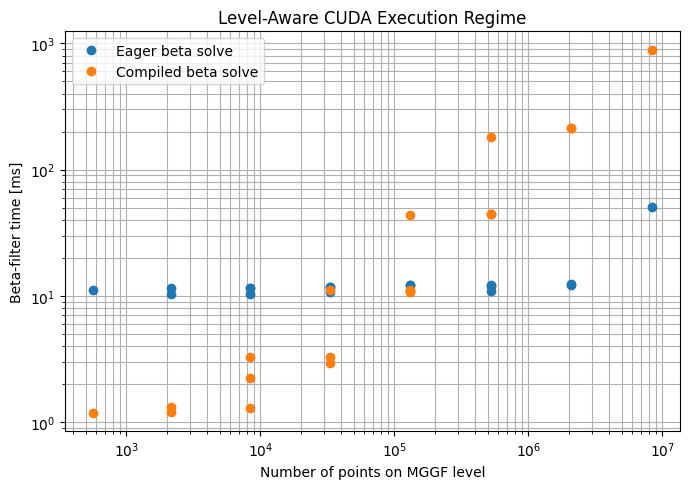

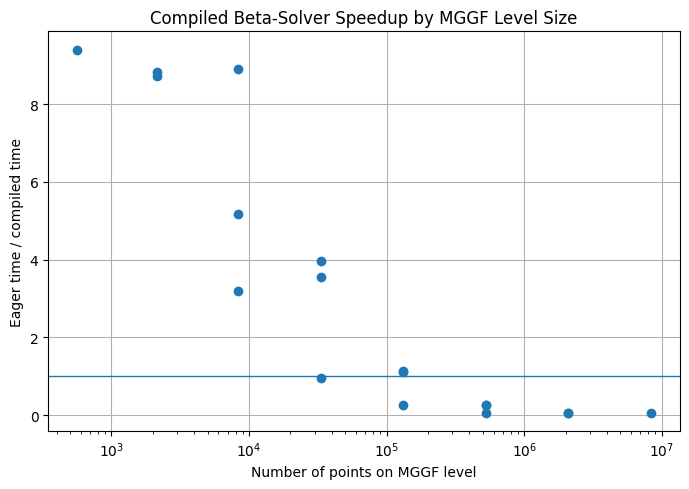

In [ ]:
# ============================================================
# Step 13: Level-aware GPU regime test
#
# Goal:
#
#   Determine independently for each MGGF generation whether
#   the beta solve is faster using:
#
#       1. eager PyTorch
#       2. torch.compile
#
#   The important quantity is the SIZE OF EACH LEVEL, not only
#   the size of the original fine grid.
#
# We deliberately avoid "reduce-overhead" CUDA graphs here,
# because individual generation outputs must remain valid while
# the multilevel MGGF proceeds to other generations.
#
# Compilation mode:
#
#       max-autotune-no-cudagraphs
#
# preserves compiler optimization while avoiding the output
# aliasing problem encountered in the previous hybrid test.
# ============================================================

import gc
import numpy as np
import torch


# ============================================================
# Configuration
# ============================================================

BETAS_LEVEL = (
    0.5,
    2.0,
    6.0
)

NITERS_LEVEL = (
    28,
    28,
    25
)


# Fine-grid sizes from which the three-generation hierarchy
# will be constructed.
#
# This gives us many different LEVEL sizes automatically.
#
LEVEL_REGIME_FINE_GRIDS = [
    (129, 65),
    (257, 129),
    (513, 257),
    (1025, 513),
    (2049, 1025),
    (4097, 2049),
]


# ============================================================
# Benchmark helper
# ============================================================

@torch.no_grad()
def benchmark_level_function(
    fn,
    x,
    nrepeat,
    nwarmup=5
):
    """
    CUDA-event timing of one beta-filter function.
    """

    # Warm-up
    for _ in range(nwarmup):
        _ = fn(x)

    torch.cuda.synchronize()

    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )

    start.record()

    for _ in range(nrepeat):
        _ = fn(x)

    end.record()

    torch.cuda.synchronize()

    return (
        start.elapsed_time(end)
        /
        nrepeat
    )


# ============================================================
# Function factory
# ============================================================

def make_beta_level_function(
    solver,
    niter
):
    """
    Create one fixed-iteration beta solver for one MGGF level.
    """

    def beta_level(x):

        return beta_filter_pcg_fixed_gpu(
            x,
            solver,
            niter
        )

    return beta_level


# ============================================================
# Storage
# ============================================================

level_regime_results = []


# ============================================================
# Header
# ============================================================

print("\nLEVEL-AWARE CUDA BETA-SOLVER REGIME TEST")
print("=" * 132)

print(
    f"{'Fine grid':>17s}"
    f"{'Gen':>6s}"
    f"{'Level grid':>17s}"
    f"{'Level points':>15s}"
    f"{'Eager ms':>13s}"
    f"{'Compiled ms':>15s}"
    f"{'Speedup':>11s}"
    f"{'Best':>12s}"
    f"{'Rel error':>15s}"
)

print("-" * 132)


# ============================================================
# Loop over fine grids
# ============================================================

for nx0, ny0 in LEVEL_REGIME_FINE_GRIDS:

    # --------------------------------------------------------
    # Clean previous objects
    # --------------------------------------------------------
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Build three-level hierarchy
    # --------------------------------------------------------
    A_levels_test = build_gpu_hierarchy(
        nx0,
        ny0,
        dtype=torch.float32
    )


    print(
        f"\nTesting hierarchy from fine grid "
        f"{nx0} x {ny0}"
    )


    # ========================================================
    # Each generation independently
    # ========================================================

    for ell in range(3):

        A = A_levels_test[ell]

        ny = A.shape[0]
        nx = A.shape[1]

        npoints = nx * ny

        beta = BETAS_LEVEL[ell]
        niter = NITERS_LEVEL[ell]


        # ----------------------------------------------------
        # Prepare solver
        # ----------------------------------------------------
        solver = prepare_level_solver(
            A,
            beta
        )


        # ----------------------------------------------------
        # Random test field
        # ----------------------------------------------------
        torch.manual_seed(
            100000
            + nx0
            + 100 * ell
        )

        x = torch.randn(
            ny,
            nx,
            dtype=torch.float32,
            device=device
        )


        # ----------------------------------------------------
        # Eager level function
        # ----------------------------------------------------
        eager_fn = make_beta_level_function(
            solver,
            niter
        )


        # ----------------------------------------------------
        # Compile WITHOUT CUDA graphs
        #
        # This is important:
        #
        # The previous hybrid experiment used
        # mode="reduce-overhead", which employed CUDA graphs.
        # Their output buffers were reused between calls.
        #
        # Here we explicitly use the compiler mode intended to
        # avoid CUDA graph capture while retaining Inductor/
        # Triton optimization.
        # ----------------------------------------------------
        try:

            compiled_fn = torch.compile(
                eager_fn,
                mode="max-autotune-no-cudagraphs",
                fullgraph=False
            )

        except Exception:

            # Conservative fallback in case the Colab/PyTorch
            # build does not expose that named mode.
            compiled_fn = torch.compile(
                eager_fn,
                mode="default",
                fullgraph=False
            )


        # ----------------------------------------------------
        # Eager reference
        # ----------------------------------------------------
        with torch.no_grad():

            y_eager = eager_fn(
                x
            )

        torch.cuda.synchronize()


        # ----------------------------------------------------
        # First compiled call
        #
        # Triggers compilation -- never include in timing.
        # ----------------------------------------------------
        print(
            f"  compiling Generation {ell}: "
            f"{nx} x {ny} "
            f"({npoints:,} points) ..."
        )

        with torch.no_grad():

            y_compiled = compiled_fn(
                x
            )

        torch.cuda.synchronize()


        # ----------------------------------------------------
        # Numerical equivalence
        # ----------------------------------------------------
        rel_error = (
            torch.linalg.vector_norm(
                y_compiled - y_eager
            )
            /
            torch.linalg.vector_norm(
                y_eager
            )
        ).item()


        max_error = torch.max(
            torch.abs(
                y_compiled - y_eager
            )
        ).item()


        # ----------------------------------------------------
        # Repetition count
        # ----------------------------------------------------
        if npoints < 20_000:

            nrepeat = 100

        elif npoints < 150_000:

            nrepeat = 50

        elif npoints < 1_000_000:

            nrepeat = 30

        elif npoints < 4_000_000:

            nrepeat = 15

        else:

            nrepeat = 8


        # ----------------------------------------------------
        # Eager benchmark
        # ----------------------------------------------------
        eager_ms = benchmark_level_function(
            eager_fn,
            x,
            nrepeat=nrepeat,
            nwarmup=5
        )


        # ----------------------------------------------------
        # Compiled benchmark
        # ----------------------------------------------------
        compiled_ms = benchmark_level_function(
            compiled_fn,
            x,
            nrepeat=nrepeat,
            nwarmup=5
        )


        # ----------------------------------------------------
        # Speedup
        # ----------------------------------------------------
        speedup = (
            eager_ms
            /
            compiled_ms
        )


        # ----------------------------------------------------
        # Determine preferred regime
        # ----------------------------------------------------
        if compiled_ms < eager_ms:

            best = "COMPILED"

        else:

            best = "EAGER"


        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------
        level_regime_results.append({
            "fine_nx": nx0,
            "fine_ny": ny0,
            "generation": ell,
            "nx": nx,
            "ny": ny,
            "N": npoints,
            "beta": beta,
            "niter": niter,
            "eager_ms": eager_ms,
            "compiled_ms": compiled_ms,
            "speedup": speedup,
            "best": best,
            "rel_error": rel_error,
            "max_error": max_error,
        })


        # ----------------------------------------------------
        # Print result
        # ----------------------------------------------------
        print(
            f"{nx0:6d} x {ny0:<6d}"
            f"{ell:6d}"
            f"{nx:6d} x {ny:<6d}"
            f"{npoints:15,d}"
            f"{eager_ms:13.4f}"
            f"{compiled_ms:15.4f}"
            f"{speedup:11.2f}"
            f"{best:>12s}"
            f"{rel_error:15.3e}"
        )


        # ----------------------------------------------------
        # Cleanup this level
        # ----------------------------------------------------
        del x
        del solver
        del eager_fn
        del compiled_fn
        del y_eager
        del y_compiled

        gc.collect()
        torch.cuda.empty_cache()


    # --------------------------------------------------------
    # Cleanup hierarchy
    # --------------------------------------------------------
    del A_levels_test

    gc.collect()
    torch.cuda.empty_cache()


print("\n" + "=" * 132)


# ============================================================
# Sort all measurements purely by LEVEL size
#
# This is the important view for determining N_switch.
# ============================================================

sorted_results = sorted(
    level_regime_results,
    key=lambda r: r["N"]
)


print("\nREGIME AS A FUNCTION OF LEVEL SIZE")
print("=" * 104)

print(
    f"{'Level points':>15s}"
    f"{'Grid':>17s}"
    f"{'Generation':>12s}"
    f"{'Eager ms':>13s}"
    f"{'Compiled ms':>15s}"
    f"{'Speedup':>12s}"
    f"{'Best':>13s}"
)

print("-" * 104)


for r in sorted_results:

    print(
        f"{r['N']:15,d}"
        f"{r['nx']:6d} x {r['ny']:<6d}"
        f"{r['generation']:12d}"
        f"{r['eager_ms']:13.4f}"
        f"{r['compiled_ms']:15.4f}"
        f"{r['speedup']:12.2f}"
        f"{r['best']:>13s}"
    )


print("=" * 104)


# ============================================================
# Estimate crossover size
# ============================================================

compiled_sizes = [
    r["N"]
    for r in sorted_results
    if r["best"] == "COMPILED"
]

eager_sizes = [
    r["N"]
    for r in sorted_results
    if r["best"] == "EAGER"
]


print("\nESTIMATED LEVEL-SIZE REGIME")
print("=" * 76)


if (
    len(compiled_sizes) > 0
    and
    len(eager_sizes) > 0
):

    largest_compiled = max(
        n
        for n in compiled_sizes
        if n < min(eager_sizes)
    ) if any(
        n < min(eager_sizes)
        for n in compiled_sizes
    ) else max(compiled_sizes)

    smallest_eager = min(
        eager_sizes
    )

    N_switch_est = np.sqrt(
        largest_compiled
        *
        smallest_eager
    )

    print(
        f"Largest measured compiled-preferred level : "
        f"{largest_compiled:,}"
    )

    print(
        f"Smallest measured eager-preferred level    : "
        f"{smallest_eager:,}"
    )

    print(
        f"Approximate crossover N_switch             : "
        f"{N_switch_est:,.0f}"
    )

else:

    N_switch_est = None

    if len(eager_sizes) == 0:

        print(
            "Compiled execution was faster at every "
            "tested level size."
        )

        print(
            "The crossover lies ABOVE the tested range."
        )

    elif len(compiled_sizes) == 0:

        print(
            "Eager execution was faster at every "
            "tested level size."
        )

        print(
            "The crossover lies BELOW the tested range."
        )


print("=" * 76)


# ============================================================
# Generation-by-generation recommendation for each hierarchy
# ============================================================

print("\nRECOMMENDED EXECUTION REGIME BY GENERATION")
print("=" * 92)

print(
    f"{'Fine grid':>18s}"
    f"{'Generation 0':>18s}"
    f"{'Generation 1':>18s}"
    f"{'Generation 2':>18s}"
)

print("-" * 92)


for nx0, ny0 in LEVEL_REGIME_FINE_GRIDS:

    subset = [
        r
        for r in level_regime_results
        if (
            r["fine_nx"] == nx0
            and
            r["fine_ny"] == ny0
        )
    ]

    subset = sorted(
        subset,
        key=lambda r: r["generation"]
    )

    recommendations = []

    for r in subset:

        recommendations.append(
            f"{r['best']} ({r['N']:,})"
        )

    print(
        f"{nx0:7d} x {ny0:<7d}"
        f"{recommendations[0]:>18s}"
        f"{recommendations[1]:>18s}"
        f"{recommendations[2]:>18s}"
    )


print("=" * 92)


# ============================================================
# Optional plot: eager versus compiled by LEVEL size
# ============================================================

Ns = np.array([
    r["N"]
    for r in sorted_results
])

eager_times = np.array([
    r["eager_ms"]
    for r in sorted_results
])

compiled_times = np.array([
    r["compiled_ms"]
    for r in sorted_results
])


plt.figure(
    figsize=(7, 5)
)

plt.loglog(
    Ns,
    eager_times,
    "o",
    label="Eager beta solve"
)

plt.loglog(
    Ns,
    compiled_times,
    "o",
    label="Compiled beta solve"
)

plt.xlabel(
    "Number of points on MGGF level"
)

plt.ylabel(
    "Beta-filter time [ms]"
)

plt.title(
    "Level-Aware CUDA Execution Regime"
)

plt.grid(
    True,
    which="both"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# Plot speedup
# ============================================================

speedups = np.array([
    r["speedup"]
    for r in sorted_results
])


plt.figure(
    figsize=(7, 5)
)

plt.semilogx(
    Ns,
    speedups,
    "o"
)

plt.axhline(
    1.0,
    linewidth=1.0
)

plt.xlabel(
    "Number of points on MGGF level"
)

plt.ylabel(
    "Eager time / compiled time"
)

plt.title(
    "Compiled Beta-Solver Speedup by MGGF Level Size"
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()

# 14. Complete Level-Aware MGGF Policy Benchmark


COMPLETE LEVEL-AWARE MGGF POLICY BENCHMARK
              Grid        Points    Policy     Time [ms]        Mpts/s      vs EEE      Rel error
--------------------------------------------------------------------------------------------------------------------------

Preparing hierarchy 129 x 65 (8,385 fine points)
  compiling B0, B1, B2 ...
    129 x 65              8,385       CCC        5.7336         1.462        6.19      1.339e-07
    129 x 65              8,385       ECC       16.6132         0.505        2.14      3.992e-08
    129 x 65              8,385       ECE       25.6927         0.326        1.38      3.669e-08
    129 x 65              8,385       EEC       26.9065         0.312        1.32      1.629e-08
    129 x 65              8,385       CCE       15.0360         0.558        2.36      1.333e-07
    129 x 65              8,385       CEE       25.3109         0.331        1.40      1.293e-07
    129 x 65              8,385       EEE       35.4737         0.236       

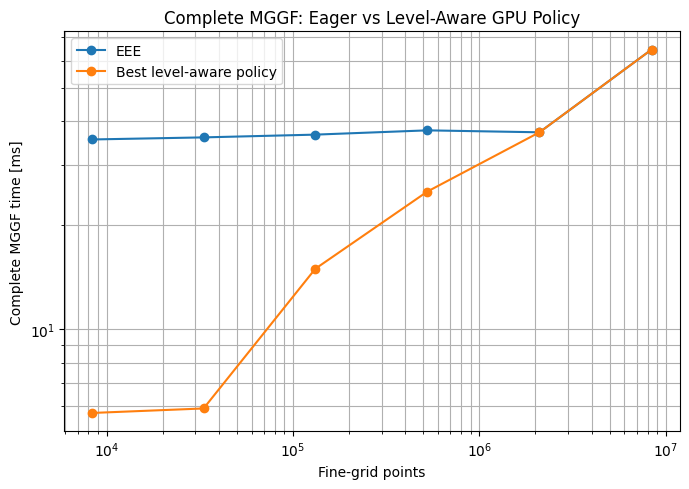

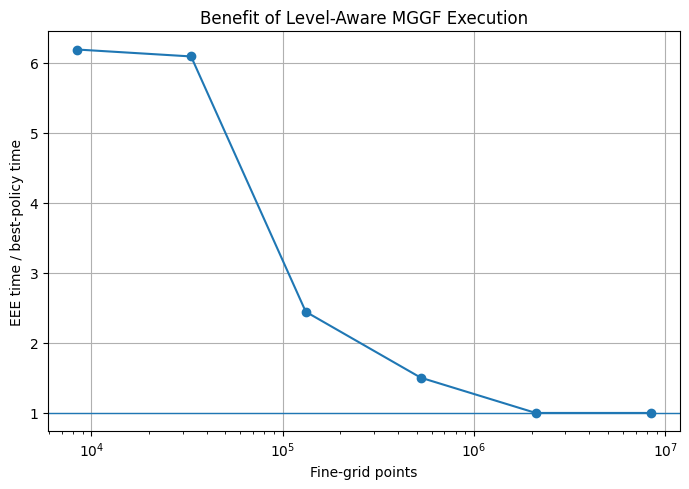

In [ ]:
# ============================================================
# Step 14: Complete level-aware MGGF policy benchmark
#
# Goal:
#
#   Benchmark complete three-generation MGGF execution using
#   different eager/compiled policies for B0, B1, B2.
#
#   We benchmark the COMPLETE filter:
#
#       beta solves
#       restriction
#       prolongation
#       weighted multigeneration assembly
#
#   rather than inferring performance from isolated beta-solver
#   timings.
#
# Important:
#
#   - Compiled beta solvers use compilation WITHOUT CUDA graphs.
#   - This avoids the graph-output aliasing/cloning problem.
#   - Eager and compiled beta solvers may therefore coexist
#     safely within one complete MGGF application.
#
# Policies tested:
#
#   CCC = compiled B0, compiled B1, compiled B2
#   ECC = eager    B0, compiled B1, compiled B2
#   ECE = eager    B0, compiled B1, eager    B2
#   EEC = eager    B0, eager    B1, compiled B2
#   CCE = compiled B0, compiled B1, eager    B2
#   CEE = compiled B0, eager    B1, eager    B2
#   EEE = eager    B0, eager    B1, eager    B2
#
# We omit CEC only because the previous level tests make it
# unlikely to be optimal, but it can easily be added later.
# ============================================================

import gc
import numpy as np
import torch


# ============================================================
# Configuration
# ============================================================

POLICY_TEST_GRIDS = [
    (129, 65),
    (257, 129),
    (513, 257),
    (1025, 513),
    (2049, 1025),
    (4097, 2049),
]

BETAS_POLICY = (
    0.5,
    2.0,
    6.0
)

NITERS_POLICY = (
    28,
    28,
    25
)

POLICIES = {
    "CCC": ("C", "C", "C"),
    "ECC": ("E", "C", "C"),
    "ECE": ("E", "C", "E"),
    "EEC": ("E", "E", "C"),
    "CCE": ("C", "C", "E"),
    "CEE": ("C", "E", "E"),
    "EEE": ("E", "E", "E"),
}


# ============================================================
# Make beta solver function
# ============================================================

def make_policy_beta_function(
    solver,
    niter
):
    """
    Create fixed-iteration beta solve for one level.
    """

    def beta_function(x):

        return beta_filter_pcg_fixed_gpu(
            x,
            solver,
            niter
        )

    return beta_function


# ============================================================
# Compile one beta solver WITHOUT CUDA graphs
# ============================================================

def compile_beta_no_cudagraph(
    eager_function
):
    """
    Compile beta filter while avoiding CUDA graph capture.
    """

    try:

        return torch.compile(
            eager_function,
            mode="max-autotune-no-cudagraphs",
            fullgraph=False
        )

    except Exception:

        return torch.compile(
            eager_function,
            mode="default",
            fullgraph=False
        )


# ============================================================
# Prepare eager + compiled beta functions for all levels
# ============================================================

def prepare_policy_functions(
    A_levels,
    betas=BETAS_POLICY,
    niters=NITERS_POLICY
):
    """
    Build level solvers and both execution variants for B0/B1/B2.
    """

    solvers = []

    eager_beta = []
    compiled_beta = []

    for ell in range(3):

        solver = prepare_level_solver(
            A_levels[ell],
            betas[ell]
        )

        eager_fn = make_policy_beta_function(
            solver,
            niters[ell]
        )

        compiled_fn = compile_beta_no_cudagraph(
            eager_fn
        )

        solvers.append(
            solver
        )

        eager_beta.append(
            eager_fn
        )

        compiled_beta.append(
            compiled_fn
        )

    return (
        solvers,
        eager_beta,
        compiled_beta
    )


# ============================================================
# Select execution mode for one generation
# ============================================================

def call_beta_policy(
    x,
    ell,
    mode,
    eager_beta,
    compiled_beta
):
    """
    mode:
        'E' = eager
        'C' = compiled
    """

    if mode == "C":

        return compiled_beta[ell](
            x
        )

    return eager_beta[ell](
        x
    )


# ============================================================
# Complete MGGF with arbitrary generation policy
# ============================================================

def apply_mggf_policy_gpu(
    x0,
    A_levels,
    eager_beta,
    compiled_beta,
    policy,
    weights=WEIGHTS
):
    """
    Complete three-generation MGGF using an execution policy
    such as ('E','C','E').
    """

    A0 = A_levels[0]
    A1 = A_levels[1]
    A2 = A_levels[2]

    # ========================================================
    # Generation 0
    # ========================================================

    g0 = call_beta_policy(
        x0,
        0,
        policy[0],
        eager_beta,
        compiled_beta
    )


    # ========================================================
    # Generation 1
    # ========================================================

    x1 = restrict_adjoint_gpu(
        x0,
        A0,
        A1
    )

    b1 = call_beta_policy(
        x1,
        1,
        policy[1],
        eager_beta,
        compiled_beta
    )

    g1 = prolong_bilinear_gpu(
        b1
    )


    # ========================================================
    # Generation 2
    # ========================================================

    x2 = restrict_adjoint_gpu(
        x1,
        A1,
        A2
    )

    b2 = call_beta_policy(
        x2,
        2,
        policy[2],
        eager_beta,
        compiled_beta
    )

    g2_L1 = prolong_bilinear_gpu(
        b2
    )

    g2 = prolong_bilinear_gpu(
        g2_L1
    )


    # ========================================================
    # Weighted sum
    # ========================================================

    return (
        weights[0] * g0
        +
        weights[1] * g1
        +
        weights[2] * g2
    ) / sum(weights)


# ============================================================
# CUDA timing helper
# ============================================================

@torch.no_grad()
def time_cuda_policy(
    fn,
    nrepeat,
    nwarmup=5
):
    """
    CUDA-event timing.
    """

    for _ in range(nwarmup):

        _ = fn()

    torch.cuda.synchronize()

    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )

    start.record()

    for _ in range(nrepeat):

        _ = fn()

    end.record()

    torch.cuda.synchronize()

    return (
        start.elapsed_time(end)
        /
        nrepeat
    )


# ============================================================
# Storage
# ============================================================

policy_results = []


# ============================================================
# Header
# ============================================================

print("\nCOMPLETE LEVEL-AWARE MGGF POLICY BENCHMARK")
print("=" * 122)

print(
    f"{'Grid':>18s}"
    f"{'Points':>14s}"
    f"{'Policy':>10s}"
    f"{'Time [ms]':>14s}"
    f"{'Mpts/s':>14s}"
    f"{'vs EEE':>12s}"
    f"{'Rel error':>15s}"
)

print("-" * 122)


# ============================================================
# Main hierarchy loop
# ============================================================

for nx0, ny0 in POLICY_TEST_GRIDS:

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    N0 = nx0 * ny0

    print(
        f"\nPreparing hierarchy {nx0} x {ny0} "
        f"({N0:,} fine points)"
    )


    # ========================================================
    # Build hierarchy
    # ========================================================

    A_levels = build_gpu_hierarchy(
        nx0,
        ny0,
        dtype=torch.float32
    )


    # ========================================================
    # Prepare all beta variants
    # ========================================================

    (
        solvers,
        eager_beta,
        compiled_beta
    ) = prepare_policy_functions(
        A_levels
    )


    # ========================================================
    # Input field
    # ========================================================

    torch.manual_seed(
        42000 + nx0
    )

    x = torch.randn(
        ny0,
        nx0,
        dtype=torch.float32,
        device=device
    )


    # ========================================================
    # Trigger compilation for all three compiled beta solvers
    # before timing any complete policy.
    # ========================================================

    print("  compiling B0, B1, B2 ...")

    with torch.no_grad():

        _ = compiled_beta[0](
            x
        )

        x1_compile = restrict_adjoint_gpu(
            x,
            A_levels[0],
            A_levels[1]
        )

        _ = compiled_beta[1](
            x1_compile
        )

        x2_compile = restrict_adjoint_gpu(
            x1_compile,
            A_levels[1],
            A_levels[2]
        )

        _ = compiled_beta[2](
            x2_compile
        )

    torch.cuda.synchronize()


    # ========================================================
    # EEE reference
    # ========================================================

    def eee_fn():

        return apply_mggf_policy_gpu(
            x,
            A_levels,
            eager_beta,
            compiled_beta,
            POLICIES["EEE"]
        )


    with torch.no_grad():

        y_ref = eee_fn()

    torch.cuda.synchronize()


    # ========================================================
    # Choose repeat count
    # ========================================================

    if N0 < 50_000:

        nrepeat = 100

    elif N0 < 250_000:

        nrepeat = 50

    elif N0 < 1_000_000:

        nrepeat = 25

    elif N0 < 4_000_000:

        nrepeat = 15

    else:

        nrepeat = 8


    # ========================================================
    # First benchmark EEE separately
    # ========================================================

    eee_ms = time_cuda_policy(
        eee_fn,
        nrepeat=nrepeat,
        nwarmup=5
    )


    # ========================================================
    # Test each policy
    # ========================================================

    for policy_name, policy_tuple in POLICIES.items():

        def policy_fn(
            policy_tuple_local=policy_tuple
        ):

            return apply_mggf_policy_gpu(
                x,
                A_levels,
                eager_beta,
                compiled_beta,
                policy_tuple_local
            )


        # ----------------------------------------------------
        # Numerical comparison
        # ----------------------------------------------------

        with torch.no_grad():

            y = policy_fn()

        torch.cuda.synchronize()

        rel_error = (
            torch.linalg.vector_norm(
                y - y_ref
            )
            /
            torch.linalg.vector_norm(
                y_ref
            )
        ).item()

        max_error = torch.max(
            torch.abs(
                y - y_ref
            )
        ).item()


        # ----------------------------------------------------
        # Timing
        # ----------------------------------------------------

        if policy_name == "EEE":

            elapsed_ms = eee_ms

        else:

            elapsed_ms = time_cuda_policy(
                policy_fn,
                nrepeat=nrepeat,
                nwarmup=5
            )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        throughput = (
            N0
            /
            (elapsed_ms * 1.0e-3)
            /
            1.0e6
        )

        speed_vs_eee = (
            eee_ms
            /
            elapsed_ms
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        policy_results.append({
            "nx": nx0,
            "ny": ny0,
            "N": N0,
            "policy": policy_name,
            "time_ms": elapsed_ms,
            "throughput": throughput,
            "speed_vs_eee": speed_vs_eee,
            "rel_error": rel_error,
            "max_error": max_error,
        })


        # ----------------------------------------------------
        # Print
        # ----------------------------------------------------

        print(
            f"{nx0:7d} x {ny0:<7d}"
            f"{N0:14,d}"
            f"{policy_name:>10s}"
            f"{elapsed_ms:14.4f}"
            f"{throughput:14.3f}"
            f"{speed_vs_eee:12.2f}"
            f"{rel_error:15.3e}"
        )


    # ========================================================
    # Cleanup
    # ========================================================

    del x
    del y
    del y_ref
    del x1_compile
    del x2_compile
    del A_levels
    del solvers
    del eager_beta
    del compiled_beta

    gc.collect()
    torch.cuda.empty_cache()


print("\n" + "=" * 122)


# ============================================================
# Best policy by grid
# ============================================================

print("\nBEST COMPLETE MGGF POLICY BY GRID")
print("=" * 96)

print(
    f"{'Grid':>18s}"
    f"{'Points':>14s}"
    f"{'Best policy':>15s}"
    f"{'Best ms':>14s}"
    f"{'EEE ms':>14s}"
    f"{'Speedup':>12s}"
    f"{'Mpts/s':>13s}"
)

print("-" * 96)


best_policy_by_grid = []


for nx0, ny0 in POLICY_TEST_GRIDS:

    subset = [
        r
        for r in policy_results
        if (
            r["nx"] == nx0
            and
            r["ny"] == ny0
        )
    ]

    best = min(
        subset,
        key=lambda r: r["time_ms"]
    )

    eee = [
        r
        for r in subset
        if r["policy"] == "EEE"
    ][0]

    best_policy_by_grid.append(
        best
    )

    print(
        f"{nx0:7d} x {ny0:<7d}"
        f"{best['N']:14,d}"
        f"{best['policy']:>15s}"
        f"{best['time_ms']:14.4f}"
        f"{eee['time_ms']:14.4f}"
        f"{eee['time_ms']/best['time_ms']:12.2f}"
        f"{best['throughput']:13.3f}"
    )


print("=" * 96)


# ============================================================
# Full policy table
# ============================================================

print("\nPOLICY MATRIX")
print("=" * 120)

policy_order = list(
    POLICIES.keys()
)

header = (
    f"{'Grid':>18s}"
    +
    "".join(
        f"{p + ' [ms]':>14s}"
        for p in policy_order
    )
    +
    f"{'Best':>10s}"
)

print(header)
print("-" * 120)


for nx0, ny0 in POLICY_TEST_GRIDS:

    subset = {
        r["policy"]: r
        for r in policy_results
        if (
            r["nx"] == nx0
            and
            r["ny"] == ny0
        )
    }

    best_name = min(
        subset,
        key=lambda p: subset[p]["time_ms"]
    )

    row = (
        f"{nx0:7d} x {ny0:<7d}"
    )

    for p in policy_order:

        row += (
            f"{subset[p]['time_ms']:14.4f}"
        )

    row += (
        f"{best_name:>10s}"
    )

    print(row)


print("=" * 120)


# ============================================================
# Plot best-policy timing
# ============================================================

Ns_best = np.array([
    r["N"]
    for r in best_policy_by_grid
])

T_best = np.array([
    r["time_ms"]
    for r in best_policy_by_grid
])

T_eee = np.array([
    [
        q["time_ms"]
        for q in policy_results
        if (
            q["N"] == r["N"]
            and
            q["policy"] == "EEE"
        )
    ][0]
    for r in best_policy_by_grid
])


plt.figure(
    figsize=(7, 5)
)

plt.loglog(
    Ns_best,
    T_eee,
    "o-",
    label="EEE"
)

plt.loglog(
    Ns_best,
    T_best,
    "o-",
    label="Best level-aware policy"
)

plt.xlabel(
    "Fine-grid points"
)

plt.ylabel(
    "Complete MGGF time [ms]"
)

plt.title(
    "Complete MGGF: Eager vs Level-Aware GPU Policy"
)

plt.grid(
    True,
    which="both"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# Plot speedup of best policy over EEE
# ============================================================

best_speedups = (
    T_eee
    /
    T_best
)


plt.figure(
    figsize=(7, 5)
)

plt.semilogx(
    Ns_best,
    best_speedups,
    "o-"
)

plt.axhline(
    1.0,
    linewidth=1.0
)

plt.xlabel(
    "Fine-grid points"
)

plt.ylabel(
    "EEE time / best-policy time"
)

plt.title(
    "Benefit of Level-Aware MGGF Execution"
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()

# 15. Production MGGF GPU Dispatcher: Automatic CCC / CCE / ECC / EEE Selection

In [ ]:
# ============================================================
# Step 15: Production MGGF GPU Dispatcher
#
# Purpose:
#
#   Provide a single production-style interface for the
#   rectangular three-generation GPU MGGF.
#
# Execution policy is selected automatically from the
#   fine-grid size using the measured best regimes:
#
#       small grids          -> CCC
#       intermediate-small   -> CCE
#       intermediate-large   -> ECC
#       large grids          -> EEE
#
# where:
#
#       C = compiled beta solver
#       E = eager beta solver
#
# This is the baseline production architecture.
#
# Domain decomposition / halo tiling should be considered later
# as a separate optimization branch, so that this validated
# implementation remains unchanged.
# ============================================================

import gc
import time
import numpy as np
import torch


# ============================================================
# Production configuration
# ============================================================

PROD_BETAS = (
    0.5,
    2.0,
    6.0
)

PROD_NITERS = (
    28,
    28,
    25
)

PROD_WEIGHTS = (
    1.0,
    0.5,
    0.25
)


# ============================================================
# Empirical execution-policy thresholds
#
# Derived from the complete-filter benchmarks:
#
#   129x65        -> CCC
#   257x129       -> CCC
#   513x257       -> CCE
#   1025x513      -> ECC
#   2049x1025     -> EEE
#   4097x2049     -> EEE
#
# We use midpoint-like thresholds between measured regimes.
#
# These can later be retuned if needed.
# ============================================================

POLICY_THRESHOLD_1 = 70_000
POLICY_THRESHOLD_2 = 300_000
POLICY_THRESHOLD_3 = 1_200_000


# ============================================================
# Policy selector
# ============================================================

def select_mggf_policy(nx, ny):
    """
    Select production execution policy from fine-grid size.

    Returns
    -------
    policy_name : str
        One of:
            CCC
            CCE
            ECC
            EEE

    policy_tuple : tuple[str, str, str]
        Per-generation execution modes.
    """

    N = nx * ny

    if N < POLICY_THRESHOLD_1:

        policy_name = "CCC"
        policy = ("C", "C", "C")

    elif N < POLICY_THRESHOLD_2:

        policy_name = "CCE"
        policy = ("C", "C", "E")

    elif N < POLICY_THRESHOLD_3:

        policy_name = "ECC"
        policy = ("E", "C", "C")

    else:

        policy_name = "EEE"
        policy = ("E", "E", "E")

    return policy_name, policy


# ============================================================
# Beta-function factory
# ============================================================

def make_prod_beta_function(
    solver,
    niter
):
    """
    Fixed-iteration PCG beta solver for one MGGF generation.
    """

    def beta_function(x):

        return beta_filter_pcg_fixed_gpu(
            x,
            solver,
            niter
        )

    return beta_function


# ============================================================
# Compiler wrapper
#
# We explicitly avoid CUDA graphs here.
#
# This allows eager and compiled generations to coexist
# safely in the same MGGF application without output cloning.
# ============================================================

def compile_prod_beta_function(
    eager_function
):
    """
    Compile one beta solver without CUDA-graph capture.
    """

    try:

        compiled_function = torch.compile(
            eager_function,
            mode="max-autotune-no-cudagraphs",
            fullgraph=False
        )

    except Exception:

        compiled_function = torch.compile(
            eager_function,
            mode="default",
            fullgraph=False
        )

    return compiled_function


# ============================================================
# Production MGGF class
# ============================================================

class ProductionMGGF:
    """
    Production three-generation rectangular GPU MGGF.

    Typical usage
    -------------

        mggf = ProductionMGGF(nx, ny)

        y = mggf.apply(x)

    The execution policy is selected automatically.
    """

    def __init__(
        self,
        nx,
        ny,
        dtype=torch.float32,
        device=device,
        betas=PROD_BETAS,
        niters=PROD_NITERS,
        weights=PROD_WEIGHTS,
        verbose=True
    ):

        self.nx = int(nx)
        self.ny = int(ny)

        self.N = (
            self.nx
            *
            self.ny
        )

        self.dtype = dtype
        self.device = device

        self.betas = tuple(
            betas
        )

        self.niters = tuple(
            niters
        )

        self.weights = tuple(
            weights
        )

        self.weight_sum = float(
            sum(
                self.weights
            )
        )


        # ====================================================
        # Select execution policy
        # ====================================================

        (
            self.policy_name,
            self.policy
        ) = select_mggf_policy(
            self.nx,
            self.ny
        )


        if verbose:

            print(
                "\nPRODUCTION MGGF INITIALIZATION"
            )

            print(
                "=" * 72
            )

            print(
                f"Fine grid            : "
                f"{self.nx} x {self.ny}"
            )

            print(
                f"Fine-grid points     : "
                f"{self.N:,}"
            )

            print(
                f"Precision            : "
                f"{self.dtype}"
            )

            print(
                f"Selected policy      : "
                f"{self.policy_name}"
            )

            print(
                f"Generation modes     : "
                f"B0={self.policy[0]}, "
                f"B1={self.policy[1]}, "
                f"B2={self.policy[2]}"
            )


        # ====================================================
        # Build hierarchy
        # ====================================================

        self.A_levels = build_gpu_hierarchy(
            self.nx,
            self.ny,
            dtype=self.dtype
        )


        if verbose:

            print("\nHierarchy:")

            for ell in range(3):

                A = self.A_levels[ell]

                nyl = A.shape[-2]
                nxl = A.shape[-1]

                print(
                    f"  L{ell}: "
                    f"{nxl} x {nyl} "
                    f"({nxl * nyl:,} points)"
                )


        # ====================================================
        # Prepare beta solvers
        # ====================================================

        self.solvers = []

        self.eager_beta = [
            None,
            None,
            None
        ]

        self.compiled_beta = [
            None,
            None,
            None
        ]


        for ell in range(3):

            solver = prepare_level_solver(
                self.A_levels[ell],
                self.betas[ell]
            )

            eager_fn = make_prod_beta_function(
                solver,
                self.niters[ell]
            )

            self.solvers.append(
                solver
            )

            self.eager_beta[ell] = (
                eager_fn
            )


            # ------------------------------------------------
            # Compile only if this generation needs it
            # ------------------------------------------------

            if self.policy[ell] == "C":

                if verbose:

                    print(
                        f"\nCompiling B{ell} ..."
                    )

                compiled_fn = (
                    compile_prod_beta_function(
                        eager_fn
                    )
                )

                self.compiled_beta[ell] = (
                    compiled_fn
                )


        # ====================================================
        # Trigger compilation now
        #
        # This keeps first production application from paying
        # compilation cost.
        # ====================================================

        self._warm_compile(
            verbose=verbose
        )


        if verbose:

            print(
                "\nProduction MGGF ready."
            )

            print(
                "=" * 72
            )


    # ========================================================
    # Call correct beta implementation
    # ========================================================

    def _beta(
        self,
        x,
        ell
    ):

        if self.policy[ell] == "C":

            return self.compiled_beta[ell](
                x
            )

        return self.eager_beta[ell](
            x
        )


    # ========================================================
    # Warm compilation
    # ========================================================

    @torch.no_grad()
    def _warm_compile(
        self,
        verbose=False
    ):

        """
        Trigger compilation of required beta solvers.
        """

        if "C" not in self.policy:

            if verbose:

                print(
                    "\nNo compiled generations required."
                )

            return


        x0 = torch.zeros(
            self.ny,
            self.nx,
            dtype=self.dtype,
            device=self.device
        )


        # ----------------------------------------------------
        # B0
        # ----------------------------------------------------

        if self.policy[0] == "C":

            _ = self.compiled_beta[0](
                x0
            )


        # ----------------------------------------------------
        # Build x1
        # ----------------------------------------------------

        x1 = restrict_adjoint_gpu(
            x0,
            self.A_levels[0],
            self.A_levels[1]
        )


        if self.policy[1] == "C":

            _ = self.compiled_beta[1](
                x1
            )


        # ----------------------------------------------------
        # Build x2
        # ----------------------------------------------------

        x2 = restrict_adjoint_gpu(
            x1,
            self.A_levels[1],
            self.A_levels[2]
        )


        if self.policy[2] == "C":

            _ = self.compiled_beta[2](
                x2
            )


        torch.cuda.synchronize()


        del x0
        del x1
        del x2


    # ========================================================
    # Complete production MGGF
    # ========================================================

    @torch.no_grad()
    def apply(
        self,
        x0
    ):
        """
        Apply complete three-generation MGGF.

        Parameters
        ----------
        x0 : torch.Tensor
            Shape:
                (..., ny, nx)

        Returns
        -------
        y : torch.Tensor
            Same shape as x0.
        """

        # ----------------------------------------------------
        # Basic shape validation
        # ----------------------------------------------------

        if (
            x0.shape[-2] != self.ny
            or
            x0.shape[-1] != self.nx
        ):

            raise ValueError(
                "Input grid does not match "
                "ProductionMGGF hierarchy.\n"
                f"Expected (..., {self.ny}, {self.nx}), "
                f"received {tuple(x0.shape)}"
            )


        # ====================================================
        # Generation 0
        # ====================================================

        g0 = self._beta(
            x0,
            0
        )


        # ====================================================
        # Restriction L0 -> L1
        # ====================================================

        x1 = restrict_adjoint_gpu(
            x0,
            self.A_levels[0],
            self.A_levels[1]
        )


        # ====================================================
        # Generation 1
        # ====================================================

        b1 = self._beta(
            x1,
            1
        )

        g1 = prolong_bilinear_gpu(
            b1
        )


        # ====================================================
        # Restriction L1 -> L2
        # ====================================================

        x2 = restrict_adjoint_gpu(
            x1,
            self.A_levels[1],
            self.A_levels[2]
        )


        # ====================================================
        # Generation 2
        # ====================================================

        b2 = self._beta(
            x2,
            2
        )

        g2_L1 = prolong_bilinear_gpu(
            b2
        )

        g2 = prolong_bilinear_gpu(
            g2_L1
        )


        # ====================================================
        # Weighted assembly
        # ====================================================

        y = (
            self.weights[0] * g0
            +
            self.weights[1] * g1
            +
            self.weights[2] * g2
        ) / self.weight_sum


        return y


    # ========================================================
    # Report
    # ========================================================

    def summary(
        self
    ):

        print(
            "\nPRODUCTION MGGF SUMMARY"
        )

        print(
            "=" * 72
        )

        print(
            f"Grid              : "
            f"{self.nx} x {self.ny}"
        )

        print(
            f"Points            : "
            f"{self.N:,}"
        )

        print(
            f"Policy            : "
            f"{self.policy_name}"
        )

        print(
            f"Betas             : "
            f"{self.betas}"
        )

        print(
            f"PCG iterations    : "
            f"{self.niters}"
        )

        print(
            f"Weights           : "
            f"{self.weights}"
        )

        print(
            "=" * 72
        )


# ============================================================
# CUDA timing helper
# ============================================================

@torch.no_grad()
def benchmark_production_mggf(
    mggf,
    x,
    nrepeat=20,
    nwarmup=5
):
    """
    Benchmark production MGGF with CUDA events.
    """

    for _ in range(nwarmup):

        _ = mggf.apply(
            x
        )

    torch.cuda.synchronize()


    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )


    start.record()

    for _ in range(nrepeat):

        _ = mggf.apply(
            x
        )

    end.record()

    torch.cuda.synchronize()


    elapsed_ms = (
        start.elapsed_time(end)
        /
        nrepeat
    )


    throughput = (
        mggf.N
        /
        (elapsed_ms * 1.0e-3)
        /
        1.0e6
    )


    return (
        elapsed_ms,
        throughput
    )


# ============================================================
# Validation helper
# ============================================================

@torch.no_grad()
def validate_production_mggf(
    mggf
):
    """
    Lightweight production validation:
        constant preservation
        finite output
        approximate mass conservation
    """

    print(
        "\nPRODUCTION VALIDATION"
    )

    print(
        "=" * 72
    )


    # --------------------------------------------------------
    # Constant preservation
    # --------------------------------------------------------

    one = torch.ones(
        mggf.ny,
        mggf.nx,
        dtype=mggf.dtype,
        device=mggf.device
    )

    y_one = mggf.apply(
        one
    )

    const_error = torch.max(
        torch.abs(
            y_one - one
        )
    ).item()


    print(
        f"max |M1 - 1|      : "
        f"{const_error:.3e}"
    )


    # --------------------------------------------------------
    # Random field
    # --------------------------------------------------------

    torch.manual_seed(
        9001 + mggf.nx
    )

    x = torch.randn(
        mggf.ny,
        mggf.nx,
        dtype=mggf.dtype,
        device=mggf.device
    )

    y = mggf.apply(
        x
    )


    # --------------------------------------------------------
    # Area-weighted mass
    # --------------------------------------------------------

    A0 = mggf.A_levels[0]

    mass_x = torch.sum(
        A0 * x
    )

    mass_y = torch.sum(
        A0 * y
    )


    mass_rel = (
        torch.abs(
            mass_y - mass_x
        )
        /
        (
            torch.abs(
                mass_x
            )
            +
            1.0e-30
        )
    ).item()


    finite_ok = torch.isfinite(
        y
    ).all().item()


    print(
        f"mass relative err : "
        f"{mass_rel:.3e}"
    )

    print(
        f"all finite        : "
        f"{finite_ok}"
    )


    # --------------------------------------------------------
    # Pass indicators
    # --------------------------------------------------------

    print(
        "-" * 72
    )

    print(
        "Constant test     : "
        +
        (
            "PASS"
            if const_error < 5.0e-6
            else "CHECK"
        )
    )

    print(
        "Mass test         : "
        +
        (
            "PASS"
            if mass_rel < 5.0e-6
            else "CHECK"
        )
    )

    print(
        "Finite test       : "
        +
        (
            "PASS"
            if finite_ok
            else "FAIL"
        )
    )

    print(
        "=" * 72
    )


# ============================================================
# Example production test
#
# Change these dimensions to any supported odd nested grid.
# ============================================================

TEST_NX = 1025
TEST_NY = 513


# ============================================================
# Clean GPU
# ============================================================

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()


# ============================================================
# Initialize production MGGF
# ============================================================

mggf_prod = ProductionMGGF(
    TEST_NX,
    TEST_NY,
    dtype=torch.float32,
    device=device,
    verbose=True
)


# ============================================================
# Summary
# ============================================================

mggf_prod.summary()


# ============================================================
# Validation
# ============================================================

validate_production_mggf(
    mggf_prod
)


# ============================================================
# Performance test
# ============================================================

torch.manual_seed(
    12345
)

x_prod = torch.randn(
    TEST_NY,
    TEST_NX,
    dtype=torch.float32,
    device=device
)


if (
    TEST_NX
    *
    TEST_NY
    <
    100_000
):

    NREPEAT = 100

elif (
    TEST_NX
    *
    TEST_NY
    <
    1_000_000
):

    NREPEAT = 30

elif (
    TEST_NX
    *
    TEST_NY
    <
    4_000_000
):

    NREPEAT = 15

else:

    NREPEAT = 8


prod_ms, prod_mpts = benchmark_production_mggf(
    mggf_prod,
    x_prod,
    nrepeat=NREPEAT,
    nwarmup=5
)


print(
    "\nPRODUCTION PERFORMANCE"
)

print(
    "=" * 72
)

print(
    f"Grid              : "
    f"{TEST_NX} x {TEST_NY}"
)

print(
    f"Points            : "
    f"{TEST_NX * TEST_NY:,}"
)

print(
    f"Policy            : "
    f"{mggf_prod.policy_name}"
)

print(
    f"Time              : "
    f"{prod_ms:.4f} ms"
)

print(
    f"Throughput        : "
    f"{prod_mpts:.3f} Mpts/s"
)

print(
    "=" * 72
)


PRODUCTION MGGF INITIALIZATION
Fine grid            : 1025 x 513
Fine-grid points     : 525,825
Precision            : torch.float32
Selected policy      : ECC
Generation modes     : B0=E, B1=C, B2=C

Hierarchy:
  L0: 1025 x 513 (525,825 points)
  L1: 513 x 257 (131,841 points)
  L2: 257 x 129 (33,153 points)

Compiling B1 ...

Compiling B2 ...

Production MGGF ready.

PRODUCTION MGGF SUMMARY
Grid              : 1025 x 513
Points            : 525,825
Policy            : ECC
Betas             : (0.5, 2.0, 6.0)
PCG iterations    : (28, 28, 25)
Weights           : (1.0, 0.5, 0.25)

PRODUCTION VALIDATION
max |M1 - 1|      : nan
mass relative err : 8.803e-08
all finite        : True
------------------------------------------------------------------------
Constant test     : CHECK
Mass test         : PASS
Finite test       : PASS

PRODUCTION PERFORMANCE
Grid              : 1025 x 513
Points            : 525,825
Policy            : ECC
Time              : 19.6739 ms
Throughput        : 26.72

In [ ]:
# 15A. NaN-Safe Fixed-Iteration PCG for Production MGGF

In [ ]:
# ============================================================
# 15A. NaN-safe fixed-iteration PCG
# ============================================================

def beta_filter_pcg_fixed_gpu(
    x,
    solver,
    niter
):
    """
    Fixed-iteration matrix-free PCG.

    Production-safe version:

      - no CPU synchronization
      - no convergence test
      - no .item()
      - no iteration masking
      - safe for exact-zero residuals
      - preserves fixed iteration count

    The zero-residual safeguards prevent 0/0 when the
    initial guess is already the exact solution, as occurs
    for a constant field because B 1 = 1.
    """

    A = solver["A"]
    beta = solver["beta"]
    Mdiag = solver["Mdiag"]

    # ========================================================
    # RHS of Euclidean-SPD system
    #
    #     (A + beta K) y = A x
    #
    # ========================================================

    b = A * x


    # ========================================================
    # Initial guess
    # ========================================================

    y = x.clone()


    # ========================================================
    # Initial residual
    # ========================================================

    r = b - apply_H_gpu(
        y,
        A,
        beta
    )

    z = r / Mdiag
    p = z.clone()

    rz = torch.sum(
        r * z
    )


    # ========================================================
    # Fixed PCG iterations
    # ========================================================

    for _ in range(niter):

        Hp = apply_H_gpu(
            p,
            A,
            beta
        )


        # ----------------------------------------------------
        # alpha denominator
        #
        # For an already-converged solution:
        #
        #     p = 0
        #     Hp = 0
        #     p^T Hp = 0
        #
        # Replace only an exact-zero denominator by 1.
        # Then alpha = 0 / 1 = 0 and y remains unchanged.
        #
        # No CPU synchronization is introduced.
        # ----------------------------------------------------

        pHp = torch.sum(
            p * Hp
        )

        safe_pHp = torch.where(
            pHp != 0,
            pHp,
            torch.ones_like(pHp)
        )

        alpha = (
            rz
            /
            safe_pHp
        )


        # ----------------------------------------------------
        # Update solution and residual
        # ----------------------------------------------------

        y = (
            y
            +
            alpha * p
        )

        r = (
            r
            -
            alpha * Hp
        )


        # ----------------------------------------------------
        # Preconditioning
        # ----------------------------------------------------

        z = (
            r
            /
            Mdiag
        )


        # ----------------------------------------------------
        # New residual scalar
        # ----------------------------------------------------

        rz_new = torch.sum(
            r * z
        )


        # ----------------------------------------------------
        # beta_CG denominator
        #
        # If rz is exactly zero, use denominator 1.
        # Then an already-converged state gives
        #
        #     beta_CG = 0
        #
        # and p remains zero.
        # ----------------------------------------------------

        safe_rz = torch.where(
            rz != 0,
            rz,
            torch.ones_like(rz)
        )

        beta_cg = (
            rz_new
            /
            safe_rz
        )


        # ----------------------------------------------------
        # Search direction
        # ----------------------------------------------------

        p = (
            z
            +
            beta_cg * p
        )

        rz = rz_new


    return y

# 15A. Production MGGF GPU Dispatcher with NaN-Safe Fixed-Iteration PCG

In [ ]:
# ============================================================
# Step 15A: Production MGGF GPU Dispatcher
# with NaN-safe fixed-iteration PCG
#
# This cell:
#
#   1. Replaces beta_filter_pcg_fixed_gpu() with a production-
#      safe version that handles exact-zero residuals.
#
#   2. Defines the production execution dispatcher:
#
#          CCC
#          CCE
#          ECC
#          EEE
#
#   3. Builds the three-level rectangular MGGF hierarchy.
#
#   4. Compiles only generations that need compilation.
#
#   5. Validates:
#          constant preservation
#          mass conservation
#          finite output
#
#   6. Benchmarks the complete production MGGF.
#
# IMPORTANT:
#
#   This assumes the following previously validated functions
#   already exist in the notebook:
#
#       apply_H_gpu
#       build_gpu_hierarchy
#       prepare_level_solver
#       restrict_adjoint_gpu
#       prolong_bilinear_gpu
#
# ============================================================

import gc
import numpy as np
import torch


# ============================================================
# 1. NaN-safe fixed-iteration PCG
# ============================================================

def beta_filter_pcg_fixed_gpu(
    x,
    solver,
    niter
):
    """
    Fixed-iteration matrix-free PCG.

    Production-safe version:

      - no CPU synchronization
      - no convergence test
      - no .item() inside the iteration loop
      - no convergence masking
      - safe for exact-zero residuals
      - preserves fixed iteration count

    The zero-residual safeguards prevent 0/0 when the
    initial guess is already the exact solution, as occurs
    for a constant field because B 1 = 1.
    """

    A = solver["A"]
    beta = solver["beta"]
    Mdiag = solver["Mdiag"]


    # --------------------------------------------------------
    # RHS of Euclidean-SPD system
    # --------------------------------------------------------

    b = A * x


    # --------------------------------------------------------
    # Initial guess
    # --------------------------------------------------------

    y = x.clone()


    # --------------------------------------------------------
    # Initial residual
    # --------------------------------------------------------

    r = b - apply_H_gpu(
        y,
        A,
        beta
    )

    z = r / Mdiag

    p = z.clone()

    rz = torch.sum(
        r * z
    )


    # --------------------------------------------------------
    # Fixed PCG iterations
    # --------------------------------------------------------

    for _ in range(niter):

        Hp = apply_H_gpu(
            p,
            A,
            beta
        )


        # ----------------------------------------------------
        # Safe alpha denominator
        #
        # If pHp == 0, use denominator 1.
        #
        # For an exact solution:
        #
        #     rz   = 0
        #     pHp  = 0
        #
        # so alpha becomes 0 and y remains unchanged.
        # ----------------------------------------------------

        pHp = torch.sum(
            p * Hp
        )

        safe_pHp = torch.where(
            pHp != 0,
            pHp,
            torch.ones_like(pHp)
        )

        alpha = (
            rz
            /
            safe_pHp
        )


        # ----------------------------------------------------
        # Solution and residual update
        # ----------------------------------------------------

        y = (
            y
            +
            alpha * p
        )

        r = (
            r
            -
            alpha * Hp
        )


        # ----------------------------------------------------
        # Preconditioning
        # ----------------------------------------------------

        z = (
            r
            /
            Mdiag
        )


        # ----------------------------------------------------
        # New residual scalar
        # ----------------------------------------------------

        rz_new = torch.sum(
            r * z
        )


        # ----------------------------------------------------
        # Safe beta denominator
        #
        # If rz == 0, use denominator 1.
        #
        # Exact-convergence case therefore gives:
        #
        #     beta_cg = 0
        # ----------------------------------------------------

        safe_rz = torch.where(
            rz != 0,
            rz,
            torch.ones_like(rz)
        )

        beta_cg = (
            rz_new
            /
            safe_rz
        )


        # ----------------------------------------------------
        # Search direction
        # ----------------------------------------------------

        p = (
            z
            +
            beta_cg * p
        )

        rz = rz_new


    return y


# ============================================================
# 2. Production configuration
# ============================================================

PROD_BETAS = (
    0.5,
    2.0,
    6.0
)

PROD_NITERS = (
    28,
    28,
    25
)

PROD_WEIGHTS = (
    1.0,
    0.5,
    0.25
)


# ============================================================
# Empirical production policy thresholds
#
# From complete-policy benchmarks:
#
#   129 x 65       -> CCC
#   257 x 129      -> CCC
#   513 x 257      -> CCE
#   1025 x 513     -> ECC
#   2049 x 1025    -> EEE
#   4097 x 2049    -> EEE
# ============================================================

POLICY_THRESHOLD_1 = 70_000
POLICY_THRESHOLD_2 = 300_000
POLICY_THRESHOLD_3 = 1_200_000


# ============================================================
# 3. Automatic policy selector
# ============================================================

def select_mggf_policy(
    nx,
    ny
):
    """
    Select execution policy from fine-grid size.

    Returns
    -------
    policy_name : str
        CCC, CCE, ECC, or EEE

    policy : tuple
        Per-generation modes.
    """

    N = nx * ny

    if N < POLICY_THRESHOLD_1:

        policy_name = "CCC"
        policy = (
            "C",
            "C",
            "C"
        )

    elif N < POLICY_THRESHOLD_2:

        policy_name = "CCE"
        policy = (
            "C",
            "C",
            "E"
        )

    elif N < POLICY_THRESHOLD_3:

        policy_name = "ECC"
        policy = (
            "E",
            "C",
            "C"
        )

    else:

        policy_name = "EEE"
        policy = (
            "E",
            "E",
            "E"
        )

    return (
        policy_name,
        policy
    )


# ============================================================
# 4. Beta-function factory
# ============================================================

def make_prod_beta_function(
    solver,
    niter
):
    """
    Fixed-iteration PCG beta solver for one generation.
    """

    def beta_function(x):

        return beta_filter_pcg_fixed_gpu(
            x,
            solver,
            niter
        )

    return beta_function


# ============================================================
# 5. Compiler wrapper
#
# CUDA graphs are deliberately avoided here.
# ============================================================

def compile_prod_beta_function(
    eager_function
):
    """
    Compile one beta solver without CUDA-graph capture.
    """

    try:

        compiled_function = torch.compile(
            eager_function,
            mode="max-autotune-no-cudagraphs",
            fullgraph=False
        )

    except Exception:

        compiled_function = torch.compile(
            eager_function,
            mode="default",
            fullgraph=False
        )

    return compiled_function


# ============================================================
# 6. Production MGGF class
# ============================================================

class ProductionMGGF:
    """
    Production three-generation rectangular GPU MGGF.

    Example
    -------

        mggf = ProductionMGGF(
            nx=1025,
            ny=513
        )

        y = mggf.apply(x)
    """

    def __init__(
        self,
        nx,
        ny,
        dtype=torch.float32,
        device=device,
        betas=PROD_BETAS,
        niters=PROD_NITERS,
        weights=PROD_WEIGHTS,
        verbose=True
    ):

        self.nx = int(nx)
        self.ny = int(ny)

        self.N = (
            self.nx
            *
            self.ny
        )

        self.dtype = dtype
        self.device = device

        self.betas = tuple(
            betas
        )

        self.niters = tuple(
            niters
        )

        self.weights = tuple(
            weights
        )

        self.weight_sum = float(
            sum(
                self.weights
            )
        )


        # ----------------------------------------------------
        # Select policy
        # ----------------------------------------------------

        (
            self.policy_name,
            self.policy
        ) = select_mggf_policy(
            self.nx,
            self.ny
        )


        if verbose:

            print(
                "\nPRODUCTION MGGF INITIALIZATION"
            )

            print(
                "=" * 72
            )

            print(
                f"Fine grid            : "
                f"{self.nx} x {self.ny}"
            )

            print(
                f"Fine-grid points     : "
                f"{self.N:,}"
            )

            print(
                f"Precision            : "
                f"{self.dtype}"
            )

            print(
                f"Selected policy      : "
                f"{self.policy_name}"
            )

            print(
                f"Generation modes     : "
                f"B0={self.policy[0]}, "
                f"B1={self.policy[1]}, "
                f"B2={self.policy[2]}"
            )


        # ----------------------------------------------------
        # Build hierarchy
        # ----------------------------------------------------

        self.A_levels = build_gpu_hierarchy(
            self.nx,
            self.ny,
            dtype=self.dtype
        )


        if verbose:

            print(
                "\nHierarchy:"
            )

            for ell in range(3):

                A = self.A_levels[ell]

                nyl = A.shape[-2]
                nxl = A.shape[-1]

                print(
                    f"  L{ell}: "
                    f"{nxl} x {nyl} "
                    f"({nxl * nyl:,} points)"
                )


        # ----------------------------------------------------
        # Prepare solvers
        # ----------------------------------------------------

        self.solvers = []

        self.eager_beta = [
            None,
            None,
            None
        ]

        self.compiled_beta = [
            None,
            None,
            None
        ]


        for ell in range(3):

            solver = prepare_level_solver(
                self.A_levels[ell],
                self.betas[ell]
            )

            eager_fn = make_prod_beta_function(
                solver,
                self.niters[ell]
            )

            self.solvers.append(
                solver
            )

            self.eager_beta[ell] = (
                eager_fn
            )


            # ------------------------------------------------
            # Compile only generations that require it
            # ------------------------------------------------

            if self.policy[ell] == "C":

                if verbose:

                    print(
                        f"\nCompiling B{ell} ..."
                    )

                self.compiled_beta[ell] = (
                    compile_prod_beta_function(
                        eager_fn
                    )
                )


        # ----------------------------------------------------
        # Trigger compilation
        # ----------------------------------------------------

        self._warm_compile(
            verbose=verbose
        )


        if verbose:

            print(
                "\nProduction MGGF ready."
            )

            print(
                "=" * 72
            )


    # ========================================================
    # Beta dispatcher
    # ========================================================

    def _beta(
        self,
        x,
        ell
    ):

        if self.policy[ell] == "C":

            return self.compiled_beta[ell](
                x
            )

        return self.eager_beta[ell](
            x
        )


    # ========================================================
    # Warm-up compilation
    # ========================================================

    @torch.no_grad()
    def _warm_compile(
        self,
        verbose=False
    ):

        if "C" not in self.policy:

            if verbose:

                print(
                    "\nNo compiled generations required."
                )

            return


        x0 = torch.zeros(
            self.ny,
            self.nx,
            dtype=self.dtype,
            device=self.device
        )


        # ----------------------------------------------------
        # Generation 0 shape
        # ----------------------------------------------------

        if self.policy[0] == "C":

            _ = self.compiled_beta[0](
                x0
            )


        # ----------------------------------------------------
        # Level 1 shape
        # ----------------------------------------------------

        x1 = restrict_adjoint_gpu(
            x0,
            self.A_levels[0],
            self.A_levels[1]
        )


        if self.policy[1] == "C":

            _ = self.compiled_beta[1](
                x1
            )


        # ----------------------------------------------------
        # Level 2 shape
        # ----------------------------------------------------

        x2 = restrict_adjoint_gpu(
            x1,
            self.A_levels[1],
            self.A_levels[2]
        )


        if self.policy[2] == "C":

            _ = self.compiled_beta[2](
                x2
            )


        torch.cuda.synchronize()


        del x0
        del x1
        del x2


    # ========================================================
    # Complete MGGF application
    # ========================================================

    @torch.no_grad()
    def apply(
        self,
        x0
    ):

        """
        Apply complete three-generation MGGF.

        Input shape:
            (..., ny, nx)

        Output:
            same shape
        """

        # ----------------------------------------------------
        # Shape validation
        # ----------------------------------------------------

        if (
            x0.shape[-2] != self.ny
            or
            x0.shape[-1] != self.nx
        ):

            raise ValueError(
                "Input grid does not match "
                "ProductionMGGF hierarchy.\n"
                f"Expected (..., {self.ny}, {self.nx}), "
                f"received {tuple(x0.shape)}"
            )


        # ====================================================
        # Generation 0
        # ====================================================

        g0 = self._beta(
            x0,
            0
        )


        # ====================================================
        # Restriction L0 -> L1
        # ====================================================

        x1 = restrict_adjoint_gpu(
            x0,
            self.A_levels[0],
            self.A_levels[1]
        )


        # ====================================================
        # Generation 1
        # ====================================================

        b1 = self._beta(
            x1,
            1
        )

        g1 = prolong_bilinear_gpu(
            b1
        )


        # ====================================================
        # Restriction L1 -> L2
        # ====================================================

        x2 = restrict_adjoint_gpu(
            x1,
            self.A_levels[1],
            self.A_levels[2]
        )


        # ====================================================
        # Generation 2
        # ====================================================

        b2 = self._beta(
            x2,
            2
        )

        g2_L1 = prolong_bilinear_gpu(
            b2
        )

        g2 = prolong_bilinear_gpu(
            g2_L1
        )


        # ====================================================
        # Weighted multigeneration assembly
        # ====================================================

        y = (
            self.weights[0] * g0
            +
            self.weights[1] * g1
            +
            self.weights[2] * g2
        ) / self.weight_sum


        return y


    # ========================================================
    # Summary
    # ========================================================

    def summary(
        self
    ):

        print(
            "\nPRODUCTION MGGF SUMMARY"
        )

        print(
            "=" * 72
        )

        print(
            f"Grid              : "
            f"{self.nx} x {self.ny}"
        )

        print(
            f"Points            : "
            f"{self.N:,}"
        )

        print(
            f"Policy            : "
            f"{self.policy_name}"
        )

        print(
            f"Betas             : "
            f"{self.betas}"
        )

        print(
            f"PCG iterations    : "
            f"{self.niters}"
        )

        print(
            f"Weights           : "
            f"{self.weights}"
        )

        print(
            "=" * 72
        )


# ============================================================
# 7. CUDA benchmark helper
# ============================================================

@torch.no_grad()
def benchmark_production_mggf(
    mggf,
    x,
    nrepeat=20,
    nwarmup=5
):
    """
    Benchmark complete production MGGF using CUDA events.
    """

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    for _ in range(nwarmup):

        _ = mggf.apply(
            x
        )

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # CUDA events
    # --------------------------------------------------------

    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )


    start.record()

    for _ in range(nrepeat):

        _ = mggf.apply(
            x
        )

    end.record()

    torch.cuda.synchronize()


    elapsed_ms = (
        start.elapsed_time(end)
        /
        nrepeat
    )


    throughput = (
        mggf.N
        /
        (
            elapsed_ms
            *
            1.0e-3
        )
        /
        1.0e6
    )


    return (
        elapsed_ms,
        throughput
    )


# ============================================================
# 8. Production validation
# ============================================================

@torch.no_grad()
def validate_production_mggf(
    mggf
):
    """
    Production validation:

        1. constant preservation
        2. constant-output finiteness
        3. random-output finiteness
        4. area-weighted mass conservation
    """

    print(
        "\nPRODUCTION VALIDATION"
    )

    print(
        "=" * 72
    )


    # ========================================================
    # Constant test
    # ========================================================

    one = torch.ones(
        mggf.ny,
        mggf.nx,
        dtype=mggf.dtype,
        device=mggf.device
    )

    y_one = mggf.apply(
        one
    )


    const_finite = torch.isfinite(
        y_one
    ).all().item()


    if const_finite:

        const_error = torch.max(
            torch.abs(
                y_one - one
            )
        ).item()

    else:

        const_error = float(
            "nan"
        )


    print(
        f"max |M1 - 1|      : "
        f"{const_error:.3e}"
    )

    print(
        f"constant finite   : "
        f"{const_finite}"
    )


    # ========================================================
    # Random-field test
    # ========================================================

    torch.manual_seed(
        9001 + mggf.nx
    )

    x = torch.randn(
        mggf.ny,
        mggf.nx,
        dtype=mggf.dtype,
        device=mggf.device
    )

    y = mggf.apply(
        x
    )


    random_finite = torch.isfinite(
        y
    ).all().item()


    # ========================================================
    # Area-weighted mass
    # ========================================================

    A0 = mggf.A_levels[0]

    mass_x = torch.sum(
        A0 * x
    )

    mass_y = torch.sum(
        A0 * y
    )


    mass_rel = (
        torch.abs(
            mass_y
            -
            mass_x
        )
        /
        (
            torch.abs(
                mass_x
            )
            +
            1.0e-30
        )
    ).item()


    print(
        f"mass relative err : "
        f"{mass_rel:.3e}"
    )

    print(
        f"random finite     : "
        f"{random_finite}"
    )


    # ========================================================
    # PASS / CHECK
    # ========================================================

    print(
        "-" * 72
    )


    constant_pass = (
        const_finite
        and
        const_error < 5.0e-6
    )

    mass_pass = (
        np.isfinite(
            mass_rel
        )
        and
        mass_rel < 5.0e-6
    )


    print(
        "Constant test     : "
        +
        (
            "PASS"
            if constant_pass
            else "CHECK"
        )
    )

    print(
        "Mass test         : "
        +
        (
            "PASS"
            if mass_pass
            else "CHECK"
        )
    )

    print(
        "Finite test       : "
        +
        (
            "PASS"
            if (
                const_finite
                and
                random_finite
            )
            else "FAIL"
        )
    )

    print(
        "=" * 72
    )


    return {
        "constant_error": const_error,
        "constant_finite": const_finite,
        "mass_relative_error": mass_rel,
        "random_finite": random_finite,
        "constant_pass": constant_pass,
        "mass_pass": mass_pass,
    }


# ============================================================
# 9. Production test configuration
#
# Start with the same case used previously.
# ============================================================

TEST_NX = 1025
TEST_NY = 513


# ============================================================
# 10. Clean GPU before rebuilding compiled functions
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


# ============================================================
# Optional:
# clear compiler cache references from earlier objects.
#
# We do not reset torch.compile globally unless needed.
# Creating this new object is sufficient for the new functions.
# ============================================================


# ============================================================
# 11. Build fresh production MGGF
# ============================================================

mggf_prod = ProductionMGGF(
    TEST_NX,
    TEST_NY,
    dtype=torch.float32,
    device=device,
    verbose=True
)


# ============================================================
# 12. Print summary
# ============================================================

mggf_prod.summary()


# ============================================================
# 13. Validation
# ============================================================

validation_results = validate_production_mggf(
    mggf_prod
)


# ============================================================
# 14. Performance input
# ============================================================

torch.manual_seed(
    12345
)

x_prod = torch.randn(
    TEST_NY,
    TEST_NX,
    dtype=torch.float32,
    device=device
)


# ============================================================
# Repeat count
# ============================================================

N_TEST = (
    TEST_NX
    *
    TEST_NY
)


if N_TEST < 100_000:

    NREPEAT = 100

elif N_TEST < 1_000_000:

    NREPEAT = 30

elif N_TEST < 4_000_000:

    NREPEAT = 15

else:

    NREPEAT = 8


# ============================================================
# 15. Benchmark
# ============================================================

prod_ms, prod_mpts = benchmark_production_mggf(
    mggf_prod,
    x_prod,
    nrepeat=NREPEAT,
    nwarmup=5
)


# ============================================================
# 16. Production performance report
# ============================================================

print(
    "\nPRODUCTION PERFORMANCE"
)

print(
    "=" * 72
)

print(
    f"Grid              : "
    f"{TEST_NX} x {TEST_NY}"
)

print(
    f"Points            : "
    f"{N_TEST:,}"
)

print(
    f"Policy            : "
    f"{mggf_prod.policy_name}"
)

print(
    f"Time              : "
    f"{prod_ms:.4f} ms"
)

print(
    f"Throughput        : "
    f"{prod_mpts:.3f} Mpts/s"
)

print(
    "=" * 72
)


PRODUCTION MGGF INITIALIZATION
Fine grid            : 1025 x 513
Fine-grid points     : 525,825
Precision            : torch.float32
Selected policy      : ECC
Generation modes     : B0=E, B1=C, B2=C

Hierarchy:
  L0: 1025 x 513 (525,825 points)
  L1: 513 x 257 (131,841 points)
  L2: 257 x 129 (33,153 points)

Compiling B1 ...

Compiling B2 ...

Production MGGF ready.

PRODUCTION MGGF SUMMARY
Grid              : 1025 x 513
Points            : 525,825
Policy            : ECC
Betas             : (0.5, 2.0, 6.0)
PCG iterations    : (28, 28, 25)
Weights           : (1.0, 0.5, 0.25)

PRODUCTION VALIDATION
max |M1 - 1|      : 0.000e+00
constant finite   : True
mass relative err : 1.761e-07
random finite     : True
------------------------------------------------------------------------
Constant test     : PASS
Mass test         : PASS
Finite test       : PASS

PRODUCTION PERFORMANCE
Grid              : 1025 x 513
Points            : 525,825
Policy            : ECC
Time              : 22.577

# 16. Four-Domain Sequential GPU Performance Experiment

In [ ]:
# ============================================================
# Step 16: Four-Domain Sequential GPU Performance Experiment
#
# PURPOSE
#
# Determine whether domain decomposition has enough raw
# performance potential to justify development of a complete
# overlapping-domain MGGF.
#
# IMPORTANT:
#
# This is NOT yet a mathematically complete domain-
# decomposition implementation.
#
# We are testing only:
#
#       4 sequential tile MGGF applications
#
# including realistic halo sizes.
#
# The monolithic Production MGGF v1 result is:
#
#       1025 x 513
#       ECC
#       22.5778 ms
#
# The key question:
#
#       Can four sequential tile solves beat this?
#
# ============================================================

import gc
import time
import torch
import numpy as np


# ============================================================
# Configuration
# ============================================================

NX_GLOBAL = 1025
NY_GLOBAL = 513

MONOLITHIC_TIME_MS = 22.5778

DTYPE = torch.float32

HALO_LIST = [
    0,
    8,
    16,
    24,
    28,
    32
]


# ============================================================
# Tile geometry
#
# Split the physical domain into four quadrants.
#
# Because the global dimensions are odd:
#
#       nx = 1025
#       ny = 513
#
# the four cores differ by at most one grid point.
#
# ============================================================

def build_four_tile_geometry(
    nx,
    ny,
    halo
):
    """
    Construct four quadrant tiles with halo extension.

    Returns a list of dictionaries describing:

        core bounds
        halo-extended bounds
        tile dimensions
    """

    # --------------------------------------------------------
    # Core split
    # --------------------------------------------------------

    ix_mid = nx // 2
    iy_mid = ny // 2

    core_bounds = [

        # lower-left
        (
            0,
            ix_mid,
            0,
            iy_mid
        ),

        # lower-right
        (
            ix_mid,
            nx,
            0,
            iy_mid
        ),

        # upper-left
        (
            0,
            ix_mid,
            iy_mid,
            ny
        ),

        # upper-right
        (
            ix_mid,
            nx,
            iy_mid,
            ny
        ),
    ]


    tiles = []


    for itile, (
        x0,
        x1,
        y0,
        y1
    ) in enumerate(core_bounds):


        # ----------------------------------------------------
        # Halo-extended bounds
        #
        # Physical-domain boundaries are clipped.
        # ----------------------------------------------------

        hx0 = max(
            0,
            x0 - halo
        )

        hx1 = min(
            nx,
            x1 + halo
        )

        hy0 = max(
            0,
            y0 - halo
        )

        hy1 = min(
            ny,
            y1 + halo
        )


        tile_nx = (
            hx1 - hx0
        )

        tile_ny = (
            hy1 - hy0
        )


        core_nx = (
            x1 - x0
        )

        core_ny = (
            y1 - y0
        )


        tiles.append(
            {
                "id": itile,

                "core_bounds": (
                    x0,
                    x1,
                    y0,
                    y1
                ),

                "halo_bounds": (
                    hx0,
                    hx1,
                    hy0,
                    hy1
                ),

                "core_nx": core_nx,
                "core_ny": core_ny,

                "tile_nx": tile_nx,
                "tile_ny": tile_ny,

                "core_points":
                    core_nx
                    *
                    core_ny,

                "tile_points":
                    tile_nx
                    *
                    tile_ny,
            }
        )


    return tiles


# ============================================================
# Nested-grid compatibility helper
#
# Our three-generation hierarchy requires dimensions that
# remain compatible with two successive factor-of-two
# coarsenings.
#
# Conveniently this means:
#
#       n = 4*k + 1
#
# We therefore enlarge each performance tile slightly if
# necessary.
#
# This is deliberately conservative: enlarging the tile
# slightly makes the performance test harder, not easier.
# ============================================================

def compatible_dimension(
    n
):
    """
    Return smallest integer >= n of form 4*k + 1.
    """

    remainder = (
        n - 1
    ) % 4

    if remainder == 0:

        return n

    return (
        n
        +
        (
            4 - remainder
        )
    )


# ============================================================
# Prepare one synthetic tile field
#
# We are timing MGGF itself, not extraction/assembly yet.
# ============================================================

def make_tile_field(
    ny,
    nx,
    seed
):
    """
    Create deterministic random tile field.
    """

    torch.manual_seed(
        seed
    )

    return torch.randn(
        ny,
        nx,
        dtype=DTYPE,
        device=device
    )


# ============================================================
# Benchmark one tile
# ============================================================

@torch.no_grad()
def benchmark_one_tile(
    mggf,
    x,
    nrepeat=20,
    nwarmup=5
):
    """
    Benchmark one tile MGGF application.
    """

    for _ in range(nwarmup):

        _ = mggf.apply(
            x
        )

    torch.cuda.synchronize()


    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )


    start.record()

    for _ in range(nrepeat):

        _ = mggf.apply(
            x
        )

    end.record()

    torch.cuda.synchronize()


    ms = (
        start.elapsed_time(
            end
        )
        /
        nrepeat
    )


    return ms


# ============================================================
# Benchmark four sequential tile applications
#
# This measures the actual sequence:
#
#       tile 0
#       tile 1
#       tile 2
#       tile 3
#
# rather than adding four separately measured numbers.
# ============================================================

@torch.no_grad()
def benchmark_four_sequential(
    tile_solvers,
    tile_fields,
    nrepeat=20,
    nwarmup=5
):
    """
    Benchmark complete sequential four-tile sequence.
    """

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    for _ in range(nwarmup):

        for solver, x in zip(
            tile_solvers,
            tile_fields
        ):

            _ = solver.apply(
                x
            )

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Timed sequence
    # --------------------------------------------------------

    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )


    start.record()


    for _ in range(nrepeat):

        for solver, x in zip(
            tile_solvers,
            tile_fields
        ):

            _ = solver.apply(
                x
            )


    end.record()

    torch.cuda.synchronize()


    total_ms = (
        start.elapsed_time(
            end
        )
        /
        nrepeat
    )


    return total_ms


# ============================================================
# Main halo experiment
# ============================================================

results = []


print(
    "\nFOUR-DOMAIN SEQUENTIAL GPU EXPERIMENT"
)

print(
    "=" * 88
)

print(
    f"Global grid              : "
    f"{NX_GLOBAL} x {NY_GLOBAL}"
)

print(
    f"Global points            : "
    f"{NX_GLOBAL * NY_GLOBAL:,}"
)

print(
    f"Monolithic reference     : "
    f"{MONOLITHIC_TIME_MS:.4f} ms"
)

print(
    "=" * 88
)


for halo in HALO_LIST:


    print(
        f"\n{'=' * 88}"
    )

    print(
        f"HALO = {halo}"
    )

    print(
        f"{'=' * 88}"
    )


    # --------------------------------------------------------
    # Build physical tile geometry
    # --------------------------------------------------------

    tiles = build_four_tile_geometry(
        NX_GLOBAL,
        NY_GLOBAL,
        halo
    )


    tile_solvers = []
    tile_fields = []

    total_core_points = 0
    total_tile_points = 0


    # --------------------------------------------------------
    # Build one MGGF per tile
    # --------------------------------------------------------

    for tile in tiles:

        raw_nx = tile["tile_nx"]
        raw_ny = tile["tile_ny"]


        # ----------------------------------------------------
        # Make dimensions compatible with the three-level
        # hierarchy.
        # ----------------------------------------------------

        tile_nx = compatible_dimension(
            raw_nx
        )

        tile_ny = compatible_dimension(
            raw_ny
        )


        total_core_points += (
            tile["core_points"]
        )

        total_tile_points += (
            tile_nx
            *
            tile_ny
        )


        print(
            f"\nTile {tile['id']}:"
        )

        print(
            f"  core              = "
            f"{tile['core_nx']} x "
            f"{tile['core_ny']}"
        )

        print(
            f"  raw halo tile     = "
            f"{raw_nx} x {raw_ny}"
        )

        print(
            f"  MGGF tile         = "
            f"{tile_nx} x {tile_ny}"
        )

        print(
            f"  MGGF points       = "
            f"{tile_nx * tile_ny:,}"
        )


        # ----------------------------------------------------
        # Build production MGGF for this tile.
        #
        # verbose=False keeps output manageable.
        # ----------------------------------------------------

        solver = ProductionMGGF(
            tile_nx,
            tile_ny,
            dtype=DTYPE,
            device=device,
            verbose=False
        )


        print(
            f"  selected policy   = "
            f"{solver.policy_name}"
        )


        x = make_tile_field(
            tile_ny,
            tile_nx,
            seed=1000 + tile["id"] + 100 * halo
        )


        tile_solvers.append(
            solver
        )

        tile_fields.append(
            x
        )


    # --------------------------------------------------------
    # Synchronize after compilation/setup
    # --------------------------------------------------------

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Individual tile timings
    # --------------------------------------------------------

    individual_ms = []


    for itile in range(4):

        ms = benchmark_one_tile(
            tile_solvers[itile],
            tile_fields[itile],
            nrepeat=15,
            nwarmup=3
        )

        individual_ms.append(
            ms
        )


    # --------------------------------------------------------
    # Actual sequential four-tile timing
    # --------------------------------------------------------

    sequential_ms = benchmark_four_sequential(
        tile_solvers,
        tile_fields,
        nrepeat=15,
        nwarmup=3
    )


    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    summed_individual_ms = sum(
        individual_ms
    )

    speedup = (
        MONOLITHIC_TIME_MS
        /
        sequential_ms
    )

    overhead_ratio = (
        total_tile_points
        /
        total_core_points
    )

    overhead_percent = (
        overhead_ratio - 1.0
    ) * 100.0


    print(
        "\nTIMING"
    )

    print(
        "-" * 88
    )


    for i, ms in enumerate(
        individual_ms
    ):

        print(
            f"Tile {i} time             : "
            f"{ms:.4f} ms"
        )


    print(
        f"Sum individual times     : "
        f"{summed_individual_ms:.4f} ms"
    )

    print(
        f"Sequential 4-tile time   : "
        f"{sequential_ms:.4f} ms"
    )

    print(
        f"Monolithic time          : "
        f"{MONOLITHIC_TIME_MS:.4f} ms"
    )

    print(
        f"Speedup vs monolithic    : "
        f"{speedup:.3f} x"
    )

    print(
        f"Tile work/core work      : "
        f"{overhead_ratio:.3f}"
    )

    print(
        f"Halo work overhead       : "
        f"{overhead_percent:.1f} %"
    )


    if sequential_ms < MONOLITHIC_TIME_MS:

        verdict = "FASTER"

    else:

        verdict = "SLOWER"


    print(
        f"Architecture verdict     : "
        f"{verdict}"
    )


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    results.append(
        {
            "halo": halo,
            "tile_points": total_tile_points,
            "overhead_ratio": overhead_ratio,
            "overhead_percent": overhead_percent,
            "individual_ms": individual_ms,
            "sum_individual_ms": summed_individual_ms,
            "sequential_ms": sequential_ms,
            "speedup": speedup,
            "verdict": verdict,
        }
    )


    # --------------------------------------------------------
    # Release current halo objects before next experiment
    # --------------------------------------------------------

    del tile_solvers
    del tile_fields

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


# ============================================================
# Final summary
# ============================================================

print(
    "\n\nFOUR-DOMAIN PERFORMANCE SUMMARY"
)

print(
    "=" * 100
)

print(
    f"{'Halo':>6} "
    f"{'Work ratio':>12} "
    f"{'Overhead %':>12} "
    f"{'4-tile ms':>14} "
    f"{'Mono ms':>12} "
    f"{'Speedup':>10} "
    f"{'Verdict':>10}"
)

print(
    "-" * 100
)


for result in results:

    print(
        f"{result['halo']:6d} "
        f"{result['overhead_ratio']:12.3f} "
        f"{result['overhead_percent']:12.1f} "
        f"{result['sequential_ms']:14.4f} "
        f"{MONOLITHIC_TIME_MS:12.4f} "
        f"{result['speedup']:10.3f} "
        f"{result['verdict']:>10}"
    )


print(
    "=" * 100
)


# ============================================================
# Identify fastest halo case
# ============================================================

best = min(
    results,
    key=lambda r: r["sequential_ms"]
)


print(
    "\nFASTEST FOUR-DOMAIN CASE"
)

print(
    "=" * 72
)

print(
    f"Halo              : "
    f"{best['halo']}"
)

print(
    f"Sequential time   : "
    f"{best['sequential_ms']:.4f} ms"
)

print(
    f"Monolithic time   : "
    f"{MONOLITHIC_TIME_MS:.4f} ms"
)

print(
    f"Speedup           : "
    f"{best['speedup']:.3f} x"
)

print(
    f"Work overhead     : "
    f"{best['overhead_percent']:.1f} %"
)

print(
    "=" * 72
)


FOUR-DOMAIN SEQUENTIAL GPU EXPERIMENT
Global grid              : 1025 x 513
Global points            : 525,825
Monolithic reference     : 22.5778 ms

HALO = 0

Tile 0:
  core              = 512 x 256
  raw halo tile     = 512 x 256
  MGGF tile         = 513 x 257
  MGGF points       = 131,841
  selected policy   = CCE

Tile 1:
  core              = 513 x 256
  raw halo tile     = 513 x 256
  MGGF tile         = 513 x 257
  MGGF points       = 131,841
  selected policy   = CCE

Tile 2:
  core              = 512 x 257
  raw halo tile     = 512 x 257
  MGGF tile         = 513 x 257
  MGGF points       = 131,841
  selected policy   = CCE

Tile 3:
  core              = 513 x 257
  raw halo tile     = 513 x 257
  MGGF tile         = 513 x 257
  MGGF points       = 131,841
  selected policy   = CCE

TIMING
----------------------------------------------------------------------------------------
Tile 0 time             : 20.7552 ms
Tile 1 time             : 21.2797 ms
Tile 2 time             :

# 17. Four-Domain Test with Fully Compiled Whole-Tile MGGF

In [ ]:
# ============================================================
# Step 17: Four-Domain Test with Fully Compiled Whole-Tile MGGF
#
# PURPOSE
#
# Test whether four sequential overlapping tiles can outperform
# the monolithic Production MGGF when each tile uses a fully
# compiled whole-MGGF execution path.
#
# We test:
#
#       halo = 0
#       halo = 16
#       halo = 28
#
# Reference monolithic Production MGGF:
#
#       1025 x 513
#       22.5778 ms
#
# IMPORTANT:
#
# This remains a pure performance experiment.
#
# No tile blending.
# No Schwarz iteration.
# No interface corrections.
#
# ============================================================

import gc
import torch
import numpy as np


# ============================================================
# Configuration
# ============================================================

NX_GLOBAL = 1025
NY_GLOBAL = 513

MONOLITHIC_TIME_MS = 22.5778

DTYPE = torch.float32

BETAS = (
    0.5,
    2.0,
    6.0
)

NITERS = (
    28,
    28,
    25
)

WEIGHTS = (
    1.0,
    0.5,
    0.25
)

WEIGHT_SUM = float(
    sum(WEIGHTS)
)

HALO_LIST = [
    0,
    16,
    28
]


# ============================================================
# Tile geometry
# ============================================================

def build_four_tile_geometry(
    nx,
    ny,
    halo
):

    ix_mid = nx // 2
    iy_mid = ny // 2

    core_bounds = [

        (
            0,
            ix_mid,
            0,
            iy_mid
        ),

        (
            ix_mid,
            nx,
            0,
            iy_mid
        ),

        (
            0,
            ix_mid,
            iy_mid,
            ny
        ),

        (
            ix_mid,
            nx,
            iy_mid,
            ny
        ),
    ]

    tiles = []

    for itile, (
        x0,
        x1,
        y0,
        y1
    ) in enumerate(
        core_bounds
    ):

        hx0 = max(
            0,
            x0 - halo
        )

        hx1 = min(
            nx,
            x1 + halo
        )

        hy0 = max(
            0,
            y0 - halo
        )

        hy1 = min(
            ny,
            y1 + halo
        )

        tiles.append(
            {
                "id": itile,

                "core_bounds": (
                    x0,
                    x1,
                    y0,
                    y1
                ),

                "halo_bounds": (
                    hx0,
                    hx1,
                    hy0,
                    hy1
                ),

                "core_nx": (
                    x1 - x0
                ),

                "core_ny": (
                    y1 - y0
                ),

                "tile_nx": (
                    hx1 - hx0
                ),

                "tile_ny": (
                    hy1 - hy0
                ),

                "core_points":
                    (
                        x1 - x0
                    )
                    *
                    (
                        y1 - y0
                    )
            }
        )

    return tiles


# ============================================================
# Three-level compatible dimension
#
# n = 4 k + 1
# ============================================================

def compatible_dimension(
    n
):

    rem = (
        n - 1
    ) % 4

    if rem == 0:

        return n

    return (
        n
        +
        (
            4 - rem
        )
    )


# ============================================================
# Build whole-tile MGGF
# ============================================================

def prepare_whole_tile_mggf(
    nx,
    ny,
    dtype=DTYPE
):
    """
    Build frozen three-generation MGGF for one tile.

    Returns:
        eager whole-MGGF function
        hierarchy
        solvers
    """

    A_levels = build_gpu_hierarchy(
        nx,
        ny,
        dtype=dtype
    )

    solvers = []

    for ell in range(3):

        solver = prepare_level_solver(
            A_levels[ell],
            BETAS[ell]
        )

        solvers.append(
            solver
        )


    # --------------------------------------------------------
    # Whole MGGF function
    # --------------------------------------------------------

    @torch.no_grad()
    def whole_mggf(x0):

        # ====================================================
        # Generation 0
        # ====================================================

        g0 = beta_filter_pcg_fixed_gpu(
            x0,
            solvers[0],
            NITERS[0]
        )


        # ====================================================
        # L0 -> L1
        # ====================================================

        x1 = restrict_adjoint_gpu(
            x0,
            A_levels[0],
            A_levels[1]
        )


        # ====================================================
        # Generation 1
        # ====================================================

        b1 = beta_filter_pcg_fixed_gpu(
            x1,
            solvers[1],
            NITERS[1]
        )

        g1 = prolong_bilinear_gpu(
            b1
        )


        # ====================================================
        # L1 -> L2
        # ====================================================

        x2 = restrict_adjoint_gpu(
            x1,
            A_levels[1],
            A_levels[2]
        )


        # ====================================================
        # Generation 2
        # ====================================================

        b2 = beta_filter_pcg_fixed_gpu(
            x2,
            solvers[2],
            NITERS[2]
        )

        g2_l1 = prolong_bilinear_gpu(
            b2
        )

        g2 = prolong_bilinear_gpu(
            g2_l1
        )


        # ====================================================
        # Weighted assembly
        # ====================================================

        y = (
            WEIGHTS[0] * g0
            +
            WEIGHTS[1] * g1
            +
            WEIGHTS[2] * g2
        ) / WEIGHT_SUM

        return y


    return (
        whole_mggf,
        A_levels,
        solvers
    )


# ============================================================
# Compile complete MGGF
# ============================================================

def compile_whole_tile_mggf(
    eager_function
):
    """
    Compile complete tile MGGF.

    reduce-overhead intentionally enables the fast execution
    regime observed previously for small/intermediate grids.
    """

    compiled = torch.compile(
        eager_function,
        mode="reduce-overhead",
        fullgraph=False
    )

    return compiled


# ============================================================
# Warm-up one compiled whole MGGF
# ============================================================

@torch.no_grad()
def warm_whole_tile(
    compiled_fn,
    ny,
    nx
):

    x = torch.zeros(
        ny,
        nx,
        dtype=DTYPE,
        device=device
    )

    # Mark a new CUDA-graph iteration boundary where supported.
    if hasattr(
        torch.compiler,
        "cudagraph_mark_step_begin"
    ):

        torch.compiler.cudagraph_mark_step_begin()

    _ = compiled_fn(
        x
    )

    torch.cuda.synchronize()

    del x


# ============================================================
# Benchmark one whole compiled tile
# ============================================================

@torch.no_grad()
def benchmark_compiled_tile(
    compiled_fn,
    x,
    nrepeat=30,
    nwarmup=5
):

    for _ in range(
        nwarmup
    ):

        if hasattr(
            torch.compiler,
            "cudagraph_mark_step_begin"
        ):

            torch.compiler.cudagraph_mark_step_begin()

        _ = compiled_fn(
            x
        )

    torch.cuda.synchronize()


    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )


    start.record()

    for _ in range(
        nrepeat
    ):

        if hasattr(
            torch.compiler,
            "cudagraph_mark_step_begin"
        ):

            torch.compiler.cudagraph_mark_step_begin()

        _ = compiled_fn(
            x
        )

    end.record()

    torch.cuda.synchronize()


    ms = (
        start.elapsed_time(
            end
        )
        /
        nrepeat
    )

    return ms


# ============================================================
# Benchmark four sequential fully compiled tiles
# ============================================================

@torch.no_grad()
def benchmark_four_compiled_tiles(
    compiled_functions,
    tile_fields,
    nrepeat=30,
    nwarmup=5
):

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    for _ in range(
        nwarmup
    ):

        for fn, x in zip(
            compiled_functions,
            tile_fields
        ):

            if hasattr(
                torch.compiler,
                "cudagraph_mark_step_begin"
            ):

                torch.compiler.cudagraph_mark_step_begin()

            _ = fn(
                x
            )

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Timed sequence
    # --------------------------------------------------------

    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )


    start.record()

    for _ in range(
        nrepeat
    ):

        for fn, x in zip(
            compiled_functions,
            tile_fields
        ):

            if hasattr(
                torch.compiler,
                "cudagraph_mark_step_begin"
            ):

                torch.compiler.cudagraph_mark_step_begin()

            _ = fn(
                x
            )

    end.record()

    torch.cuda.synchronize()


    ms = (
        start.elapsed_time(
            end
        )
        /
        nrepeat
    )

    return ms


# ============================================================
# Main experiment
# ============================================================

results = []


print(
    "\nFOUR-DOMAIN FULLY COMPILED TILE EXPERIMENT"
)

print(
    "=" * 96
)

print(
    f"Global grid              : "
    f"{NX_GLOBAL} x {NY_GLOBAL}"
)

print(
    f"Global points            : "
    f"{NX_GLOBAL * NY_GLOBAL:,}"
)

print(
    f"Monolithic reference     : "
    f"{MONOLITHIC_TIME_MS:.4f} ms"
)

print(
    "=" * 96
)


for halo in HALO_LIST:


    print(
        f"\n{'=' * 96}"
    )

    print(
        f"HALO = {halo}"
    )

    print(
        f"{'=' * 96}"
    )


    # --------------------------------------------------------
    # Clean before each halo experiment
    # --------------------------------------------------------

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Geometry
    # --------------------------------------------------------

    tiles = build_four_tile_geometry(
        NX_GLOBAL,
        NY_GLOBAL,
        halo
    )


    compiled_functions = []

    tile_fields = []

    individual_ms = []

    total_core_points = 0
    total_tile_points = 0


    # --------------------------------------------------------
    # Build four fully compiled MGGFs
    # --------------------------------------------------------

    for tile in tiles:

        raw_nx = tile["tile_nx"]
        raw_ny = tile["tile_ny"]


        nx_tile = compatible_dimension(
            raw_nx
        )

        ny_tile = compatible_dimension(
            raw_ny
        )


        N_tile = (
            nx_tile
            *
            ny_tile
        )


        total_core_points += (
            tile["core_points"]
        )

        total_tile_points += (
            N_tile
        )


        print(
            f"\nTile {tile['id']}:"
        )

        print(
            f"  core              = "
            f"{tile['core_nx']} x "
            f"{tile['core_ny']}"
        )

        print(
            f"  raw halo tile     = "
            f"{raw_nx} x {raw_ny}"
        )

        print(
            f"  compiled tile     = "
            f"{nx_tile} x {ny_tile}"
        )

        print(
            f"  points            = "
            f"{N_tile:,}"
        )


        # ----------------------------------------------------
        # Build eager whole tile function
        # ----------------------------------------------------

        (
            eager_fn,
            A_levels,
            solvers
        ) = prepare_whole_tile_mggf(
            nx_tile,
            ny_tile,
            dtype=DTYPE
        )


        # ----------------------------------------------------
        # Compile whole MGGF
        # ----------------------------------------------------

        print(
            "  compiling whole MGGF ..."
        )


        compiled_fn = (
            compile_whole_tile_mggf(
                eager_fn
            )
        )


        # ----------------------------------------------------
        # Trigger compile
        # ----------------------------------------------------

        warm_whole_tile(
            compiled_fn,
            ny_tile,
            nx_tile
        )


        # ----------------------------------------------------
        # Random test field
        # ----------------------------------------------------

        torch.manual_seed(
            17000
            +
            100 * halo
            +
            tile["id"]
        )


        x = torch.randn(
            ny_tile,
            nx_tile,
            dtype=DTYPE,
            device=device
        )


        compiled_functions.append(
            compiled_fn
        )

        tile_fields.append(
            x
        )


    # --------------------------------------------------------
    # Individual tile timings
    # --------------------------------------------------------

    print(
        "\nINDIVIDUAL TILE TIMINGS"
    )

    print(
        "-" * 96
    )


    for i in range(4):

        ms = benchmark_compiled_tile(
            compiled_functions[i],
            tile_fields[i],
            nrepeat=30,
            nwarmup=5
        )

        individual_ms.append(
            ms
        )


        print(
            f"Tile {i}             : "
            f"{ms:.4f} ms"
        )


    summed_ms = sum(
        individual_ms
    )


    # --------------------------------------------------------
    # Actual four-tile sequential timing
    # --------------------------------------------------------

    sequential_ms = (
        benchmark_four_compiled_tiles(
            compiled_functions,
            tile_fields,
            nrepeat=30,
            nwarmup=5
        )
    )


    # --------------------------------------------------------
    # Performance diagnostics
    # --------------------------------------------------------

    work_ratio = (
        total_tile_points
        /
        total_core_points
    )

    overhead_percent = (
        work_ratio - 1.0
    ) * 100.0


    speedup = (
        MONOLITHIC_TIME_MS
        /
        sequential_ms
    )


    predicted_from_individual = (
        summed_ms
    )


    if sequential_ms < MONOLITHIC_TIME_MS:

        verdict = "FASTER"

    else:

        verdict = "SLOWER"


    print(
        "\nHALO PERFORMANCE RESULT"
    )

    print(
        "-" * 96
    )

    print(
        f"Sum individual times     : "
        f"{predicted_from_individual:.4f} ms"
    )

    print(
        f"Sequential 4-tile time   : "
        f"{sequential_ms:.4f} ms"
    )

    print(
        f"Monolithic reference     : "
        f"{MONOLITHIC_TIME_MS:.4f} ms"
    )

    print(
        f"Speedup                  : "
        f"{speedup:.3f} x"
    )

    print(
        f"Work ratio               : "
        f"{work_ratio:.3f}"
    )

    print(
        f"Halo overhead            : "
        f"{overhead_percent:.1f} %"
    )

    print(
        f"Verdict                  : "
        f"{verdict}"
    )


    results.append(
        {
            "halo": halo,
            "tile_points": total_tile_points,
            "work_ratio": work_ratio,
            "overhead_percent": overhead_percent,
            "individual_ms": individual_ms,
            "sum_ms": summed_ms,
            "sequential_ms": sequential_ms,
            "speedup": speedup,
            "verdict": verdict
        }
    )


    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del compiled_functions
    del tile_fields

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


# ============================================================
# Final summary
# ============================================================

print(
    "\n\nFULLY COMPILED FOUR-DOMAIN SUMMARY"
)

print(
    "=" * 104
)

print(
    f"{'Halo':>6} "
    f"{'Work ratio':>12} "
    f"{'Overhead %':>12} "
    f"{'4-tile ms':>14} "
    f"{'Mono ms':>12} "
    f"{'Speedup':>10} "
    f"{'Verdict':>10}"
)

print(
    "-" * 104
)


for r in results:

    print(
        f"{r['halo']:6d} "
        f"{r['work_ratio']:12.3f} "
        f"{r['overhead_percent']:12.1f} "
        f"{r['sequential_ms']:14.4f} "
        f"{MONOLITHIC_TIME_MS:12.4f} "
        f"{r['speedup']:10.3f} "
        f"{r['verdict']:>10}"
    )


print(
    "=" * 104
)


best = min(
    results,
    key=lambda r: r["sequential_ms"]
)


print(
    "\nFASTEST FULLY COMPILED FOUR-DOMAIN CASE"
)

print(
    "=" * 72
)

print(
    f"Halo              : "
    f"{best['halo']}"
)

print(
    f"Sequential time   : "
    f"{best['sequential_ms']:.4f} ms"
)

print(
    f"Monolithic time   : "
    f"{MONOLITHIC_TIME_MS:.4f} ms"
)

print(
    f"Speedup           : "
    f"{best['speedup']:.3f} x"
)

print(
    f"Work overhead     : "
    f"{best['overhead_percent']:.1f} %"
)

print(
    "=" * 72
)


FOUR-DOMAIN FULLY COMPILED TILE EXPERIMENT
Global grid              : 1025 x 513
Global points            : 525,825
Monolithic reference     : 22.5778 ms

HALO = 0

Tile 0:
  core              = 512 x 256
  raw halo tile     = 512 x 256
  compiled tile     = 513 x 257
  points            = 131,841
  compiling whole MGGF ...

Tile 1:
  core              = 513 x 256
  raw halo tile     = 513 x 256
  compiled tile     = 513 x 257
  points            = 131,841
  compiling whole MGGF ...

Tile 2:
  core              = 512 x 257
  raw halo tile     = 512 x 257
  compiled tile     = 513 x 257
  points            = 131,841
  compiling whole MGGF ...

Tile 3:
  core              = 513 x 257
  raw halo tile     = 513 x 257
  compiled tile     = 513 x 257
  points            = 131,841
  compiling whole MGGF ...

INDIVIDUAL TILE TIMINGS
------------------------------------------------------------------------------------------------
Tile 0             : 2.3345 ms
Tile 1             : 2.1522 ms
Til

W0829 14:27:18.203000 4940 torch/utils/_sympy/interp.py:179] [8/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 14:27:18.206000 4940 torch/utils/_sympy/interp.py:179] [8/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 14:27:18.685000 4940 torch/utils/_sympy/interp.py:179] [8/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 14:27:18.688000 4940 torch/utils/_sympy/interp.py:179] [8/1] failed while executing pow_by_natural([VR[4, 4611686018427387902], VR[-1, -1]])
W0829 14:27:31.093000 4940 torch/utils/_sympy/interp.py:179] [8/1] failed while executing pow_by_natural([VR[2, 4611686018427387902], VR[-1, -1]])
W0829 14:27:31.096000 4940 torch/utils/_sympy/interp.py:179] [8/1] failed while executing pow_by_natural([VR[2, 4611686018427387902], VR[-1, -1]])
W0829 14:27:31.640000 4940 torch/utils/_sympy/interp.py:179] [8/1] failed while executing pow_by_natural([VR[2, 461168


Tile 1:
  core              = 513 x 256
  raw halo tile     = 529 x 272
  compiled tile     = 529 x 273
  points            = 144,417
  compiling whole MGGF ...

Tile 2:
  core              = 512 x 257
  raw halo tile     = 528 x 273
  compiled tile     = 529 x 273
  points            = 144,417
  compiling whole MGGF ...

Tile 3:
  core              = 513 x 257
  raw halo tile     = 529 x 273
  compiled tile     = 529 x 273
  points            = 144,417
  compiling whole MGGF ...

INDIVIDUAL TILE TIMINGS
------------------------------------------------------------------------------------------------
Tile 0             : 2.6966 ms
Tile 1             : 2.5757 ms
Tile 2             : 2.5558 ms
Tile 3             : 2.4685 ms

HALO PERFORMANCE RESULT
------------------------------------------------------------------------------------------------
Sum individual times     : 10.2966 ms
Sequential 4-tile time   : 9.8457 ms
Monolithic reference     : 22.5778 ms
Speedup                  : 2.293 

#  18. Four-Domain MGGF v2 — First Mathematically Complete Core/Halo Reconstruction

In [ ]:
# ============================================================
# STEP 18
#
# Four-Domain MGGF v2
# Mathematically Complete Core/Halo Reconstruction
#
# PURPOSE
#
# Compare an overlapping four-domain MGGF against the frozen
# monolithic Production MGGF.
#
# Architecture:
#
#   Global grid: 1025 x 513
#
#        Tile 2 | Tile 3
#       --------+--------
#        Tile 0 | Tile 1
#
# Each tile:
#
#   1. extracts a halo-extended region from the GLOBAL field
#   2. applies the fully compiled whole-tile MGGF
#   3. keeps only its non-overlapping physical core
#   4. copies that core back into the global analysis
#
# Halo = 28 fine-grid cells initially.
#
# Diagnostics:
#
#   - constant preservation
#   - random-field comparison with monolithic MGGF
#   - area-weighted relative error
#   - max and RMS error
#   - seam-region error
#   - global mass conservation
#   - impulses on:
#         vertical tile interface
#         horizontal tile interface
#         four-tile junction
#   - end-to-end DD timing
#
# All principal results are also written to:
#
# /content/drive/MyDrive/MGGF_GPU_RESULTS/
# Step18_FourDomain_MGGF_v2_CoreHalo_Validation.txt
#
# ============================================================

import os
import gc
import math
from datetime import datetime

import numpy as np
import torch


# ============================================================
# 1. Configuration
# ============================================================

NX_GLOBAL = 1025
NY_GLOBAL = 513

HALO = 28

DTYPE = torch.float32

BETAS = (
    0.5,
    2.0,
    6.0
)

NITERS = (
    28,
    28,
    25
)

WEIGHTS = (
    1.0,
    0.5,
    0.25
)

WEIGHT_SUM = float(
    sum(WEIGHTS)
)

MONOLITHIC_REFERENCE_MS = 22.5778

SEAM_HALF_WIDTH = 4

RESULTS_DIR = (
    "/content/drive/MyDrive/MGGF_GPU_RESULTS"
)

OUTPUT_FILE = os.path.join(
    RESULTS_DIR,
    "Step18_FourDomain_MGGF_v2_CoreHalo_Validation.txt"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# 2. Report helper
#
# Everything sent through log() is:
#
#   - printed in Colab
#   - saved later to the results file
# ============================================================

report_lines = []


def log(
    text=""
):
    text = str(text)

    print(
        text
    )

    report_lines.append(
        text
    )


# ============================================================
# 3. Compatible nested-grid dimension
#
# Three levels require:
#
#       n = 4 k + 1
#
# ============================================================

def compatible_dimension(
    n
):

    rem = (
        n - 1
    ) % 4

    if rem == 0:

        return n

    return (
        n
        +
        (
            4 - rem
        )
    )


# ============================================================
# 4. Expand an interval so that its dimension is compatible
#    with the three-level hierarchy.
#
# IMPORTANT:
#
# Unlike Step 17, we do NOT invent synthetic padding here.
#
# Extra points are taken from the actual global field wherever
# possible.
# ============================================================

def make_interval_compatible(
    a,
    b,
    nmax
):
    """
    Expand [a,b) to the smallest 4k+1 compatible length.

    The expanded interval always remains inside [0,nmax).
    """

    width = (
        b - a
    )

    target = compatible_dimension(
        width
    )

    extra = (
        target - width
    )

    if extra == 0:

        return (
            a,
            b
        )


    # --------------------------------------------------------
    # Available space
    # --------------------------------------------------------

    avail_left = a

    avail_right = (
        nmax - b
    )


    # --------------------------------------------------------
    # Try approximately symmetric expansion first
    # --------------------------------------------------------

    add_left = min(
        extra // 2,
        avail_left
    )

    add_right = min(
        extra - add_left,
        avail_right
    )


    # --------------------------------------------------------
    # If right side could not supply enough, use left
    # --------------------------------------------------------

    remaining = (
        extra
        -
        add_left
        -
        add_right
    )

    if remaining > 0:

        extra_left = min(
            remaining,
            avail_left - add_left
        )

        add_left += (
            extra_left
        )

        remaining -= (
            extra_left
        )


    # --------------------------------------------------------
    # If left side could not supply enough, use right
    # --------------------------------------------------------

    if remaining > 0:

        extra_right = min(
            remaining,
            avail_right - add_right
        )

        add_right += (
            extra_right
        )

        remaining -= (
            extra_right
        )


    if remaining != 0:

        raise RuntimeError(
            "Unable to construct compatible tile interval."
        )


    new_a = (
        a - add_left
    )

    new_b = (
        b + add_right
    )


    if (
        new_b - new_a
    ) != target:

        raise RuntimeError(
            "Compatible interval construction failed."
        )


    return (
        new_a,
        new_b
    )


# ============================================================
# 5. Four-tile physical geometry
# ============================================================

def build_four_domain_geometry(
    nx,
    ny,
    halo
):
    """
    Construct four physical cores and their halo-extended,
    hierarchy-compatible extraction regions.
    """

    ix_mid = (
        nx // 2
    )

    iy_mid = (
        ny // 2
    )


    # --------------------------------------------------------
    # Exact non-overlapping physical cores
    # --------------------------------------------------------

    core_bounds = [

        # Tile 0
        (
            0,
            ix_mid,
            0,
            iy_mid
        ),

        # Tile 1
        (
            ix_mid,
            nx,
            0,
            iy_mid
        ),

        # Tile 2
        (
            0,
            ix_mid,
            iy_mid,
            ny
        ),

        # Tile 3
        (
            ix_mid,
            nx,
            iy_mid,
            ny
        ),
    ]


    tiles = []


    for itile, (
        cx0,
        cx1,
        cy0,
        cy1
    ) in enumerate(
        core_bounds
    ):


        # ----------------------------------------------------
        # Nominal halo bounds
        # ----------------------------------------------------

        tx0 = max(
            0,
            cx0 - halo
        )

        tx1 = min(
            nx,
            cx1 + halo
        )

        ty0 = max(
            0,
            cy0 - halo
        )

        ty1 = min(
            ny,
            cy1 + halo
        )


        # ----------------------------------------------------
        # Expand using REAL global points so dimensions remain
        # compatible with two coarsenings.
        # ----------------------------------------------------

        tx0, tx1 = make_interval_compatible(
            tx0,
            tx1,
            nx
        )

        ty0, ty1 = make_interval_compatible(
            ty0,
            ty1,
            ny
        )


        tile_nx = (
            tx1 - tx0
        )

        tile_ny = (
            ty1 - ty0
        )


        # ----------------------------------------------------
        # Location of physical core inside extracted tile
        # ----------------------------------------------------

        lx0 = (
            cx0 - tx0
        )

        lx1 = (
            cx1 - tx0
        )

        ly0 = (
            cy0 - ty0
        )

        ly1 = (
            cy1 - ty0
        )


        tiles.append(
            {
                "id": itile,

                "core_global": (
                    cx0,
                    cx1,
                    cy0,
                    cy1
                ),

                "tile_global": (
                    tx0,
                    tx1,
                    ty0,
                    ty1
                ),

                "core_local": (
                    lx0,
                    lx1,
                    ly0,
                    ly1
                ),

                "core_nx": (
                    cx1 - cx0
                ),

                "core_ny": (
                    cy1 - cy0
                ),

                "tile_nx":
                    tile_nx,

                "tile_ny":
                    tile_ny,

                "tile_points":
                    tile_nx
                    *
                    tile_ny,
            }
        )


    return tiles


# ============================================================
# 6. Build frozen whole-MGGF function for one tile shape
# ============================================================

def prepare_whole_tile_mggf_v2(
    nx,
    ny,
    dtype=DTYPE
):
    """
    Frozen mathematical MGGF:
        three levels
        fixed PCG iterations
        bilinear P
        weighted-adjoint R
    """

    A_levels = build_gpu_hierarchy(
        nx,
        ny,
        dtype=dtype
    )


    solvers = []

    for ell in range(3):

        solvers.append(
            prepare_level_solver(
                A_levels[ell],
                BETAS[ell]
            )
        )


    @torch.no_grad()
    def whole_mggf(
        x0
    ):

        # ====================================================
        # Generation 0
        # ====================================================

        g0 = beta_filter_pcg_fixed_gpu(
            x0,
            solvers[0],
            NITERS[0]
        )


        # ====================================================
        # L0 -> L1
        # ====================================================

        x1 = restrict_adjoint_gpu(
            x0,
            A_levels[0],
            A_levels[1]
        )


        # ====================================================
        # Generation 1
        # ====================================================

        b1 = beta_filter_pcg_fixed_gpu(
            x1,
            solvers[1],
            NITERS[1]
        )

        g1 = prolong_bilinear_gpu(
            b1
        )


        # ====================================================
        # L1 -> L2
        # ====================================================

        x2 = restrict_adjoint_gpu(
            x1,
            A_levels[1],
            A_levels[2]
        )


        # ====================================================
        # Generation 2
        # ====================================================

        b2 = beta_filter_pcg_fixed_gpu(
            x2,
            solvers[2],
            NITERS[2]
        )

        g2_l1 = prolong_bilinear_gpu(
            b2
        )

        g2 = prolong_bilinear_gpu(
            g2_l1
        )


        # ====================================================
        # MGGF weighted combination
        # ====================================================

        y = (
            WEIGHTS[0] * g0
            +
            WEIGHTS[1] * g1
            +
            WEIGHTS[2] * g2
        ) / WEIGHT_SUM


        return y


    return (
        whole_mggf,
        A_levels,
        solvers
    )


# ============================================================
# 7. Compile complete tile MGGF
# ============================================================

def compile_whole_tile_mggf_v2(
    eager_fn
):

    return torch.compile(
        eager_fn,
        mode="reduce-overhead",
        fullgraph=False
    )


# ============================================================
# 8. Four-domain MGGF class
#
# A compiled solver is cached by TILE SHAPE.
#
# Thus, if all four domains have the same shape, only one
# compiled MGGF kernel set is needed.
# ============================================================

class FourDomainMGGFv2:


    def __init__(
        self,
        nx,
        ny,
        halo,
        dtype=torch.float32,
        device=device,
        verbose=True
    ):

        self.nx = int(
            nx
        )

        self.ny = int(
            ny
        )

        self.halo = int(
            halo
        )

        self.dtype = dtype
        self.device = device


        # ----------------------------------------------------
        # Geometry
        # ----------------------------------------------------

        self.tiles = build_four_domain_geometry(
            self.nx,
            self.ny,
            self.halo
        )


        # ----------------------------------------------------
        # Cache compiled solver by shape
        # ----------------------------------------------------

        self.compiled_by_shape = {}

        self.aux_by_shape = {}


        if verbose:

            log(
                ""
            )

            log(
                "FOUR-DOMAIN MGGF v2 INITIALIZATION"
            )

            log(
                "=" * 88
            )

            log(
                f"Global grid      : "
                f"{self.nx} x {self.ny}"
            )

            log(
                f"Halo             : "
                f"{self.halo}"
            )


        for tile in self.tiles:

            shape_key = (
                tile["tile_ny"],
                tile["tile_nx"]
            )


            if verbose:

                log(
                    ""
                )

                log(
                    f"Tile {tile['id']}:"
                )

                log(
                    f"  core            : "
                    f"{tile['core_nx']} x "
                    f"{tile['core_ny']}"
                )

                log(
                    f"  tile            : "
                    f"{tile['tile_nx']} x "
                    f"{tile['tile_ny']}"
                )

                log(
                    f"  tile points     : "
                    f"{tile['tile_points']:,}"
                )

                log(
                    f"  global bounds   : "
                    f"{tile['tile_global']}"
                )

                log(
                    f"  local core      : "
                    f"{tile['core_local']}"
                )


            # ------------------------------------------------
            # Compile only one solver for each unique shape
            # ------------------------------------------------

            if shape_key not in self.compiled_by_shape:

                if verbose:

                    log(
                        "  compiling whole-tile MGGF ..."
                    )


                (
                    eager_fn,
                    A_levels,
                    solvers
                ) = prepare_whole_tile_mggf_v2(
                    tile["tile_nx"],
                    tile["tile_ny"],
                    dtype=self.dtype
                )


                compiled_fn = (
                    compile_whole_tile_mggf_v2(
                        eager_fn
                    )
                )


                # --------------------------------------------
                # Trigger compilation
                # --------------------------------------------

                warm = torch.zeros(
                    tile["tile_ny"],
                    tile["tile_nx"],
                    dtype=self.dtype,
                    device=self.device
                )


                if hasattr(
                    torch.compiler,
                    "cudagraph_mark_step_begin"
                ):

                    torch.compiler.cudagraph_mark_step_begin()


                _ = compiled_fn(
                    warm
                )


                torch.cuda.synchronize()


                self.compiled_by_shape[
                    shape_key
                ] = compiled_fn


                self.aux_by_shape[
                    shape_key
                ] = (
                    A_levels,
                    solvers
                )


                del warm


        if verbose:

            log(
                ""
            )

            log(
                f"Unique compiled tile shapes : "
                f"{len(self.compiled_by_shape)}"
            )

            log(
                "Four-domain MGGF v2 ready."
            )

            log(
                "=" * 88
            )


    # ========================================================
    # Complete DD application
    # ========================================================

    @torch.no_grad()
    def apply(
        self,
        x_global
    ):

        if (
            x_global.shape[-2] != self.ny
            or
            x_global.shape[-1] != self.nx
        ):

            raise ValueError(
                "Global input shape mismatch."
            )


        y_global = torch.empty_like(
            x_global
        )


        for tile in self.tiles:


            # ------------------------------------------------
            # Global extraction bounds
            # ------------------------------------------------

            (
                tx0,
                tx1,
                ty0,
                ty1
            ) = tile[
                "tile_global"
            ]


            # ------------------------------------------------
            # Core global bounds
            # ------------------------------------------------

            (
                cx0,
                cx1,
                cy0,
                cy1
            ) = tile[
                "core_global"
            ]


            # ------------------------------------------------
            # Core location inside tile
            # ------------------------------------------------

            (
                lx0,
                lx1,
                ly0,
                ly1
            ) = tile[
                "core_local"
            ]


            # ------------------------------------------------
            # Extract actual global field
            # ------------------------------------------------

            x_tile = (
                x_global[
                    ...,
                    ty0:ty1,
                    tx0:tx1
                ]
                .contiguous()
            )


            shape_key = (
                tile["tile_ny"],
                tile["tile_nx"]
            )


            fn = (
                self.compiled_by_shape[
                    shape_key
                ]
            )


            # ------------------------------------------------
            # CUDA graph iteration boundary
            # ------------------------------------------------

            if hasattr(
                torch.compiler,
                "cudagraph_mark_step_begin"
            ):

                torch.compiler.cudagraph_mark_step_begin()


            y_tile = fn(
                x_tile
            )


            # ------------------------------------------------
            # IMPORTANT:
            #
            # Copy the physical core BEFORE the next invocation
            # because compiled CUDA-graph outputs may reuse
            # internal storage.
            # ------------------------------------------------

            y_global[
                ...,
                cy0:cy1,
                cx0:cx1
            ].copy_(
                y_tile[
                    ...,
                    ly0:ly1,
                    lx0:lx1
                ]
            )


        return y_global


# ============================================================
# 9. Weighted diagnostic helpers
# ============================================================

def weighted_norm(
    x,
    A
):

    return torch.sqrt(
        torch.sum(
            A
            *
            x
            *
            x
        )
    )


def weighted_relative_error(
    test,
    reference,
    A
):

    diff = (
        test
        -
        reference
    )

    numerator = weighted_norm(
        diff,
        A
    )

    denominator = weighted_norm(
        reference,
        A
    )

    return (
        numerator
        /
        (
            denominator
            +
            1.0e-30
        )
    ).item()


# ============================================================
# 10. Seam masks
# ============================================================

def build_seam_masks(
    nx,
    ny,
    half_width,
    device
):

    ix_mid = (
        nx // 2
    )

    iy_mid = (
        ny // 2
    )


    seam = torch.zeros(
        ny,
        nx,
        dtype=torch.bool,
        device=device
    )


    # --------------------------------------------------------
    # Vertical interface
    # --------------------------------------------------------

    x0 = max(
        0,
        ix_mid - half_width
    )

    x1 = min(
        nx,
        ix_mid + half_width + 1
    )

    seam[
        :,
        x0:x1
    ] = True


    # --------------------------------------------------------
    # Horizontal interface
    # --------------------------------------------------------

    y0 = max(
        0,
        iy_mid - half_width
    )

    y1 = min(
        ny,
        iy_mid + half_width + 1
    )

    seam[
        y0:y1,
        :
    ] = True


    interior = (
        ~seam
    )


    return (
        seam,
        interior
    )


# ============================================================
# 11. Region error helper
# ============================================================

def region_rms(
    diff,
    mask
):

    vals = diff[
        mask
    ]

    return torch.sqrt(
        torch.mean(
            vals * vals
        )
    ).item()


def region_max(
    diff,
    mask
):

    vals = torch.abs(
        diff[
            mask
        ]
    )

    return torch.max(
        vals
    ).item()


# ============================================================
# 12. End-to-end DD benchmark
#
# Includes:
#
#   - tile extraction
#   - contiguous tile copies
#   - four compiled tile filters
#   - core reconstruction
# ============================================================

@torch.no_grad()
def benchmark_four_domain_v2(
    dd,
    x,
    nrepeat=30,
    nwarmup=5
):

    for _ in range(
        nwarmup
    ):

        _ = dd.apply(
            x
        )


    torch.cuda.synchronize()


    start = torch.cuda.Event(
        enable_timing=True
    )

    end = torch.cuda.Event(
        enable_timing=True
    )


    start.record()


    for _ in range(
        nrepeat
    ):

        _ = dd.apply(
            x
        )


    end.record()

    torch.cuda.synchronize()


    return (
        start.elapsed_time(
            end
        )
        /
        nrepeat
    )


# ============================================================
# 13. Begin experiment
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


log(
    ""
)

log(
    "=" * 96
)

log(
    "STEP 18: FOUR-DOMAIN MGGF v2 CORE/HALO VALIDATION"
)

log(
    "=" * 96
)

log(
    f"Date/time              : "
    f"{datetime.now()}"
)

log(
    f"Global grid            : "
    f"{NX_GLOBAL} x {NY_GLOBAL}"
)

log(
    f"Global points          : "
    f"{NX_GLOBAL * NY_GLOBAL:,}"
)

log(
    f"Halo                   : "
    f"{HALO}"
)

log(
    f"Monolithic timing ref  : "
    f"{MONOLITHIC_REFERENCE_MS:.4f} ms"
)


# ============================================================
# 14. Build monolithic reference
# ============================================================

log(
    ""
)

log(
    "Building monolithic Production MGGF reference ..."
)


mggf_ref = ProductionMGGF(
    NX_GLOBAL,
    NY_GLOBAL,
    dtype=DTYPE,
    device=device,
    verbose=False
)


A0 = (
    mggf_ref.A_levels[0]
)


log(
    f"Monolithic policy      : "
    f"{mggf_ref.policy_name}"
)


# ============================================================
# 15. Build four-domain MGGF
# ============================================================

dd = FourDomainMGGFv2(
    NX_GLOBAL,
    NY_GLOBAL,
    HALO,
    dtype=DTYPE,
    device=device,
    verbose=True
)


# ============================================================
# 16. CONSTANT FIELD TEST
# ============================================================

log(
    ""
)

log(
    "=" * 96
)

log(
    "CONSTANT FIELD TEST"
)

log(
    "=" * 96
)


one = torch.ones(
    NY_GLOBAL,
    NX_GLOBAL,
    dtype=DTYPE,
    device=device
)


y_const_dd = dd.apply(
    one
)


const_finite = torch.isfinite(
    y_const_dd
).all().item()


const_error = torch.max(
    torch.abs(
        y_const_dd
        -
        one
    )
).item()


log(
    f"constant finite        : "
    f"{const_finite}"
)

log(
    f"max |M_DD 1 - 1|       : "
    f"{const_error:.3e}"
)


# ============================================================
# 17. RANDOM FIELD TEST
# ============================================================

log(
    ""
)

log(
    "=" * 96
)

log(
    "RANDOM FIELD: DD versus MONOLITHIC"
)

log(
    "=" * 96
)


torch.manual_seed(
    181818
)


x_random = torch.randn(
    NY_GLOBAL,
    NX_GLOBAL,
    dtype=DTYPE,
    device=device
)


# ------------------------------------------------------------
# Monolithic solution
# ------------------------------------------------------------

y_mono = mggf_ref.apply(
    x_random
)


# ------------------------------------------------------------
# Four-domain solution
# ------------------------------------------------------------

y_dd = dd.apply(
    x_random
)


torch.cuda.synchronize()


# ------------------------------------------------------------
# Global difference
# ------------------------------------------------------------

diff = (
    y_dd
    -
    y_mono
)


rel_A = weighted_relative_error(
    y_dd,
    y_mono,
    A0
)


rms_diff = torch.sqrt(
    torch.mean(
        diff * diff
    )
).item()


max_diff = torch.max(
    torch.abs(
        diff
    )
).item()


ref_rms = torch.sqrt(
    torch.mean(
        y_mono
        *
        y_mono
    )
).item()


relative_rms = (
    rms_diff
    /
    (
        ref_rms
        +
        1.0e-30
    )
)


log(
    f"A-weighted relative err: "
    f"{rel_A:.6e}"
)

log(
    f"RMS difference         : "
    f"{rms_diff:.6e}"
)

log(
    f"Reference RMS          : "
    f"{ref_rms:.6e}"
)

log(
    f"Relative RMS error     : "
    f"{relative_rms:.6e}"
)

log(
    f"Maximum absolute error : "
    f"{max_diff:.6e}"
)


# ============================================================
# 18. GLOBAL MASS TEST
# ============================================================

mass_input = torch.sum(
    A0
    *
    x_random
)


mass_mono = torch.sum(
    A0
    *
    y_mono
)


mass_dd = torch.sum(
    A0
    *
    y_dd
)


mass_dd_rel = (
    torch.abs(
        mass_dd
        -
        mass_input
    )
    /
    (
        torch.abs(
            mass_input
        )
        +
        1.0e-30
    )
).item()


mass_dd_vs_mono = (
    torch.abs(
        mass_dd
        -
        mass_mono
    )
    /
    (
        torch.abs(
            mass_mono
        )
        +
        1.0e-30
    )
).item()


log(
    ""
)

log(
    "GLOBAL MASS"
)

log(
    "-" * 96
)

log(
    f"DD mass/input rel err  : "
    f"{mass_dd_rel:.6e}"
)

log(
    f"DD/mono mass rel diff  : "
    f"{mass_dd_vs_mono:.6e}"
)


# ============================================================
# 19. SEAM DIAGNOSTICS
# ============================================================

seam_mask, interior_mask = build_seam_masks(
    NX_GLOBAL,
    NY_GLOBAL,
    SEAM_HALF_WIDTH,
    device
)


seam_rms = region_rms(
    diff,
    seam_mask
)

seam_max = region_max(
    diff,
    seam_mask
)


interior_rms = region_rms(
    diff,
    interior_mask
)

interior_max = region_max(
    diff,
    interior_mask
)


log(
    ""
)

log(
    "SEAM DIAGNOSTICS"
)

log(
    "-" * 96
)

log(
    f"Seam half-width        : "
    f"{SEAM_HALF_WIDTH} cells"
)

log(
    f"Seam RMS error         : "
    f"{seam_rms:.6e}"
)

log(
    f"Seam max error         : "
    f"{seam_max:.6e}"
)

log(
    f"Interior RMS error     : "
    f"{interior_rms:.6e}"
)

log(
    f"Interior max error     : "
    f"{interior_max:.6e}"
)


if interior_rms > 0:

    seam_rms_ratio = (
        seam_rms
        /
        interior_rms
    )

else:

    seam_rms_ratio = float(
        "inf"
    )


log(
    f"Seam/interior RMS ratio: "
    f"{seam_rms_ratio:.4f}"
)


# ============================================================
# 20. IMPULSE TESTS
#
# Impulses are normalized to unit area-weighted mass:
#
#       x[i,j] = 1 / A[i,j]
#
# ============================================================

log(
    ""
)

log(
    "=" * 96
)

log(
    "INTERFACE IMPULSE TESTS"
)

log(
    "=" * 96
)


ix_mid = (
    NX_GLOBAL // 2
)

iy_mid = (
    NY_GLOBAL // 2
)


impulse_cases = [

    (
        "vertical_interface",
        NY_GLOBAL // 4,
        ix_mid
    ),

    (
        "horizontal_interface",
        iy_mid,
        NX_GLOBAL // 4
    ),

    (
        "four_tile_junction",
        iy_mid,
        ix_mid
    ),
]


impulse_results = {}


for (
    name,
    iy,
    ix
) in impulse_cases:


    x_imp = torch.zeros(
        NY_GLOBAL,
        NX_GLOBAL,
        dtype=DTYPE,
        device=device
    )


    x_imp[
        iy,
        ix
    ] = (
        1.0
        /
        A0[
            iy,
            ix
        ]
    )


    y_imp_mono = mggf_ref.apply(
        x_imp
    )


    y_imp_dd = dd.apply(
        x_imp
    )


    imp_rel = weighted_relative_error(
        y_imp_dd,
        y_imp_mono,
        A0
    )


    imp_diff = (
        y_imp_dd
        -
        y_imp_mono
    )


    imp_max = torch.max(
        torch.abs(
            imp_diff
        )
    ).item()


    imp_rms = torch.sqrt(
        torch.mean(
            imp_diff
            *
            imp_diff
        )
    ).item()


    imp_mass_dd = torch.sum(
        A0
        *
        y_imp_dd
    )


    imp_mass_error = torch.abs(
        imp_mass_dd
        -
        1.0
    ).item()


    impulse_results[
        name
    ] = {
        "iy": iy,
        "ix": ix,
        "rel_A": imp_rel,
        "rms": imp_rms,
        "max": imp_max,
        "mass_error": imp_mass_error,
    }


    log(
        ""
    )

    log(
        f"{name}:"
    )

    log(
        f"  location              : "
        f"(ix={ix}, iy={iy})"
    )

    log(
        f"  A-weighted rel error  : "
        f"{imp_rel:.6e}"
    )

    log(
        f"  RMS difference        : "
        f"{imp_rms:.6e}"
    )

    log(
        f"  max difference        : "
        f"{imp_max:.6e}"
    )

    log(
        f"  |mass - 1|            : "
        f"{imp_mass_error:.6e}"
    )


# ============================================================
# 21. END-TO-END PERFORMANCE
# ============================================================

log(
    ""
)

log(
    "=" * 96
)

log(
    "END-TO-END FOUR-DOMAIN PERFORMANCE"
)

log(
    "=" * 96
)


dd_time_ms = benchmark_four_domain_v2(
    dd,
    x_random,
    nrepeat=30,
    nwarmup=5
)


speedup = (
    MONOLITHIC_REFERENCE_MS
    /
    dd_time_ms
)


log(
    f"Monolithic reference   : "
    f"{MONOLITHIC_REFERENCE_MS:.4f} ms"
)

log(
    f"DD end-to-end time     : "
    f"{dd_time_ms:.4f} ms"
)

log(
    f"Speedup                : "
    f"{speedup:.3f} x"
)


if dd_time_ms < MONOLITHIC_REFERENCE_MS:

    performance_verdict = (
        "FASTER"
    )

else:

    performance_verdict = (
        "SLOWER"
    )


log(
    f"Performance verdict    : "
    f"{performance_verdict}"
)


# ============================================================
# 22. Compact scientific summary
# ============================================================

log(
    ""
)

log(
    "=" * 96
)

log(
    "STEP 18 SUMMARY"
)

log(
    "=" * 96
)

log(
    f"Halo                   : "
    f"{HALO}"
)

log(
    f"Constant error         : "
    f"{const_error:.3e}"
)

log(
    f"Random A-rel error     : "
    f"{rel_A:.6e}"
)

log(
    f"Random relative RMS    : "
    f"{relative_rms:.6e}"
)

log(
    f"Random maximum error   : "
    f"{max_diff:.6e}"
)

log(
    f"DD mass rel error      : "
    f"{mass_dd_rel:.6e}"
)

log(
    f"Seam RMS error         : "
    f"{seam_rms:.6e}"
)

log(
    f"Interior RMS error     : "
    f"{interior_rms:.6e}"
)

log(
    f"Seam/interior ratio    : "
    f"{seam_rms_ratio:.4f}"
)

log(
    f"End-to-end DD time     : "
    f"{dd_time_ms:.4f} ms"
)

log(
    f"Speedup                : "
    f"{speedup:.3f} x"
)


# ============================================================
# 23. Save complete report
# ============================================================

with open(
    OUTPUT_FILE,
    "w"
) as f:

    for line in report_lines:

        f.write(
            line
            +
            "\n"
        )


# ============================================================
# 24. Clearly identify output file
# ============================================================

print()

print(
    "=" * 96
)

print(
    "STEP 18 RESULTS SAVED SUCCESSFULLY"
)

print(
    "=" * 96
)

print(
    OUTPUT_FILE
)

print(
    "=" * 96
)


STEP 18: FOUR-DOMAIN MGGF v2 CORE/HALO VALIDATION
Date/time              : 2026-08-29 14:45:32.211559
Global grid            : 1025 x 513
Global points          : 525,825
Halo                   : 28
Monolithic timing ref  : 22.5778 ms

Building monolithic Production MGGF reference ...
Monolithic policy      : ECC

FOUR-DOMAIN MGGF v2 INITIALIZATION
Global grid      : 1025 x 513
Halo             : 28

Tile 0:
  core            : 512 x 256
  tile            : 541 x 285
  tile points     : 154,185
  global bounds   : (0, 541, 0, 285)
  local core      : (0, 512, 0, 256)
  compiling whole-tile MGGF ...

Tile 1:
  core            : 513 x 256
  tile            : 541 x 285
  tile points     : 154,185
  global bounds   : (484, 1025, 0, 285)
  local core      : (28, 541, 0, 256)

Tile 2:
  core            : 512 x 257
  tile            : 541 x 285
  tile points     : 154,185
  global bounds   : (0, 541, 228, 513)
  local core      : (0, 512, 28, 285)

Tile 3:
  core            : 513 x 257
  til

#19. Halo-Convergence Study for Four-Domain MGGF v2

In [ ]:
# ============================================================
# STEP 19
#
# Four-Domain MGGF v2
# Halo-Convergence / Error-Cost Study
#
# PURPOSE
#
# Determine the smallest halo that preserves practical
# equivalence with the frozen monolithic MGGF while retaining
# maximum GPU efficiency.
#
# Halo values:
#
#       4, 8, 12, 16, 20, 24, 28
#
# Diagnostics for each halo:
#
#   1. A-weighted relative random-field error
#   2. global mass relative error
#   3. seam RMS error
#   4. interior RMS error
#   5. seam/interior RMS ratio
#   6. four-tile-junction impulse relative error
#   7. end-to-end DD time
#   8. speedup versus monolithic Production MGGF
#
# Results are both printed and written to:
#
# /content/drive/MyDrive/MGGF_GPU_RESULTS/
# Step19_FourDomain_Halo_Convergence.txt
#
# Assumes Step 18 definitions are already available:
#
#   FourDomainMGGFv2
#   weighted_relative_error
#   build_seam_masks
#   region_rms
#   benchmark_four_domain_v2
#   ProductionMGGF
#
# ============================================================

import os
import gc
from datetime import datetime

import torch
import numpy as np


# ============================================================
# 1. Configuration
# ============================================================

NX_GLOBAL = 1025
NY_GLOBAL = 513

DTYPE = torch.float32

HALO_LIST = [
    4,
    8,
    12,
    16,
    20,
    24,
    28
]

SEAM_HALF_WIDTH = 4

MONOLITHIC_REFERENCE_MS = 22.5778

RESULTS_DIR = (
    "/content/drive/MyDrive/MGGF_GPU_RESULTS"
)

OUTPUT_FILE = os.path.join(
    RESULTS_DIR,
    "Step19_FourDomain_Halo_Convergence.txt"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# 2. Logging helper
# ============================================================

report_lines = []


def log(
    text=""
):
    text = str(text)

    print(
        text
    )

    report_lines.append(
        text
    )


# ============================================================
# 3. Build monolithic reference once
# ============================================================

log(
    ""
)

log(
    "=" * 108
)

log(
    "STEP 19: FOUR-DOMAIN MGGF v2 HALO-CONVERGENCE STUDY"
)

log(
    "=" * 108
)

log(
    f"Date/time              : "
    f"{datetime.now()}"
)

log(
    f"Global grid            : "
    f"{NX_GLOBAL} x {NY_GLOBAL}"
)

log(
    f"Global points          : "
    f"{NX_GLOBAL * NY_GLOBAL:,}"
)

log(
    f"Monolithic timing ref  : "
    f"{MONOLITHIC_REFERENCE_MS:.4f} ms"
)

log(
    ""
)

log(
    "Building monolithic Production MGGF reference ..."
)


mggf_ref = ProductionMGGF(
    NX_GLOBAL,
    NY_GLOBAL,
    dtype=DTYPE,
    device=device,
    verbose=False
)


A0 = (
    mggf_ref.A_levels[0]
)


log(
    f"Monolithic policy      : "
    f"{mggf_ref.policy_name}"
)


# ============================================================
# 4. Fixed random test field
#
# SAME field for every halo.
# ============================================================

torch.manual_seed(
    191919
)


x_random = torch.randn(
    NY_GLOBAL,
    NX_GLOBAL,
    dtype=DTYPE,
    device=device
)


# ============================================================
# 5. Monolithic random-field result
#
# Compute once.
# ============================================================

log(
    ""
)

log(
    "Computing monolithic random-field reference ..."
)


y_mono = mggf_ref.apply(
    x_random
)


torch.cuda.synchronize()


# ============================================================
# 6. Global seam mask
# ============================================================

seam_mask, interior_mask = build_seam_masks(
    NX_GLOBAL,
    NY_GLOBAL,
    SEAM_HALF_WIDTH,
    device
)


# ============================================================
# 7. Fixed four-tile-junction impulse
# ============================================================

ix_mid = (
    NX_GLOBAL // 2
)

iy_mid = (
    NY_GLOBAL // 2
)


x_junction = torch.zeros(
    NY_GLOBAL,
    NX_GLOBAL,
    dtype=DTYPE,
    device=device
)


x_junction[
    iy_mid,
    ix_mid
] = (
    1.0
    /
    A0[
        iy_mid,
        ix_mid
    ]
)


y_junction_mono = mggf_ref.apply(
    x_junction
)


torch.cuda.synchronize()


# ============================================================
# 8. Study loop
# ============================================================

results = []


for halo in HALO_LIST:


    log(
        ""
    )

    log(
        "=" * 108
    )

    log(
        f"HALO = {halo}"
    )

    log(
        "=" * 108
    )


    # --------------------------------------------------------
    # Clean GPU state before each architecture
    # --------------------------------------------------------

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Build halo-specific DD MGGF
    # --------------------------------------------------------

    dd = FourDomainMGGFv2(
        NX_GLOBAL,
        NY_GLOBAL,
        halo,
        dtype=DTYPE,
        device=device,
        verbose=False
    )


    # --------------------------------------------------------
    # Report tile geometry
    # --------------------------------------------------------

    tile0 = dd.tiles[0]

    log(
        f"Representative tile     : "
        f"{tile0['tile_nx']} x "
        f"{tile0['tile_ny']}"
    )

    log(
        f"Representative points   : "
        f"{tile0['tile_points']:,}"
    )


    # ========================================================
    # RANDOM FIELD
    # ========================================================

    y_dd = dd.apply(
        x_random
    )


    torch.cuda.synchronize()


    diff = (
        y_dd
        -
        y_mono
    )


    # --------------------------------------------------------
    # A-weighted relative error
    # --------------------------------------------------------

    rel_A = weighted_relative_error(
        y_dd,
        y_mono,
        A0
    )


    # --------------------------------------------------------
    # RMS quantities
    # --------------------------------------------------------

    rms_diff = torch.sqrt(
        torch.mean(
            diff
            *
            diff
        )
    ).item()


    ref_rms = torch.sqrt(
        torch.mean(
            y_mono
            *
            y_mono
        )
    ).item()


    rel_rms = (
        rms_diff
        /
        (
            ref_rms
            +
            1.0e-30
        )
    )


    # --------------------------------------------------------
    # Maximum absolute error
    # --------------------------------------------------------

    max_error = torch.max(
        torch.abs(
            diff
        )
    ).item()


    # ========================================================
    # MASS
    # ========================================================

    mass_input = torch.sum(
        A0
        *
        x_random
    )


    mass_dd = torch.sum(
        A0
        *
        y_dd
    )


    mass_rel_error = (
        torch.abs(
            mass_dd
            -
            mass_input
        )
        /
        (
            torch.abs(
                mass_input
            )
            +
            1.0e-30
        )
    ).item()


    # ========================================================
    # SEAM ERROR
    # ========================================================

    seam_rms = region_rms(
        diff,
        seam_mask
    )


    interior_rms = region_rms(
        diff,
        interior_mask
    )


    if interior_rms > 0.0:

        seam_ratio = (
            seam_rms
            /
            interior_rms
        )

    else:

        seam_ratio = float(
            "inf"
        )


    # ========================================================
    # FOUR-TILE JUNCTION IMPULSE
    # ========================================================

    y_junction_dd = dd.apply(
        x_junction
    )


    torch.cuda.synchronize()


    junction_rel_A = (
        weighted_relative_error(
            y_junction_dd,
            y_junction_mono,
            A0
        )
    )


    junction_diff = (
        y_junction_dd
        -
        y_junction_mono
    )


    junction_max = torch.max(
        torch.abs(
            junction_diff
        )
    ).item()


    junction_mass = torch.sum(
        A0
        *
        y_junction_dd
    )


    junction_mass_error = torch.abs(
        junction_mass
        -
        1.0
    ).item()


    # ========================================================
    # END-TO-END PERFORMANCE
    # ========================================================

    dd_time_ms = benchmark_four_domain_v2(
        dd,
        x_random,
        nrepeat=30,
        nwarmup=5
    )


    speedup = (
        MONOLITHIC_REFERENCE_MS
        /
        dd_time_ms
    )


    # ========================================================
    # Report
    # ========================================================

    log(
        f"A-weighted rel error    : "
        f"{rel_A:.6e}"
    )

    log(
        f"Relative RMS error      : "
        f"{rel_rms:.6e}"
    )

    log(
        f"Maximum abs error       : "
        f"{max_error:.6e}"
    )

    log(
        f"Mass relative error     : "
        f"{mass_rel_error:.6e}"
    )

    log(
        f"Seam RMS error          : "
        f"{seam_rms:.6e}"
    )

    log(
        f"Interior RMS error      : "
        f"{interior_rms:.6e}"
    )

    log(
        f"Seam/interior ratio     : "
        f"{seam_ratio:.4f}"
    )

    log(
        f"Junction impulse A-rel  : "
        f"{junction_rel_A:.6e}"
    )

    log(
        f"Junction impulse max    : "
        f"{junction_max:.6e}"
    )

    log(
        f"Junction |mass-1|       : "
        f"{junction_mass_error:.6e}"
    )

    log(
        f"DD time                 : "
        f"{dd_time_ms:.4f} ms"
    )

    log(
        f"Speedup                 : "
        f"{speedup:.3f} x"
    )


    # ========================================================
    # Store
    # ========================================================

    results.append(
        {
            "halo":
                halo,

            "tile_nx":
                tile0["tile_nx"],

            "tile_ny":
                tile0["tile_ny"],

            "tile_points":
                tile0["tile_points"],

            "rel_A":
                rel_A,

            "rel_rms":
                rel_rms,

            "max_error":
                max_error,

            "mass_rel_error":
                mass_rel_error,

            "seam_rms":
                seam_rms,

            "interior_rms":
                interior_rms,

            "seam_ratio":
                seam_ratio,

            "junction_rel_A":
                junction_rel_A,

            "junction_max":
                junction_max,

            "junction_mass_error":
                junction_mass_error,

            "time_ms":
                dd_time_ms,

            "speedup":
                speedup
        }
    )


    # --------------------------------------------------------
    # Cleanup halo-specific solver
    # --------------------------------------------------------

    del dd
    del y_dd
    del y_junction_dd

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


# ============================================================
# 9. Compact summary table
# ============================================================

log(
    ""
)

log(
    ""
)

log(
    "STEP 19 HALO-CONVERGENCE SUMMARY"
)

log(
    "=" * 156
)


header = (
    f"{'Halo':>5} "
    f"{'Tile':>13} "
    f"{'A-rel err':>13} "
    f"{'Mass err':>13} "
    f"{'Seam RMS':>13} "
    f"{'Seam/int':>10} "
    f"{'Junction err':>13} "
    f"{'Time ms':>10} "
    f"{'Speedup':>9}"
)


log(
    header
)

log(
    "-" * 156
)


for r in results:

    tile_text = (
        f"{r['tile_nx']}x"
        f"{r['tile_ny']}"
    )


    log(
        f"{r['halo']:5d} "
        f"{tile_text:>13} "
        f"{r['rel_A']:13.3e} "
        f"{r['mass_rel_error']:13.3e} "
        f"{r['seam_rms']:13.3e} "
        f"{r['seam_ratio']:10.3f} "
        f"{r['junction_rel_A']:13.3e} "
        f"{r['time_ms']:10.4f} "
        f"{r['speedup']:9.3f}"
    )


log(
    "=" * 156
)


# ============================================================
# 10. Determine fastest case
# ============================================================

fastest = min(
    results,
    key=lambda r: r["time_ms"]
)


log(
    ""
)

log(
    "FASTEST HALO CASE"
)

log(
    "=" * 88
)

log(
    f"Halo                   : "
    f"{fastest['halo']}"
)

log(
    f"Tile                   : "
    f"{fastest['tile_nx']} x "
    f"{fastest['tile_ny']}"
)

log(
    f"A-weighted rel error   : "
    f"{fastest['rel_A']:.6e}"
)

log(
    f"Junction impulse error : "
    f"{fastest['junction_rel_A']:.6e}"
)

log(
    f"DD time                : "
    f"{fastest['time_ms']:.4f} ms"
)

log(
    f"Speedup                : "
    f"{fastest['speedup']:.3f} x"
)

log(
    "=" * 88
)


# ============================================================
# 11. Identify numerically best halo
# ============================================================

best_accuracy = min(
    results,
    key=lambda r: r["rel_A"]
)


log(
    ""
)

log(
    "BEST RANDOM-FIELD AGREEMENT"
)

log(
    "=" * 88
)

log(
    f"Halo                   : "
    f"{best_accuracy['halo']}"
)

log(
    f"A-weighted rel error   : "
    f"{best_accuracy['rel_A']:.6e}"
)

log(
    f"Mass relative error    : "
    f"{best_accuracy['mass_rel_error']:.6e}"
)

log(
    f"Seam RMS error         : "
    f"{best_accuracy['seam_rms']:.6e}"
)

log(
    f"DD time                : "
    f"{best_accuracy['time_ms']:.4f} ms"
)

log(
    "=" * 88
)


# ============================================================
# 12. Suggested practical halo
#
# Select smallest halo whose random A-relative error is
# <= 1e-6 AND junction impulse error <= 1e-6.
#
# This threshold is intentionally conservative relative to
# observed float32 differences in Step 18.
# ============================================================

acceptable = [

    r

    for r in results

    if (
        r["rel_A"] <= 1.0e-6
        and
        r["junction_rel_A"] <= 1.0e-6
    )
]


log(
    ""
)

log(
    "PRACTICAL HALO SELECTION"
)

log(
    "=" * 88
)


if len(
    acceptable
) > 0:

    recommended = min(
        acceptable,
        key=lambda r: r["halo"]
    )


    log(
        "Criterion:"
    )

    log(
        "  random A-relative error <= 1e-6"
    )

    log(
        "  junction impulse error  <= 1e-6"
    )

    log(
        ""
    )

    log(
        f"Smallest acceptable halo : "
        f"{recommended['halo']}"
    )

    log(
        f"A-weighted rel error     : "
        f"{recommended['rel_A']:.6e}"
    )

    log(
        f"Junction impulse error   : "
        f"{recommended['junction_rel_A']:.6e}"
    )

    log(
        f"DD time                  : "
        f"{recommended['time_ms']:.4f} ms"
    )

    log(
        f"Speedup                  : "
        f"{recommended['speedup']:.3f} x"
    )


else:

    recommended = None

    log(
        "No halo satisfied the current 1e-6 criterion."
    )


log(
    "=" * 88
)


# ============================================================
# 13. Save report
# ============================================================

with open(
    OUTPUT_FILE,
    "w"
) as f:

    for line in report_lines:

        f.write(
            line
            +
            "\n"
        )


# ============================================================
# 14. Clearly identify saved file
# ============================================================

print()

print(
    "=" * 108
)

print(
    "STEP 19 RESULTS SAVED SUCCESSFULLY"
)

print(
    "=" * 108
)

print(
    OUTPUT_FILE
)

print(
    "=" * 108
)


STEP 19: FOUR-DOMAIN MGGF v2 HALO-CONVERGENCE STUDY
Date/time              : 2026-08-29 16:28:59.955873
Global grid            : 1025 x 513
Global points          : 525,825
Monolithic timing ref  : 22.5778 ms

Building monolithic Production MGGF reference ...
Monolithic policy      : ECC

Computing monolithic random-field reference ...

HALO = 4
Representative tile     : 517 x 261
Representative points   : 134,937
A-weighted rel error    : 1.260758e-03
Relative RMS error      : 1.260758e-03
Maximum abs error       : 1.332736e-02
Mass relative error     : 1.367081e-03
Seam RMS error          : 2.155771e-03
Interior RMS error      : 4.569378e-05
Seam/interior ratio     : 47.1787
Junction impulse A-rel  : 3.135046e-03
Junction impulse max    : 2.136528e-04
Junction |mass-1|       : 1.332402e-02
DD time                 : 10.7882 ms
Speedup                 : 2.093 x

HALO = 8
Representative tile     : 521 x 265
Representative points   : 138,065
A-weighted rel error    : 1.964143e-04
Relati

In [ ]:
fname = "/content/drive/MyDrive/MGGF_GPU_RESULTS/Step19_FourDomain_Halo_Convergence.txt"

with open(fname, "r") as f:
    text = f.read()

print(text[-5000:])


Junction |mass-1|       : 1.549721e-06
DD time                 : 9.9507 ms
Speedup                 : 2.269 x

HALO = 20
Representative tile     : 533 x 277
Representative points   : 147,641
A-weighted rel error    : 1.449257e-06
Relative RMS error      : 1.449257e-06
Maximum abs error       : 2.133846e-05
Mass relative error     : 4.311651e-07
Seam RMS error          : 2.439343e-06
Interior RMS error      : 8.876250e-08
Seam/interior ratio     : 27.4817
Junction impulse A-rel  : 7.218539e-08
Junction impulse max    : 1.303852e-08
Junction |mass-1|       : 2.384186e-07
DD time                 : 10.6692 ms
Speedup                 : 2.116 x

HALO = 24
Representative tile     : 537 x 281
Representative points   : 150,897
A-weighted rel error    : 4.278492e-07
Relative RMS error      : 4.278491e-07
Maximum abs error       : 7.867813e-06
Mass relative error     : 1.149774e-06
Seam RMS error          : 6.650199e-07
Interior RMS error      : 5.233116e-08
Seam/interior ratio     : 12.7079
Junc

# Production GPU MGGF — validated three-generation reference implementation

In [ ]:
# ============================================================
# mggf_gpu_production_v1.py
#
# Validated three-generation rectangular GPU MGGF
#
# Reference production implementation assembled from the
# validated MGGF development notebook.
# ============================================================

import torch


# ============================================================
# 1. Device
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "This production MGGF implementation requires a CUDA GPU."
    )

device = torch.device("cuda")

print(f"MGGF device: {device}")
print(f"GPU        : {torch.cuda.get_device_name(0)}")


# ============================================================
# 2. Production configuration
# ============================================================

PROD_BETAS = (
    0.5,
    2.0,
    6.0
)

PROD_NITERS = (
    28,
    28,
    25
)

PROD_WEIGHTS = (
    1.0,
    0.5,
    0.25
)


POLICY_THRESHOLD_1 = 70_000

POLICY_THRESHOLD_2 = 300_000

POLICY_THRESHOLD_3 = 1_200_000


# ============================================================
# 3. Automatic policy selector
# ============================================================

def select_mggf_policy(
    nx,
    ny
):
    """
    Select execution policy from fine-grid size.

    Returns
    -------
    policy_name : str
        CCC, CCE, ECC, or EEE

    policy : tuple
        Per-generation modes.
    """

    N = nx * ny

    if N < POLICY_THRESHOLD_1:

        policy_name = "CCC"
        policy = (
            "C",
            "C",
            "C"
        )

    elif N < POLICY_THRESHOLD_2:

        policy_name = "CCE"
        policy = (
            "C",
            "C",
            "E"
        )

    elif N < POLICY_THRESHOLD_3:

        policy_name = "ECC"
        policy = (
            "E",
            "C",
            "C"
        )

    else:

        policy_name = "EEE"
        policy = (
            "E",
            "E",
            "E"
        )

    return (
        policy_name,
        policy
    )


# ============================================================
# 4. Matrix-free four-neighbor graph operator
# ============================================================

def apply_L_gpu(x, A, cx=1.0, cy=1.0):
    """
    Apply

        (Lx)_ij = (1/A_ij) sum_neighbors c_ij (x_ij-x_neighbor)

    directly on GPU using tensor slicing.

    Supports tensors with arbitrary leading dimensions, e.g.

        [ny, nx]
        [batch, ny, nx]
        [batch, channels, ny, nx]

    The last two dimensions are always interpreted as [ny, nx].
    """

    out = torch.zeros_like(x)

    # --------------------------------------------------------
    # Horizontal edges
    # --------------------------------------------------------
    dx = x[..., :, :-1] - x[..., :, 1:]

    out[..., :, :-1] += cx * dx
    out[..., :, 1:]  -= cx * dx

    # --------------------------------------------------------
    # Vertical edges
    # --------------------------------------------------------
    dy = x[..., :-1, :] - x[..., 1:, :]

    out[..., :-1, :] += cy * dy
    out[..., 1:, :]  -= cy * dy

    # Area division broadcasts across leading dimensions
    out = out / A

    return out


# ------------------------------------------------------------
# Degree field for the four-neighbor graph
# ------------------------------------------------------------

def build_degree_field(ny, nx, dtype, device):
    """
    Number of existing four-neighbor edges at each grid point.

    Interior : 4
    Edge     : 3
    Corner   : 2
    """

    deg = torch.full(
        (ny, nx),
        4.0,
        dtype=dtype,
        device=device
    )

    deg[0, :]  -= 1.0
    deg[-1, :] -= 1.0
    deg[:, 0]  -= 1.0
    deg[:, -1] -= 1.0

    return deg


# ------------------------------------------------------------
# Euclidean-SPD operator
#
# H y = W y + beta W L y
# ------------------------------------------------------------

def apply_H_gpu(y, A, beta):
    """
    Apply

        H y = A*y + beta*A*L(y)

    where H = W + beta K is symmetric positive definite.
    """

    return (
        A * y
        + beta * A * apply_L_gpu(y, A)
    )


# ============================================================
# 5. Bilinear transfer operators
# ============================================================

def prolong_bilinear_gpu(xc):
    """
    Bilinear prolongation from coarse grid to fine grid.

    If coarse shape is
        [ny_c, nx_c]

    fine shape is
        [2*ny_c - 1, 2*nx_c - 1]

    Supports arbitrary leading dimensions.
    """

    ny_c = xc.shape[-2]
    nx_c = xc.shape[-1]

    ny_f = 2 * ny_c - 1
    nx_f = 2 * nx_c - 1

    xf = torch.empty(
        (*xc.shape[:-2], ny_f, nx_f),
        dtype=xc.dtype,
        device=xc.device
    )

    # coarse nodes
    xf[..., 0::2, 0::2] = xc

    # horizontal midpoints
    xf[..., 0::2, 1::2] = 0.5 * (
        xc[..., :, :-1]
        +
        xc[..., :, 1:]
    )

    # vertical midpoints
    xf[..., 1::2, 0::2] = 0.5 * (
        xc[..., :-1, :]
        +
        xc[..., 1:, :]
    )

    # cell centers
    xf[..., 1::2, 1::2] = 0.25 * (
        xc[..., :-1, :-1]
        +
        xc[..., :-1, 1:]
        +
        xc[..., 1:, :-1]
        +
        xc[..., 1:, 1:]
    )

    return xf


# ------------------------------------------------------------
# Apply P^T to a fine-grid field
# ------------------------------------------------------------

def prolong_transpose_gpu(zf):
    """
    Apply the transpose of bilinear prolongation:

        zc = P^T zf

    without forming P explicitly.
    """

    ny_f = zf.shape[-2]
    nx_f = zf.shape[-1]

    ny_c = (ny_f + 1) // 2
    nx_c = (nx_f + 1) // 2

    zc = torch.zeros(
        (*zf.shape[:-2], ny_c, nx_c),
        dtype=zf.dtype,
        device=zf.device
    )

    # --------------------------------------------------------
    # even-even fine nodes
    # full contribution
    # --------------------------------------------------------
    zc += zf[..., 0::2, 0::2]

    # --------------------------------------------------------
    # horizontal midpoint contributions
    # --------------------------------------------------------
    zh = zf[..., 0::2, 1::2]

    zc[..., :, :-1] += 0.5 * zh
    zc[..., :, 1:]  += 0.5 * zh

    # --------------------------------------------------------
    # vertical midpoint contributions
    # --------------------------------------------------------
    zv = zf[..., 1::2, 0::2]

    zc[..., :-1, :] += 0.5 * zv
    zc[..., 1:, :]  += 0.5 * zv

    # --------------------------------------------------------
    # cell-center contributions
    # --------------------------------------------------------
    zq = zf[..., 1::2, 1::2]

    zc[..., :-1, :-1] += 0.25 * zq
    zc[..., :-1, 1:]  += 0.25 * zq
    zc[..., 1:, :-1]  += 0.25 * zq
    zc[..., 1:, 1:]   += 0.25 * zq

    return zc


# ------------------------------------------------------------
# Weighted-adjoint restriction
# ------------------------------------------------------------

def restrict_adjoint_gpu(xf, A_f, A_c):
    """
    Weighted-adjoint restriction

        R = A_c^{-1} P^T A_f.

    Therefore

        R xf = A_c^{-1} P^T (A_f xf).
    """

    weighted_f = A_f * xf

    coarse_sum = prolong_transpose_gpu(
        weighted_f
    )

    return coarse_sum / A_c


# ============================================================
# 6. Build bilinear-transfer coarse weights on GPU
# ============================================================

def build_coarse_weights_from_fine(A_f):
    """
    Construct coarse weights implied by bilinear prolongation P:

        A_c = P^T A_f

    This reproduces the CPU formulation without explicitly
    constructing sparse P.
    """

    ny_f, nx_f = A_f.shape

    ny_c = (ny_f + 1) // 2
    nx_c = (nx_f + 1) // 2

    A_c = torch.zeros(
        ny_c,
        nx_c,
        dtype=A_f.dtype,
        device=A_f.device
    )

    # --------------------------------------------------------
    # Fine nodes with even-even indices:
    # full weight to one coarse node
    # --------------------------------------------------------
    A_c += A_f[0::2, 0::2]

    # --------------------------------------------------------
    # Odd-x, even-y:
    # split equally left/right
    # --------------------------------------------------------
    if nx_f > 1:
        temp = A_f[0::2, 1::2]

        A_c[:, :-1] += 0.5 * temp
        A_c[:, 1:]  += 0.5 * temp

    # --------------------------------------------------------
    # Even-x, odd-y:
    # split equally down/up
    # --------------------------------------------------------
    if ny_f > 1:
        temp = A_f[1::2, 0::2]

        A_c[:-1, :] += 0.5 * temp
        A_c[1:, :]  += 0.5 * temp

    # --------------------------------------------------------
    # Odd-odd:
    # bilinear 1/4 contribution to four coarse nodes
    # --------------------------------------------------------
    if nx_f > 1 and ny_f > 1:
        temp = A_f[1::2, 1::2]

        A_c[:-1, :-1] += 0.25 * temp
        A_c[:-1, 1:]  += 0.25 * temp
        A_c[1:, :-1]  += 0.25 * temp
        A_c[1:, 1:]   += 0.25 * temp

    return A_c


# ============================================================
# 7. Utility: build 3-level hierarchy
# ============================================================

def build_gpu_hierarchy(
    nx0,
    ny0,
    dtype=torch.float32
):
    """
    Build three rectangular nested levels and their area weights.
    """

    A0 = torch.ones(
        ny0,
        nx0,
        dtype=dtype,
        device=device
    )

    A1 = build_coarse_weights_from_fine(
        A0
    )

    A2 = build_coarse_weights_from_fine(
        A1
    )

    return [
        A0,
        A1,
        A2
    ]


# ============================================================
# 8. Level solver preparation
# ============================================================

def prepare_level_solver(A, beta):
    """
    Precompute quantities that do not change between applications.
    """

    ny, nx = A.shape

    degree = build_degree_field(
        ny,
        nx,
        dtype=A.dtype,
        device=A.device
    )

    Mdiag = A + beta * degree

    return {
        "A": A,
        "beta": beta,
        "Mdiag": Mdiag,
    }


# ============================================================
# 9. NaN-safe fixed-iteration PCG
# ============================================================

def beta_filter_pcg_fixed_gpu(
    x,
    solver,
    niter
):
    """
    Fixed-iteration matrix-free PCG.

    Production-safe version:

      - no CPU synchronization
      - no convergence test
      - no .item()
      - no iteration masking
      - safe for exact-zero residuals
      - preserves fixed iteration count

    The zero-residual safeguards prevent 0/0 when the
    initial guess is already the exact solution, as occurs
    for a constant field because B 1 = 1.
    """

    A = solver["A"]
    beta = solver["beta"]
    Mdiag = solver["Mdiag"]

    # ========================================================
    # RHS of Euclidean-SPD system
    #
    #     (A + beta K) y = A x
    #
    # ========================================================

    b = A * x

    # ========================================================
    # Initial guess
    # ========================================================

    y = x.clone()

    # ========================================================
    # Initial residual
    # ========================================================

    r = b - apply_H_gpu(
        y,
        A,
        beta
    )

    z = r / Mdiag
    p = z.clone()

    rz = torch.sum(
        r * z
    )

    # ========================================================
    # Fixed PCG iterations
    # ========================================================

    for _ in range(niter):

        Hp = apply_H_gpu(
            p,
            A,
            beta
        )

        pHp = torch.sum(
            p * Hp
        )

        safe_pHp = torch.where(
            pHp != 0,
            pHp,
            torch.ones_like(pHp)
        )

        alpha = (
            rz
            /
            safe_pHp
        )

        y = (
            y
            +
            alpha * p
        )

        r = (
            r
            -
            alpha * Hp
        )

        z = (
            r
            /
            Mdiag
        )

        rz_new = torch.sum(
            r * z
        )

        safe_rz = torch.where(
            rz != 0,
            rz,
            torch.ones_like(rz)
        )

        beta_cg = (
            rz_new
            /
            safe_rz
        )

        p = (
            z
            +
            beta_cg * p
        )

        rz = rz_new

    return y


# ============================================================
# 10. Beta-function factory
# ============================================================

def make_prod_beta_function(
    solver,
    niter
):
    """
    Fixed-iteration PCG beta solver for one generation.
    """

    def beta_function(x):

        return beta_filter_pcg_fixed_gpu(
            x,
            solver,
            niter
        )

    return beta_function


# ============================================================
# 11. Compilation helper
# ============================================================

def compile_prod_beta_function(
    eager_function
):
    """
    Compile one beta solver without CUDA-graph capture.
    """

    try:

        compiled_function = torch.compile(
            eager_function,
            mode="max-autotune-no-cudagraphs",
            fullgraph=False
        )

    except Exception:

        compiled_function = torch.compile(
            eager_function,
            mode="default",
            fullgraph=False
        )

    return compiled_function


# ============================================================
# 12. Production MGGF
# ============================================================

class ProductionMGGF:
    """
    Production three-generation rectangular GPU MGGF.

    Example
    -------

        mggf = ProductionMGGF(
            nx=1025,
            ny=513
        )

        y = mggf.apply(x)
    """

    def __init__(
        self,
        nx,
        ny,
        dtype=torch.float32,
        device=device,
        betas=PROD_BETAS,
        niters=PROD_NITERS,
        weights=PROD_WEIGHTS,
        verbose=True
    ):

        self.nx = int(nx)
        self.ny = int(ny)

        self.N = (
            self.nx
            *
            self.ny
        )

        self.dtype = dtype
        self.device = device

        self.betas = tuple(
            betas
        )

        self.niters = tuple(
            niters
        )

        self.weights = tuple(
            weights
        )

        self.weight_sum = float(
            sum(
                self.weights
            )
        )

        # ----------------------------------------------------
        # Select policy
        # ----------------------------------------------------

        (
            self.policy_name,
            self.policy
        ) = select_mggf_policy(
            self.nx,
            self.ny
        )

        if verbose:

            print(
                "\nPRODUCTION MGGF INITIALIZATION"
            )

            print(
                "=" * 72
            )

            print(
                f"Fine grid            : "
                f"{self.nx} x {self.ny}"
            )

            print(
                f"Fine-grid points     : "
                f"{self.N:,}"
            )

            print(
                f"Precision            : "
                f"{self.dtype}"
            )

            print(
                f"Selected policy      : "
                f"{self.policy_name}"
            )

            print(
                f"Generation modes     : "
                f"B0={self.policy[0]}, "
                f"B1={self.policy[1]}, "
                f"B2={self.policy[2]}"
            )

        # ----------------------------------------------------
        # Build hierarchy
        # ----------------------------------------------------

        self.A_levels = build_gpu_hierarchy(
            self.nx,
            self.ny,
            dtype=self.dtype
        )

        if verbose:

            print(
                "\nHierarchy:"
            )

            for ell in range(3):

                A = self.A_levels[ell]

                nyl = A.shape[-2]
                nxl = A.shape[-1]

                print(
                    f"  L{ell}: "
                    f"{nxl} x {nyl} "
                    f"({nxl * nyl:,} points)"
                )

        # ----------------------------------------------------
        # Prepare solvers
        # ----------------------------------------------------

        self.solvers = []

        self.eager_beta = [
            None,
            None,
            None
        ]

        self.compiled_beta = [
            None,
            None,
            None
        ]

        for ell in range(3):

            solver = prepare_level_solver(
                self.A_levels[ell],
                self.betas[ell]
            )

            eager_fn = make_prod_beta_function(
                solver,
                self.niters[ell]
            )

            self.solvers.append(
                solver
            )

            self.eager_beta[ell] = (
                eager_fn
            )

            # ------------------------------------------------
            # Compile only generations that require it
            # ------------------------------------------------

            if self.policy[ell] == "C":

                if verbose:

                    print(
                        f"\nCompiling B{ell} ..."
                    )

                self.compiled_beta[ell] = (
                    compile_prod_beta_function(
                        eager_fn
                    )
                )

        # ----------------------------------------------------
        # Trigger compilation
        # ----------------------------------------------------

        self._warm_compile(
            verbose=verbose
        )

        if verbose:

            print(
                "\nProduction MGGF ready."
            )

            print(
                "=" * 72
            )

    # ========================================================
    # Beta dispatcher
    # ========================================================

    def _beta(
        self,
        x,
        ell
    ):

        if self.policy[ell] == "C":

            return self.compiled_beta[ell](
                x
            )

        return self.eager_beta[ell](
            x
        )

    # ========================================================
    # Warm-up compilation
    # ========================================================

    @torch.no_grad()
    def _warm_compile(
        self,
        verbose=False
    ):

        if "C" not in self.policy:

            if verbose:

                print(
                    "\nNo compiled generations required."
                )

            return

        x0 = torch.zeros(
            self.ny,
            self.nx,
            dtype=self.dtype,
            device=self.device
        )

        # ----------------------------------------------------
        # Generation 0 shape
        # ----------------------------------------------------

        if self.policy[0] == "C":

            _ = self.compiled_beta[0](
                x0
            )

        # ----------------------------------------------------
        # Level 1 shape
        # ----------------------------------------------------

        x1 = restrict_adjoint_gpu(
            x0,
            self.A_levels[0],
            self.A_levels[1]
        )

        if self.policy[1] == "C":

            _ = self.compiled_beta[1](
                x1
            )

        # ----------------------------------------------------
        # Level 2 shape
        # ----------------------------------------------------

        x2 = restrict_adjoint_gpu(
            x1,
            self.A_levels[1],
            self.A_levels[2]
        )

        if self.policy[2] == "C":

            _ = self.compiled_beta[2](
                x2
            )

        torch.cuda.synchronize()

        del x0
        del x1
        del x2

    # ========================================================
    # Complete MGGF application
    # ========================================================

    @torch.no_grad()
    def apply(
        self,
        x0
    ):

        """
        Apply complete three-generation MGGF.

        Input shape:
            (..., ny, nx)

        Output:
            same shape
        """

        # ----------------------------------------------------
        # Shape validation
        # ----------------------------------------------------

        if (
            x0.shape[-2] != self.ny
            or
            x0.shape[-1] != self.nx
        ):

            raise ValueError(
                "Input grid does not match "
                "ProductionMGGF hierarchy.\n"
                f"Expected (..., {self.ny}, {self.nx}), "
                f"received {tuple(x0.shape)}"
            )

        # ====================================================
        # Generation 0
        # ====================================================

        g0 = self._beta(
            x0,
            0
        )

        # ====================================================
        # Restriction L0 -> L1
        # ====================================================

        x1 = restrict_adjoint_gpu(
            x0,
            self.A_levels[0],
            self.A_levels[1]
        )

        # ====================================================
        # Generation 1
        # ====================================================

        b1 = self._beta(
            x1,
            1
        )

        g1 = prolong_bilinear_gpu(
            b1
        )

        # ====================================================
        # Restriction L1 -> L2
        # ====================================================

        x2 = restrict_adjoint_gpu(
            x1,
            self.A_levels[1],
            self.A_levels[2]
        )

        # ====================================================
        # Generation 2
        # ====================================================

        b2 = self._beta(
            x2,
            2
        )

        g2_L1 = prolong_bilinear_gpu(
            b2
        )

        g2 = prolong_bilinear_gpu(
            g2_L1
        )

        # ====================================================
        # Weighted multigeneration assembly
        # ====================================================

        y = (
            self.weights[0] * g0
            +
            self.weights[1] * g1
            +
            self.weights[2] * g2
        ) / self.weight_sum

        return y

    # ========================================================
    # Summary
    # ========================================================

    def summary(
        self
    ):

        print(
            "\nPRODUCTION MGGF SUMMARY"
        )

        print(
            "=" * 72
        )

        print(
            f"Grid              : "
            f"{self.nx} x {self.ny}"
        )

        print(
            f"Points            : "
            f"{self.N:,}"
        )

        print(
            f"Policy            : "
            f"{self.policy_name}"
        )

        print(
            f"Betas             : "
            f"{self.betas}"
        )

        print(
            f"PCG iterations    : "
            f"{self.niters}"
        )

        print(
            f"Weights           : "
            f"{self.weights}"
        )

        print(
            "=" * 72
        )